# March Machine Learning Mania 2026 — 深度特征工程与数据分析

本 Notebook 针对 NCAA March Madness 篮球赛事预测竞赛，系统性地对男子和女子赛事历史数据进行探索、清洗和特征工程，最终构建可直接用于机器学习建模的配对差分特征矩阵。

**分析流程：**
1. 数据加载与预处理  
2. 探索性数据分析（EDA）  
3. 常规赛团队统计特征构建  
4. 锦标赛历史表现特征  
5. Massey Ordinals 排名特征工程  
6. 种子位置与历史胜率分析  
7. 主客场效应分析  
8. 教练稳定性特征  
9. 联盟强度特征  
10. 赛季趋势与近期状态（Momentum）特征  
11. 特征归一化与合并  
12. 构建配对样本训练集  
13. 特征相关性与重要性分析

## 第一节：数据加载与预处理

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'STSong']
matplotlib.rcParams['axes.unicode_minus'] = False

# ── 路径设置 ───────────────────────────────────────────────────
DATA_DIR = Path('.')
OUT      = DATA_DIR / 'features'
OUT.mkdir(exist_ok=True)

# ── 男子数据 ───────────────────────────────────────────────────
m_reg_compact      = pd.read_csv(DATA_DIR / 'MRegularSeasonCompactResults.csv')
m_reg_detailed     = pd.read_csv(DATA_DIR / 'MRegularSeasonDetailedResults.csv')
m_tourney_compact  = pd.read_csv(DATA_DIR / 'MNCAATourneyCompactResults.csv')
m_tourney_detailed = pd.read_csv(DATA_DIR / 'MNCAATourneyDetailedResults.csv')
m_seeds            = pd.read_csv(DATA_DIR / 'MNCAATourneySeeds.csv')
m_teams            = pd.read_csv(DATA_DIR / 'MTeams.csv')
m_seasons          = pd.read_csv(DATA_DIR / 'MSeasons.csv')
m_massey           = pd.read_csv(DATA_DIR / 'MMasseyOrdinals.csv')
m_coaches          = pd.read_csv(DATA_DIR / 'MTeamCoaches.csv')
m_conf             = pd.read_csv(DATA_DIR / 'MTeamConferences.csv')
m_conf_games       = pd.read_csv(DATA_DIR / 'MConferenceTourneyGames.csv')
m_game_cities      = pd.read_csv(DATA_DIR / 'MGameCities.csv')

# ── 女子数据 ───────────────────────────────────────────────────
w_reg_compact      = pd.read_csv(DATA_DIR / 'WRegularSeasonCompactResults.csv')
w_reg_detailed     = pd.read_csv(DATA_DIR / 'WRegularSeasonDetailedResults.csv')
w_tourney_compact  = pd.read_csv(DATA_DIR / 'WNCAATourneyCompactResults.csv')
w_tourney_detailed = pd.read_csv(DATA_DIR / 'WNCAATourneyDetailedResults.csv')
w_seeds            = pd.read_csv(DATA_DIR / 'WNCAATourneySeeds.csv')
w_teams            = pd.read_csv(DATA_DIR / 'WTeams.csv')
w_seasons          = pd.read_csv(DATA_DIR / 'WSeasons.csv')
w_conf             = pd.read_csv(DATA_DIR / 'WTeamConferences.csv')
w_game_cities      = pd.read_csv(DATA_DIR / 'WGameCities.csv')

# ── 通用数据 ───────────────────────────────────────────────────
conferences        = pd.read_csv(DATA_DIR / 'Conferences.csv')
cities             = pd.read_csv(DATA_DIR / 'Cities.csv')
sub_stage1         = pd.read_csv(DATA_DIR / 'SampleSubmissionStage1.csv')
sub_stage2         = pd.read_csv(DATA_DIR / 'SampleSubmissionStage2.csv')

print("✅ 所有数据文件加载完成")
print(f"男子常规赛详细记录: {m_reg_detailed.shape[0]:,} 行")
print(f"女子常规赛详细记录: {w_reg_detailed.shape[0]:,} 行")
print(f"男子锦标赛记录:     {m_tourney_compact.shape[0]:,} 行")
print(f"Massey排名记录:     {m_massey.shape[0]:,} 行")

✅ 所有数据文件加载完成
男子常规赛详细记录: 122,775 行
女子常规赛详细记录: 85,505 行
男子锦标赛记录:     2,585 行
Massey排名记录:     5,761,702 行


In [2]:
# 数据概览与缺失值检查
def dataset_overview(name, df):
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    print(f"\n{'='*50}")
    print(f"【{name}】  shape={df.shape}")
    print(df.dtypes.to_string())
    if len(missing):
        print(f"\n缺失值:\n{missing.to_string()}")
    else:
        print("\n缺失值: 无")

for name, df in [
    ('MTeams', m_teams),
    ('MRegularSeasonDetailedResults', m_reg_detailed),
    ('MNCAATourneySeeds', m_seeds),
    ('MMasseyOrdinals', m_massey),
    ('MTeamCoaches', m_coaches),
]:
    dataset_overview(name, df)

# 解析种子数字
def parse_seed(seed_str):
    """将 'W01', 'X11a' 等种子字符串提取为整数种子号"""
    import re
    nums = re.findall(r'\d+', str(seed_str))
    return int(nums[0]) if nums else np.nan

m_seeds['SeedNum'] = m_seeds['Seed'].apply(parse_seed)
w_seeds['SeedNum'] = w_seeds['Seed'].apply(parse_seed)
print("\n✅ 种子数字解析完成")


【MTeams】  shape=(381, 4)
TeamID            int64
TeamName         object
FirstD1Season     int64
LastD1Season      int64

缺失值: 无

【MRegularSeasonDetailedResults】  shape=(122775, 34)
Season      int64
DayNum      int64
WTeamID     int64
WScore      int64
LTeamID     int64
LScore      int64
WLoc       object
NumOT       int64
WFGM        int64
WFGA        int64
WFGM3       int64
WFGA3       int64
WFTM        int64
WFTA        int64
WOR         int64
WDR         int64
WAst        int64
WTO         int64
WStl        int64
WBlk        int64
WPF         int64
LFGM        int64
LFGA        int64
LFGM3       int64
LFGA3       int64
LFTM        int64
LFTA        int64
LOR         int64
LDR         int64
LAst        int64
LTO         int64
LStl        int64
LBlk        int64
LPF         int64

缺失值: 无

【MNCAATourneySeeds】  shape=(2626, 3)
Season     int64
Seed      object
TeamID     int64

缺失值: 无

【MMasseyOrdinals】  shape=(5761702, 5)
Season            int64
RankingDayNum     int64
SystemName   

## 第二节：探索性数据分析（EDA）

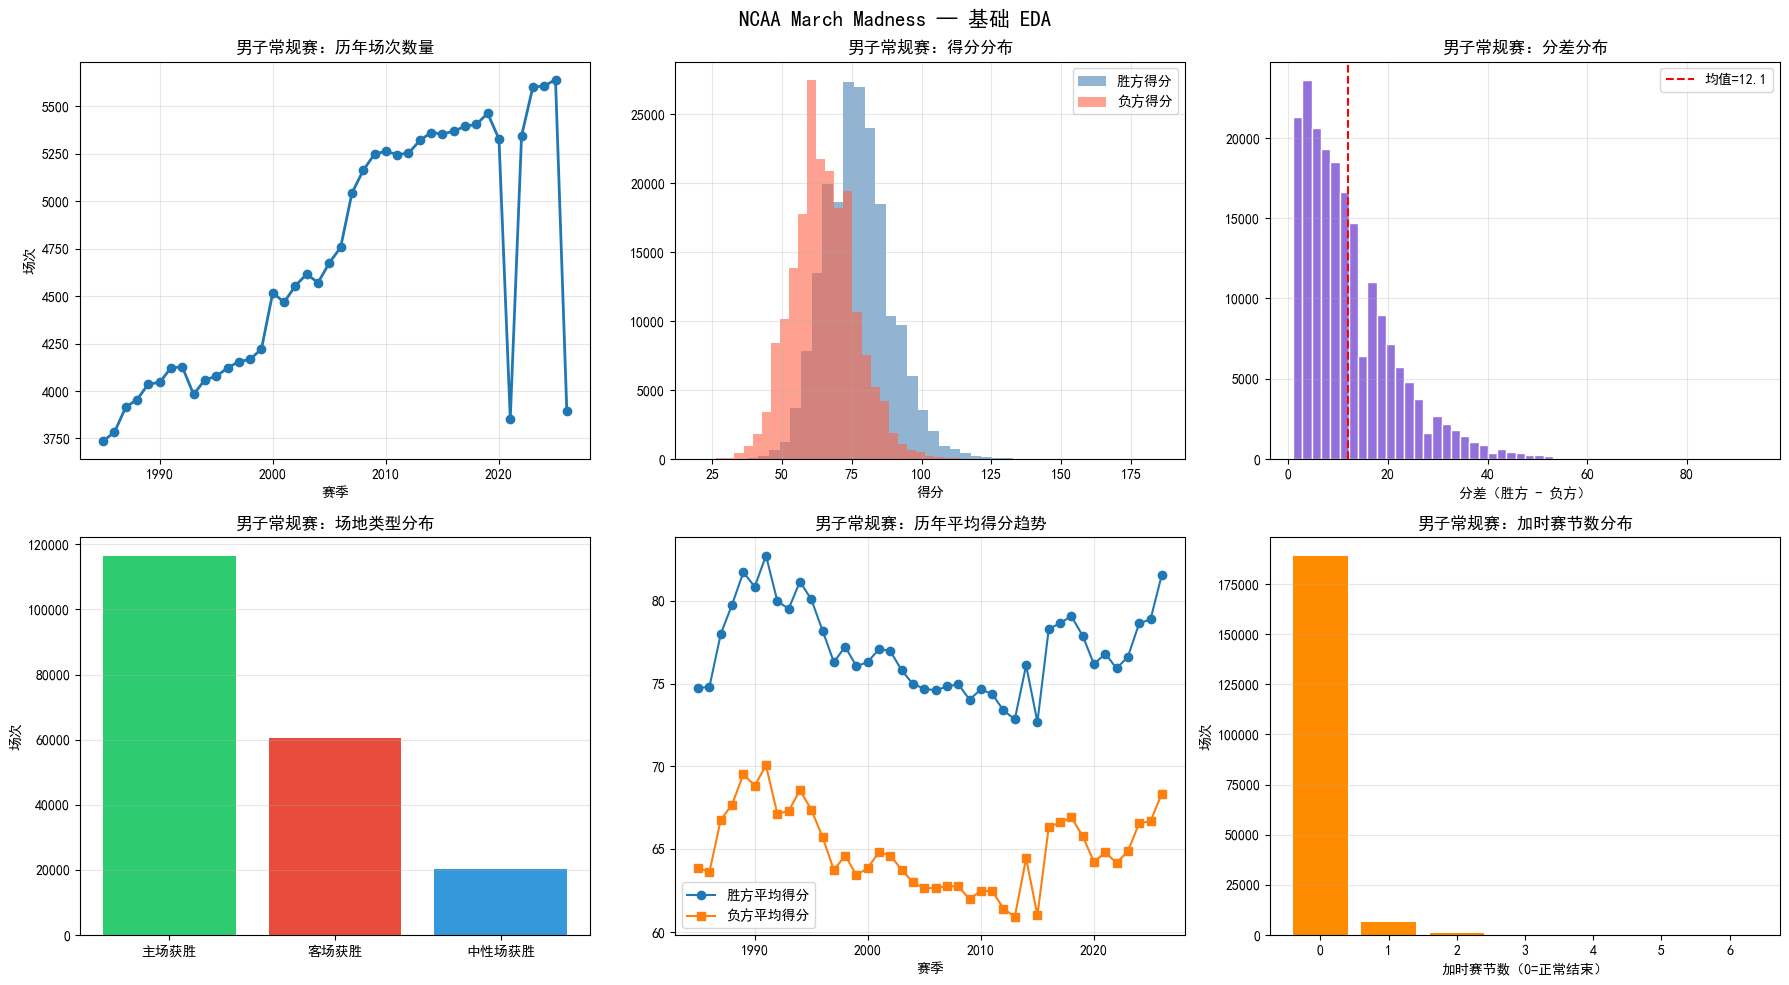

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('NCAA March Madness — 基础 EDA', fontsize=15, fontweight='bold')

# 1. 历年男子常规赛场次
games_per_season = m_reg_compact.groupby('Season').size()
axes[0, 0].plot(games_per_season.index, games_per_season.values, marker='o', linewidth=2)
axes[0, 0].set_title('男子常规赛：历年场次数量')
axes[0, 0].set_xlabel('赛季')
axes[0, 0].set_ylabel('场次')
axes[0, 0].grid(alpha=0.3)

# 2. 得分分布（胜负方对比）
axes[0, 1].hist(m_reg_compact['WScore'], bins=40, alpha=0.6, label='胜方得分', color='steelblue')
axes[0, 1].hist(m_reg_compact['LScore'], bins=40, alpha=0.6, label='负方得分', color='tomato')
axes[0, 1].set_title('男子常规赛：得分分布')
axes[0, 1].set_xlabel('得分')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# 3. 分差分布
m_reg_compact['ScoreDiff'] = m_reg_compact['WScore'] - m_reg_compact['LScore']
axes[0, 2].hist(m_reg_compact['ScoreDiff'], bins=50, color='mediumpurple', edgecolor='white')
axes[0, 2].axvline(m_reg_compact['ScoreDiff'].mean(), color='red', linestyle='--',
                   label=f"均值={m_reg_compact['ScoreDiff'].mean():.1f}")
axes[0, 2].set_title('男子常规赛：分差分布')
axes[0, 2].set_xlabel('分差（胜方 - 负方）')
axes[0, 2].legend()
axes[0, 2].grid(alpha=0.3)

# 4. 主客中性场胜率
loc_counts = m_reg_compact['WLoc'].value_counts()
loc_labels = {'H': '主场获胜', 'A': '客场获胜', 'N': '中性场获胜'}
axes[1, 0].bar([loc_labels.get(k, k) for k in loc_counts.index], loc_counts.values,
               color=['#2ecc71', '#e74c3c', '#3498db'])
axes[1, 0].set_title('男子常规赛：场地类型分布')
axes[1, 0].set_ylabel('场次')
axes[1, 0].grid(alpha=0.3, axis='y')

# 5. 历年平均得分趋势
season_avg = m_reg_compact.groupby('Season').agg(
    AvgWScore=('WScore', 'mean'),
    AvgLScore=('LScore', 'mean')
).reset_index()
axes[1, 1].plot(season_avg['Season'], season_avg['AvgWScore'], label='胜方平均得分', marker='o')
axes[1, 1].plot(season_avg['Season'], season_avg['AvgLScore'], label='负方平均得分', marker='s')
axes[1, 1].set_title('男子常规赛：历年平均得分趋势')
axes[1, 1].set_xlabel('赛季')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

# 6. 加时赛频率
ot_dist = m_reg_compact['NumOT'].value_counts().sort_index()
axes[1, 2].bar(ot_dist.index.astype(str), ot_dist.values, color='darkorange')
axes[1, 2].set_title('男子常规赛：加时赛节数分布')
axes[1, 2].set_xlabel('加时赛节数（0=正常结束）')
axes[1, 2].set_ylabel('场次')
axes[1, 2].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 第三节：常规赛团队统计特征构建

基于 `MRegularSeasonDetailedResults`，按 **Season × TeamID** 聚合计算进攻/防守效率等特征。

In [4]:
def build_team_season_stats(detailed_df, gender='M'):
    """
    从 DetailedResults 中为每个 (Season, TeamID) 聚合统计特征。
    同时处理"胜方视角"和"负方视角"，再合并求均值。
    """
    # 胜方统计
    win_cols = {
        'WScore': 'PtsFor', 'LScore': 'PtsAgainst',
        'WFGM': 'FGM', 'WFGA': 'FGA', 'WFGM3': 'FGM3', 'WFGA3': 'FGA3',
        'WFTM': 'FTM', 'WFTA': 'FTA',
        'WOR': 'OR', 'WDR': 'DR',
        'WAst': 'Ast', 'WTO': 'TO', 'WStl': 'Stl', 'WBlk': 'Blk', 'WPF': 'PF',
        'NumOT': 'NumOT',
    }
    loss_cols = {
        'LScore': 'PtsFor', 'WScore': 'PtsAgainst',
        'LFGM': 'FGM', 'LFGA': 'FGA', 'LFGM3': 'FGM3', 'LFGA3': 'FGA3',
        'LFTM': 'FTM', 'LFTA': 'FTA',
        'LOR': 'OR', 'LDR': 'DR',
        'LAst': 'Ast', 'LTO': 'TO', 'LStl': 'Stl', 'LBlk': 'Blk', 'LPF': 'PF',
        'NumOT': 'NumOT',
    }

    w_df = detailed_df[['Season', 'WTeamID'] + list(win_cols.keys())].copy()
    w_df = w_df.rename(columns={'WTeamID': 'TeamID', **win_cols})
    w_df['Win'] = 1

    l_df = detailed_df[['Season', 'LTeamID'] + list(loss_cols.keys())].copy()
    l_df = l_df.rename(columns={'LTeamID': 'TeamID', **loss_cols})
    l_df['Win'] = 0

    all_df = pd.concat([w_df, l_df], ignore_index=True)

    agg = all_df.groupby(['Season', 'TeamID']).agg(
        Games=('Win', 'count'),
        Wins=('Win', 'sum'),
        PtsFor=('PtsFor', 'mean'),
        PtsAgainst=('PtsAgainst', 'mean'),
        FGM=('FGM', 'mean'), FGA=('FGA', 'mean'),
        FGM3=('FGM3', 'mean'), FGA3=('FGA3', 'mean'),
        FTM=('FTM', 'mean'), FTA=('FTA', 'mean'),
        OR=('OR', 'mean'), DR=('DR', 'mean'),
        Ast=('Ast', 'mean'), TO=('TO', 'mean'),
        Stl=('Stl', 'mean'), Blk=('Blk', 'mean'), PF=('PF', 'mean'),
        NumOT=('NumOT', 'mean'),
    ).reset_index()

    agg['WinRate']    = agg['Wins'] / agg['Games']
    agg['ScoreDiff']  = agg['PtsFor'] - agg['PtsAgainst']
    agg['FGPct']      = agg['FGM'] / agg['FGA'].replace(0, np.nan)
    agg['FG3Pct']     = agg['FGM3'] / agg['FGA3'].replace(0, np.nan)
    agg['FTPct']      = agg['FTM'] / agg['FTA'].replace(0, np.nan)
    agg['TotalReb']   = agg['OR'] + agg['DR']
    # 进攻效率：每百回合得分（简易版）
    agg['Poss']       = agg['FGA'] - agg['OR'] + agg['TO'] + 0.44 * agg['FTA']
    agg['OffEff']     = agg['PtsFor'] / agg['Poss'].replace(0, np.nan) * 100
    agg['DefEff']     = agg['PtsAgainst'] / agg['Poss'].replace(0, np.nan) * 100
    agg['NetEff']     = agg['OffEff'] - agg['DefEff']
    agg['Gender']     = gender

    return agg

m_team_stats = build_team_season_stats(m_reg_detailed, gender='M')
w_team_stats = build_team_season_stats(w_reg_detailed, gender='W')

print("男子球队赛季特征维度：", m_team_stats.shape)
print("女子球队赛季特征维度：", w_team_stats.shape)
m_team_stats.head(3)

男子球队赛季特征维度： (8346, 31)
女子球队赛季特征维度： (5965, 31)


,Season,TeamID,Games,Wins,PtsFor,PtsAgainst,FGM,FGA,FGM3,FGA3,...,ScoreDiff,FGPct,FG3Pct,FTPct,TotalReb,Poss,OffEff,DefEff,NetEff,Gender
0,2003,1102,28,12,57.250000,57.000000,19.142857,39.785714,7.821429,20.821429,...,0.250000,0.481149,0.375643,0.651357,21.000000,54.562857,104.924857,104.466670,0.458187,M
1,2003,1103,27,13,78.777778,78.148148,27.148148,55.851852,5.444444,16.074074,...,0.629630,0.486074,0.338710,0.736390,29.703704,70.078519,112.413589,111.515126,0.898463,M
2,2003,1104,28,17,69.285714,65.000000,24.035714,57.178571,6.357143,19.857143,...,4.285714,0.420362,0.320144,0.709898,37.500000,66.101429,104.817272,98.333730,6.483543,M


## 第四节：锦标赛历史表现特征

In [5]:
def build_tourney_history(tourney_compact, seeds_df, gender='M'):
    """
    构建每支球队的历史锦标赛表现特征（仅使用当前赛季之前的数据，避免未来泄漏）。
    返回 (Season, TeamID) 级别的特征，每一行只包含截至该赛季之前的累计统计。
    """
    # 胜方/负方各记一行
    w = tourney_compact[['Season', 'WTeamID', 'LTeamID', 'WScore', 'LScore', 'DayNum']].copy()
    w['TeamID'] = w['WTeamID']; w['OppID'] = w['LTeamID']
    w['Win'] = 1; w['PtsFor'] = w['WScore']; w['PtsAgainst'] = w['LScore']

    l = tourney_compact[['Season', 'WTeamID', 'LTeamID', 'WScore', 'LScore', 'DayNum']].copy()
    l['TeamID'] = l['LTeamID']; l['OppID'] = l['WTeamID']
    l['Win'] = 0; l['PtsFor'] = l['LScore']; l['PtsAgainst'] = l['WScore']

    df = pd.concat([w[['Season','TeamID','OppID','Win','PtsFor','PtsAgainst','DayNum']],
                    l[['Season','TeamID','OppID','Win','PtsFor','PtsAgainst','DayNum']]])

    # 追加种子
    seed_map = seeds_df[['Season', 'TeamID', 'SeedNum']].copy()
    df = df.merge(seed_map, on=['Season', 'TeamID'], how='left')

    # ── 无泄漏：按 (TeamID, Season) 聚合，然后只使用「截至上一赛季」的累计值 ──
    per_season = df.groupby(['TeamID', 'Season']).agg(
        SeasonTGames=('Win', 'count'),
        SeasonTWins=('Win', 'sum'),
        SeasonSeed=('SeedNum', 'first'),
    ).reset_index().sort_values(['TeamID', 'Season'])

    # 累计（含当赛季）→ 再减去当赛季 = 仅含之前赛季
    per_season['CumGames'] = per_season.groupby('TeamID')['SeasonTGames'].cumsum()
    per_season['CumWins']  = per_season.groupby('TeamID')['SeasonTWins'].cumsum()
    per_season['CumApps']  = per_season.groupby('TeamID').cumcount() + 1

    # Prior = 累计 - 当赛季（即截至上赛季结束）
    per_season['PriorTGames'] = per_season['CumGames'] - per_season['SeasonTGames']
    per_season['PriorTWins']  = per_season['CumWins']  - per_season['SeasonTWins']
    per_season['PriorApps']   = per_season['CumApps']  - 1
    per_season['PriorTWinRate'] = per_season['PriorTWins'] / per_season['PriorTGames'].replace(0, np.nan)

    # 只保留所需的无泄漏列
    hist = per_season[['Season', 'TeamID', 'PriorApps', 'PriorTGames',
                        'PriorTWins', 'PriorTWinRate']].copy()
    hist.columns = ['Season', 'TeamID', 'TourneyApps', 'TourneyGames',
                    'TourneyWins', 'TourneyWinRate']
    hist['Gender'] = gender
    return hist, df

m_tourney_hist, m_tourney_long = build_tourney_history(m_tourney_compact, m_seeds, 'M')
w_tourney_hist, w_tourney_long = build_tourney_history(w_tourney_compact, w_seeds, 'W')

print("男子锦标赛历史特征（无泄漏版）：", m_tourney_hist.shape)
print("示例（首次参赛的球队 PriorApps=0）：")
m_tourney_hist.head(10)

男子锦标赛历史特征（无泄漏版）： (2625, 7)
示例（首次参赛的球队 PriorApps=0）：


,Season,TeamID,TourneyApps,TourneyGames,TourneyWins,TourneyWinRate,Gender
0,2019,1101,0,0,0,NaN,M
1,2021,1101,1,1,0,0.0,M
2,2004,1102,0,0,0,NaN,M
3,2006,1102,1,1,0,0.0,M
4,1986,1103,0,0,0,NaN,M
5,2009,1103,1,1,0,0.0,M
6,2011,1103,2,2,0,0.0,M
7,2013,1103,3,3,0,0.0,M
8,2022,1103,4,4,0,0.0,M
9,2024,1103,5,5,0,0.0,M


## 第五节：球队排名特征工程（Massey Ordinals）

In [6]:
# 使用赛季末排名（RankingDayNum==133）
massey_final = m_massey[m_massey['RankingDayNum'] == 133].copy()

# 聚焦常用系统
key_systems = ['POM', 'SAG', 'RPI', 'MOR', 'DOK', 'WOL', 'WLK', 'RTH']
available_systems = massey_final['SystemName'].unique()
use_systems = [s for s in key_systems if s in available_systems]
print(f"使用的排名系统（共{len(use_systems)}个）：{use_systems}")

massey_pivot = massey_final[massey_final['SystemName'].isin(use_systems)].pivot_table(
    index=['Season', 'TeamID'],
    columns='SystemName',
    values='OrdinalRank',
    aggfunc='mean'
).reset_index()
massey_pivot.columns.name = None

rank_cols = [c for c in massey_pivot.columns if c not in ['Season', 'TeamID']]
# 综合排名特征
massey_pivot['RankMean']   = massey_pivot[rank_cols].mean(axis=1)
massey_pivot['RankMedian'] = massey_pivot[rank_cols].median(axis=1)
massey_pivot['RankStd']    = massey_pivot[rank_cols].std(axis=1)

# 排名百分位（越小越好 → 转为"越大越好"的分位数）
# rank_pct = (N - rank + 1) / N
for col in rank_cols:
    max_rank = massey_pivot[col].max()
    massey_pivot[f'{col}_pct'] = (max_rank - massey_pivot[col] + 1) / max_rank
massey_pivot['AvgRankPct'] = massey_pivot[[f'{c}_pct' for c in rank_cols]].mean(axis=1)

# 缺失值用赛季中位数填充
fill_cols = rank_cols + ['RankMean', 'RankMedian', 'RankStd', 'AvgRankPct']
massey_pivot[fill_cols] = massey_pivot.groupby('Season')[fill_cols].transform(
    lambda x: x.fillna(x.median())
)

print(f"Massey特征矩阵维度：{massey_pivot.shape}")
massey_pivot.head(3)

使用的排名系统（共8个）：['POM', 'SAG', 'RPI', 'MOR', 'DOK', 'WOL', 'WLK', 'RTH']
Massey特征矩阵维度：(7627, 22)


,Season,TeamID,DOK,MOR,POM,RPI,RTH,SAG,WLK,WOL,...,RankStd,DOK_pct,MOR_pct,POM_pct,RPI_pct,RTH_pct,SAG_pct,WLK_pct,WOL_pct,AvgRankPct
0,2003,1102,NaN,132.0,160.0,158.0,146.0,149.0,165.0,157.0,...,11.088389,NaN,0.640110,0.563187,0.568681,0.601648,0.592287,0.549451,0.571429,0.583827
1,2003,1103,NaN,139.0,163.0,182.0,168.0,172.0,172.0,171.0,...,13.487207,NaN,0.620879,0.554945,0.502747,0.541209,0.528926,0.530220,0.532967,0.544556
2,2003,1104,NaN,26.0,33.0,38.0,31.0,37.0,36.0,37.0,...,4.320494,NaN,0.931319,0.912088,0.898352,0.917582,0.900826,0.903846,0.901099,0.909302


## 第六节：种子位置与历史胜率分析

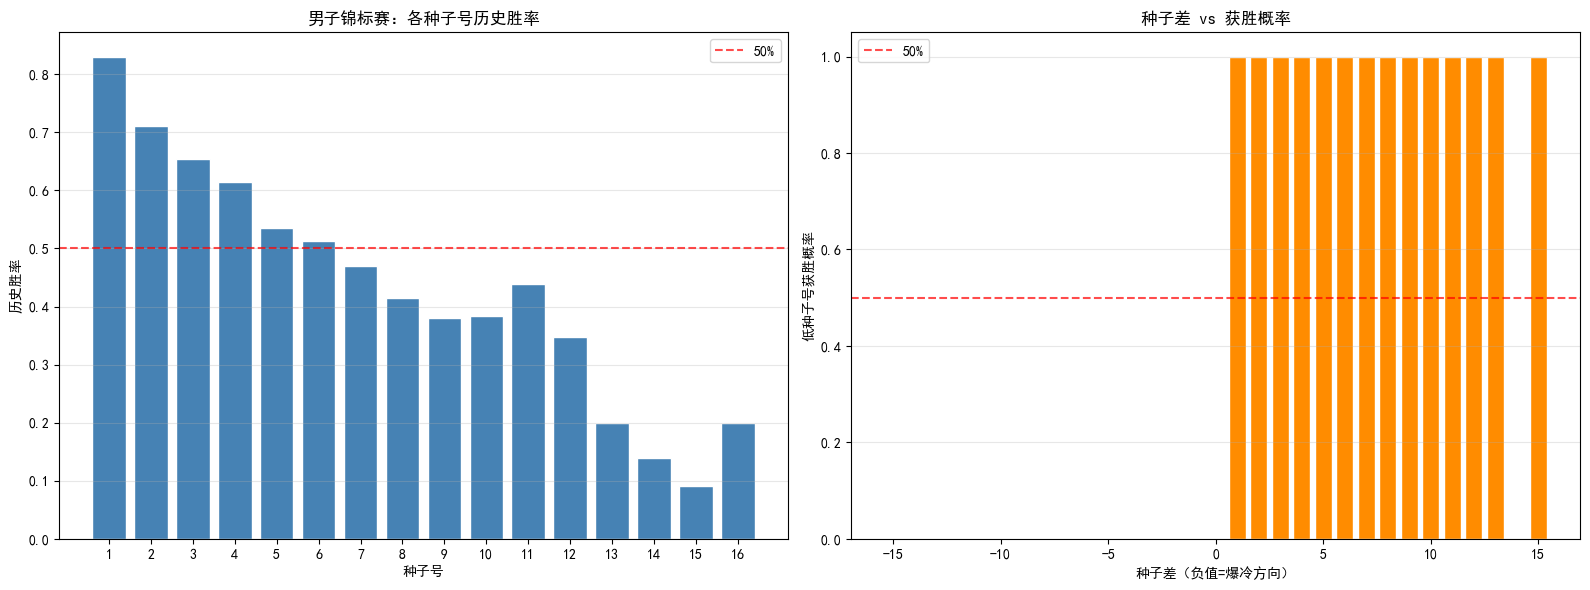

种子特征示例：
   Season  TeamID  SeedNum  SeedWinRate
0    1985    1207        1     0.830482
1    1985    1210        2     0.710476
2    1985    1228        3     0.654788
3    1985    1260        4     0.614251
4    1985    1374        5     0.535088


In [7]:
# 构建种子对决矩阵
tourney_with_seed = m_tourney_compact.copy()
seed_map = m_seeds[['Season', 'TeamID', 'SeedNum']].rename(columns={'TeamID': 'WTeamID', 'SeedNum': 'WSeed'})
tourney_with_seed = tourney_with_seed.merge(seed_map, on=['Season', 'WTeamID'], how='left')
seed_map2 = m_seeds[['Season', 'TeamID', 'SeedNum']].rename(columns={'TeamID': 'LTeamID', 'SeedNum': 'LSeed'})
tourney_with_seed = tourney_with_seed.merge(seed_map2, on=['Season', 'LTeamID'], how='left')
tourney_with_seed = tourney_with_seed.dropna(subset=['WSeed', 'LSeed'])

# 计算：低种子号胜高种子号的概率（种子号越小越强）
tourney_with_seed['FavWin'] = (tourney_with_seed['WSeed'] < tourney_with_seed['LSeed']).astype(int)
tourney_with_seed['SeedDiff'] = tourney_with_seed['LSeed'] - tourney_with_seed['WSeed']

# 各种子号历史胜率
seed_winrate = {}
for seed in range(1, 17):
    games = tourney_with_seed[(tourney_with_seed['WSeed'] == seed) | (tourney_with_seed['LSeed'] == seed)]
    wins = (games['WSeed'] == seed).sum()
    total = len(games)
    seed_winrate[seed] = wins / total if total > 0 else 0

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 各种子号胜率
axes[0].bar(list(seed_winrate.keys()), list(seed_winrate.values()), color='steelblue', edgecolor='white')
axes[0].axhline(0.5, color='red', linestyle='--', alpha=0.7, label='50%')
axes[0].set_xlabel('种子号')
axes[0].set_ylabel('历史胜率')
axes[0].set_title('男子锦标赛：各种子号历史胜率')
axes[0].set_xticks(range(1, 17))
axes[0].legend()
axes[0].grid(alpha=0.3, axis='y')

# 按分差分组的爆冷概率
upset_by_diff = tourney_with_seed.groupby('SeedDiff')['FavWin'].mean()
axes[1].bar(upset_by_diff.index, upset_by_diff.values, color='darkorange', edgecolor='white')
axes[1].axhline(0.5, color='red', linestyle='--', alpha=0.7, label='50%')
axes[1].set_xlabel('种子差（负值=爆冷方向）')
axes[1].set_ylabel('低种子号获胜概率')
axes[1].set_title('种子差 vs 获胜概率')
axes[1].legend()
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# 赛季种子特征（用于模型）—— 去掉 SeedBucket（对已有数值 SeedNum 完全冗余）
seed_season_feat = m_seeds[['Season', 'TeamID', 'SeedNum']].copy()
seed_season_feat['SeedWinRate'] = seed_season_feat['SeedNum'].map(seed_winrate)
print("种子特征示例：")
print(seed_season_feat.head())

## 第七节：主客场与中性场地效应分析

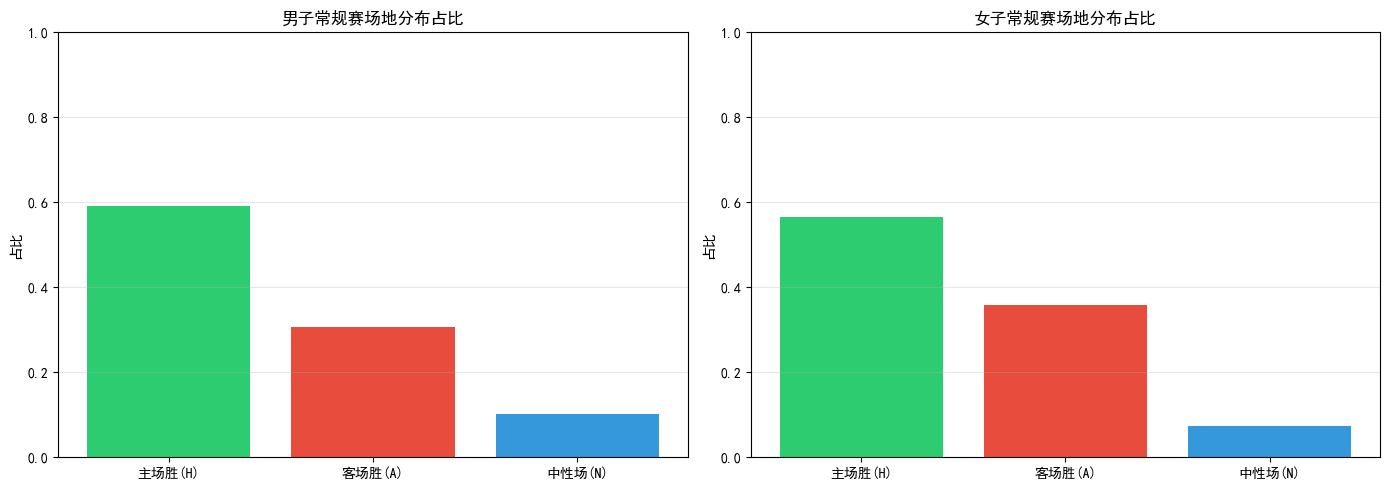

主客场特征维度： (13753, 10)


,Season,TeamID,WinRate_A,WinRate_H,WinRate_N,Games_A,Games_H,Games_N,HomeAdvantage,Gender
0,1985,1102,0.250000,0.200000,0.000000,12.0,10.0,2.0,-0.050000,M
1,1985,1103,0.200000,0.538462,NaN,10.0,13.0,NaN,0.338462,M
2,1985,1104,0.454545,0.937500,0.333333,11.0,16.0,3.0,0.482955,M


In [8]:
def build_home_away_stats(compact_df, gender='M'):
    """
    按球队、场地类型统计胜率。
    注意：NCAA 锦标赛男子全部为中性场，此特征主要捕捉球队在常规赛客场/中性场的适应能力。
    """
    # 胜方
    w = compact_df[['Season', 'WTeamID', 'WLoc']].copy()
    w['TeamID'] = w['WTeamID']; w['Win'] = 1
    w['Loc'] = w['WLoc']

    # 负方：需要反转位置
    l = compact_df[['Season', 'LTeamID', 'WLoc']].copy()
    l['TeamID'] = l['LTeamID']; l['Win'] = 0
    loc_flip = {'H': 'A', 'A': 'H', 'N': 'N'}
    l['Loc'] = l['WLoc'].map(loc_flip)

    df = pd.concat([
        w[['Season', 'TeamID', 'Win', 'Loc']],
        l[['Season', 'TeamID', 'Win', 'Loc']]
    ])

    loc_stats = df.groupby(['Season', 'TeamID', 'Loc']).agg(
        Games=('Win', 'count'), Wins=('Win', 'sum')
    ).reset_index()
    loc_stats['WinRate'] = loc_stats['Wins'] / loc_stats['Games']

    # 安全 pivot：显式处理每种场地类型，避免列名错位
    wr_pivot = loc_stats.pivot_table(
        index=['Season', 'TeamID'], columns='Loc',
        values='WinRate', aggfunc='first'
    ).reset_index()
    wr_pivot.columns.name = None
    for c in ['A', 'H', 'N']:
        col_name = f'WinRate_{c}'
        wr_pivot[col_name] = wr_pivot.get(c, np.nan)
        if c in wr_pivot.columns:
            wr_pivot.drop(columns=[c], inplace=True, errors='ignore')

    gm_pivot = loc_stats.pivot_table(
        index=['Season', 'TeamID'], columns='Loc',
        values='Games', aggfunc='first'
    ).reset_index()
    gm_pivot.columns.name = None
    for c in ['A', 'H', 'N']:
        col_name = f'Games_{c}'
        gm_pivot[col_name] = gm_pivot.get(c, np.nan)
        if c in gm_pivot.columns:
            gm_pivot.drop(columns=[c], inplace=True, errors='ignore')

    loc_pivot = wr_pivot.merge(gm_pivot, on=['Season', 'TeamID'], how='outer')
    loc_pivot['HomeAdvantage'] = loc_pivot['WinRate_H'].fillna(0) - loc_pivot['WinRate_A'].fillna(0)
    loc_pivot['Gender'] = gender
    return loc_pivot

m_home_stats = build_home_away_stats(m_reg_compact, 'M')
w_home_stats = build_home_away_stats(w_reg_compact, 'W')

# 可视化主客中性场整体胜率
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (df, title) in zip(axes, [(m_reg_compact, '男子'), (w_reg_compact, '女子')]):
    home_win = (df['WLoc'] == 'H').sum()
    away_win = (df['WLoc'] == 'A').sum()
    neut_win = (df['WLoc'] == 'N').sum()
    total = len(df)
    ax.bar(['主场胜(H)', '客场胜(A)', '中性场(N)'],
           [home_win/total, away_win/total, neut_win/total],
           color=['#2ecc71', '#e74c3c', '#3498db'])
    ax.set_title(f'{title}常规赛场地分布占比')
    ax.set_ylabel('占比')
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("主客场特征维度：", m_home_stats.shape)
m_home_stats.head(3)

## 第八节：教练稳定性特征

教练特征维度（无泄漏版）： (13763, 7)


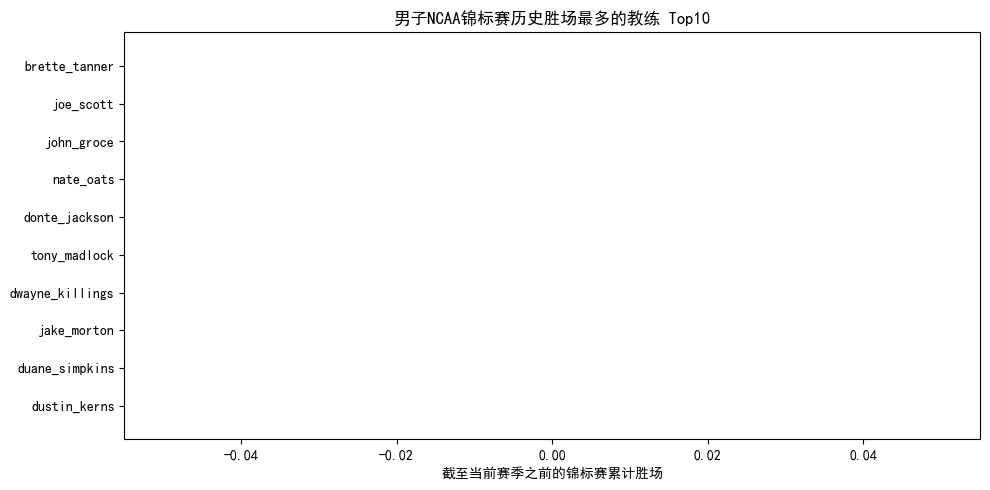

,Season,TeamID,CoachName,MidSeasonChange,CoachTourneyGames,CoachTourneyWins,CoachTourneyWinRate
0,1985,1102,reggie_minton,0,NaN,NaN,NaN
1,1985,1103,bob_huggins,0,NaN,NaN,NaN
2,1985,1104,wimp_sanderson,0,0.0,0.0,NaN


In [9]:
def build_coach_features(coaches_df, tourney_compact):
    """
    构建教练稳定性与经验特征（无未来泄漏版）。
    CoachTourneyWins/WinRate 只使用截至上一赛季的累计记录。
    """
    # ── 1. 是否存在中途换帅 ──
    coach_per_season = coaches_df.groupby(['Season', 'TeamID'])['CoachName'].nunique().reset_index()
    coach_per_season.columns = ['Season', 'TeamID', 'CoachCount']
    coach_per_season['MidSeasonChange'] = (coach_per_season['CoachCount'] > 1).astype(int)

    # ── 2. 取赛季末教练（LastDayNum 最大的那个）──
    season_end_coach = coaches_df.loc[
        coaches_df.groupby(['Season', 'TeamID'])['LastDayNum'].idxmax()
    ][['Season', 'TeamID', 'CoachName']].copy()

    # ── 3. 教练历史锦标赛胜场（仅用当赛季之前的记录）──
    w_coach = tourney_compact[['Season', 'WTeamID']].rename(columns={'WTeamID': 'TeamID'})
    w_coach['TourneyWin'] = 1
    l_coach = tourney_compact[['Season', 'LTeamID']].rename(columns={'LTeamID': 'TeamID'})
    l_coach['TourneyWin'] = 0
    t_all = pd.concat([w_coach, l_coach])
    t_all = t_all.merge(season_end_coach, on=['Season', 'TeamID'], how='left')
    t_all = t_all.dropna(subset=['CoachName'])

    # 按 (CoachName, Season) 聚合当赛季数据
    coach_season = t_all.groupby(['CoachName', 'Season']).agg(
        SeasonGames=('TourneyWin', 'count'),
        SeasonWins=('TourneyWin', 'sum'),
    ).reset_index().sort_values(['CoachName', 'Season'])

    # 累计 → 减去当赛季 = 仅含之前赛季
    coach_season['CumGames'] = coach_season.groupby('CoachName')['SeasonGames'].cumsum()
    coach_season['CumWins']  = coach_season.groupby('CoachName')['SeasonWins'].cumsum()
    coach_season['PriorGames'] = coach_season['CumGames'] - coach_season['SeasonGames']
    coach_season['PriorWins']  = coach_season['CumWins']  - coach_season['SeasonWins']
    coach_season['PriorWinRate'] = coach_season['PriorWins'] / coach_season['PriorGames'].replace(0, np.nan)

    coach_prior = coach_season[['CoachName', 'Season', 'PriorGames', 'PriorWins', 'PriorWinRate']].copy()
    coach_prior.columns = ['CoachName', 'Season', 'CoachTourneyGames', 'CoachTourneyWins', 'CoachTourneyWinRate']

    # ── 4. 合并 ──
    result = season_end_coach.merge(
        coach_per_season[['Season', 'TeamID', 'MidSeasonChange']],
        on=['Season', 'TeamID'], how='left'
    )
    result = result.merge(
        coach_prior,
        on=['CoachName', 'Season'], how='left'
    )
    return result

m_coach_feat = build_coach_features(m_coaches, m_tourney_compact)
print("教练特征维度（无泄漏版）：", m_coach_feat.shape)

# 教练锦标赛胜场 Top10（取最新赛季的累计数据展示）
latest_season = m_coach_feat['Season'].max()
top_coaches = (m_coach_feat[m_coach_feat['Season'] == latest_season]
               .drop_duplicates('CoachName')
               .sort_values('CoachTourneyWins', ascending=False)
               .head(10))
plt.figure(figsize=(10, 5))
plt.barh(top_coaches['CoachName'], top_coaches['CoachTourneyWins'].fillna(0), color='teal')
plt.xlabel('截至当前赛季之前的锦标赛累计胜场')
plt.title('男子NCAA锦标赛历史胜场最多的教练 Top10')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

m_coach_feat.head(3)

## 第九节：联盟强度特征（Conference Strength Index）

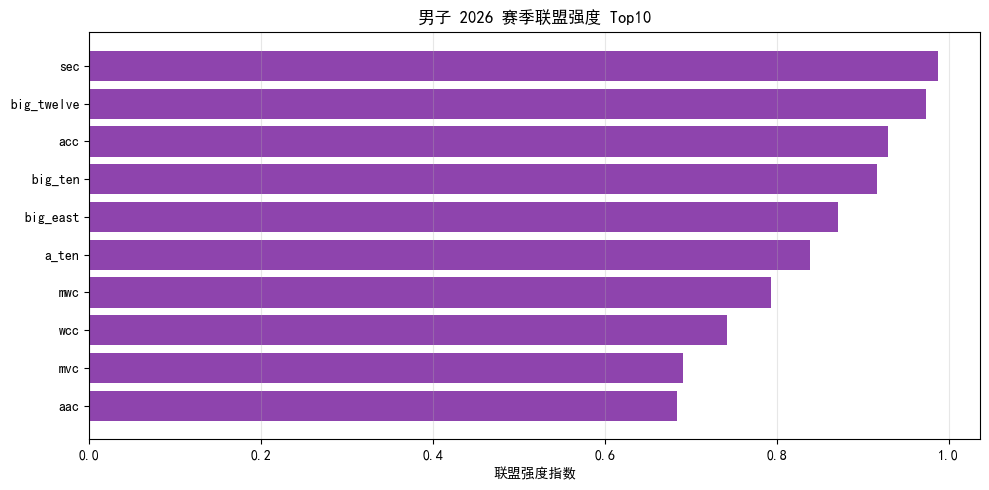

联盟强度特征维度： (773, 11)


In [10]:
def build_conference_strength(team_stats, team_conf, gender='M'):
    """计算每个联盟的赛季强度指数（per-season 归一化，避免跨赛季泄漏）"""
    df = team_stats.merge(team_conf, on=['Season', 'TeamID'], how='left')
    conf_strength = df.groupby(['Season', 'ConfAbbrev']).agg(
        ConfAvgWinRate=('WinRate', 'mean'),
        ConfAvgScoreDiff=('ScoreDiff', 'mean'),
        ConfAvgOffEff=('OffEff', 'mean'),
        ConfAvgDefEff=('DefEff', 'mean'),
        ConfTeamCount=('TeamID', 'nunique'),
    ).reset_index()
    # per-season 百分位排名归一化（只用当赛季数据，不泄漏未来赛季信息）
    idx_cols = ['ConfAvgWinRate', 'ConfAvgScoreDiff', 'ConfAvgOffEff']
    norm_names = ['WR_norm', 'SD_norm', 'OE_norm']
    for col, norm_col in zip(idx_cols, norm_names):
        conf_strength[norm_col] = conf_strength.groupby('Season')[col].rank(pct=True)
    conf_strength['ConfStrengthIndex'] = (
        conf_strength['WR_norm'] * 0.4 +
        conf_strength['SD_norm'] * 0.4 +
        conf_strength['OE_norm'] * 0.2
    )
    # 将联盟强度合并回球队
    team_conf_feat = team_conf.merge(
        conf_strength[['Season', 'ConfAbbrev', 'ConfStrengthIndex',
                        'ConfAvgWinRate', 'ConfAvgScoreDiff', 'ConfTeamCount']],
        on=['Season', 'ConfAbbrev'], how='left'
    )
    return conf_strength, team_conf_feat

m_conf_strength, m_team_conf_feat = build_conference_strength(m_team_stats, m_conf, 'M')
w_conf_strength, w_team_conf_feat = build_conference_strength(w_team_stats, w_conf, 'W')

# 2025赛季联盟强度 Top 10
latest = m_conf_strength[m_conf_strength['Season'] == m_conf_strength['Season'].max()]
top10_conf = latest.sort_values('ConfStrengthIndex', ascending=False).head(10)
plt.figure(figsize=(10, 5))
plt.barh(top10_conf['ConfAbbrev'], top10_conf['ConfStrengthIndex'], color='#8e44ad')
plt.xlabel('联盟强度指数')
plt.title(f"男子 {latest['Season'].iloc[0]} 赛季联盟强度 Top10")
plt.gca().invert_yaxis()
plt.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("联盟强度特征维度：", m_conf_strength.shape)

## 第十节：赛季趋势与近期状态（Momentum）特征

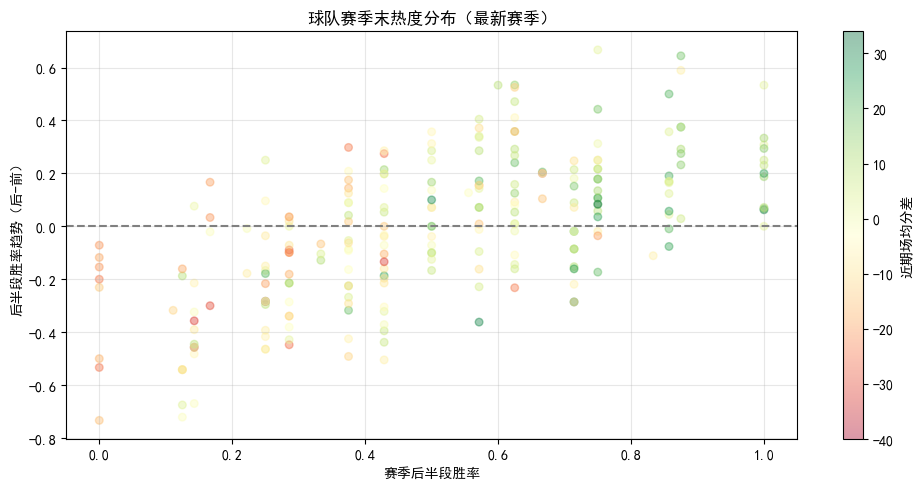

Momentum特征维度： (13751, 12)


,Season,TeamID,LateWinRate,LateScoreDiff,LateGames,EarlyWinRate,RecentWinRate,RecentScoreDiff,RecentGames,LastNWinRate,LastNScoreDiff,WinRateTrend
0,1985,1102,0.166667,-6.888889,18,0.333333,0.272727,-3.272727,11.0,0.3,-2.6,-0.166667
1,1985,1103,0.388889,-3.388889,18,0.400000,0.454545,-3.000000,11.0,0.4,-4.3,-0.011111
2,1985,1104,0.684211,6.000000,19,0.727273,0.666667,8.416667,12.0,0.7,9.6,-0.043062


In [11]:
def build_momentum_features(compact_df, last_n=10, recent_daynum=90):
    """
    计算球队近期状态特征：
    - 赛季后半段胜率（DayNum > 66）
    - 进入锦标赛前最近N场胜率
    - 近期场均分差
    """
    # 构建统一视角：胜方和负方
    w = compact_df[['Season', 'DayNum', 'WTeamID', 'WScore', 'LScore']].copy()
    w.columns = ['Season', 'DayNum', 'TeamID', 'PtsFor', 'PtsAgainst']
    w['Win'] = 1

    l = compact_df[['Season', 'DayNum', 'LTeamID', 'LScore', 'WScore']].copy()
    l.columns = ['Season', 'DayNum', 'TeamID', 'PtsFor', 'PtsAgainst']
    l['Win'] = 0

    df = pd.concat([w, l]).sort_values(['Season', 'TeamID', 'DayNum'])
    df['ScoreDiff'] = df['PtsFor'] - df['PtsAgainst']

    # 赛季后半段（DayNum > 66）胜率
    late_season = df[df['DayNum'] > 66].groupby(['Season', 'TeamID']).agg(
        LateWinRate=('Win', 'mean'),
        LateScoreDiff=('ScoreDiff', 'mean'),
        LateGames=('Win', 'count'),
    ).reset_index()

    # 赛季前半段胜率（DayNum <= 66）
    early_season = df[df['DayNum'] <= 66].groupby(['Season', 'TeamID']).agg(
        EarlyWinRate=('Win', 'mean'),
    ).reset_index()

    # 近recent_daynum天（赛季末期）
    recent = df[df['DayNum'] >= recent_daynum].groupby(['Season', 'TeamID']).agg(
        RecentWinRate=('Win', 'mean'),
        RecentScoreDiff=('ScoreDiff', 'mean'),
        RecentGames=('Win', 'count'),
    ).reset_index()

    # 最近N场（取每支球队赛季中DayNum最大的N场）
    last_n_games = (
        df.groupby(['Season', 'TeamID'])
          .apply(lambda x: x.nlargest(last_n, 'DayNum'))
          .reset_index(drop=True)
    )
    last_n_agg = last_n_games.groupby(['Season', 'TeamID']).agg(
        LastNWinRate=('Win', 'mean'),
        LastNScoreDiff=('ScoreDiff', 'mean'),
    ).reset_index()

    # 合并
    momentum = late_season.merge(early_season, on=['Season', 'TeamID'], how='left')
    momentum = momentum.merge(recent, on=['Season', 'TeamID'], how='left')
    momentum = momentum.merge(last_n_agg, on=['Season', 'TeamID'], how='left')

    # 趋势：后半段 - 前半段
    momentum['WinRateTrend'] = momentum['LateWinRate'] - momentum['EarlyWinRate']

    return momentum

m_momentum = build_momentum_features(m_reg_compact)
w_momentum = build_momentum_features(w_reg_compact)

# 可视化部分球队近期状态示例
sample = m_momentum[m_momentum['Season'] == m_momentum['Season'].max()].copy()
plt.figure(figsize=(10, 5))
plt.scatter(sample['LateWinRate'], sample['WinRateTrend'],
            alpha=0.4, c=sample['RecentScoreDiff'], cmap='RdYlGn', s=30)
plt.colorbar(label='近期场均分差')
plt.axhline(0, color='gray', linestyle='--')
plt.xlabel('赛季后半段胜率')
plt.ylabel('后半段胜率趋势（后-前）')
plt.title('球队赛季末热度分布（最新赛季）')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Momentum特征维度：", m_momentum.shape)
m_momentum.head(3)

## 第十一节：特征归一化与合并

将第3-10节的所有球队特征按 `(Season, TeamID)` 对齐并合并为统一的 `team_features` 表。

In [12]:
def merge_all_features(team_stats, tourney_hist, massey, home_stats,
                        conf_feat, momentum, seed_feat, coach_feat, gender='M'):
    """
    合并所有单球队特征为统一特征表。
    注意：不在此处做标准化（StandardScaler 应放在建模 Pipeline 中，避免数据泄漏）。
    tourney_hist 现在是 (Season, TeamID) 级别（已修复为无泄漏版本）。
    """
    df = team_stats.copy()

    # 锦标赛历史（现在是赛季维度，仅包含截至当赛季之前的累计数据）
    df = df.merge(
        tourney_hist[['Season', 'TeamID', 'TourneyApps', 'TourneyWins',
                      'TourneyWinRate']],
        on=['Season', 'TeamID'], how='left'
    )

    # 主客场胜率
    df = df.merge(
        home_stats[['Season', 'TeamID', 'WinRate_H', 'WinRate_A',
                    'WinRate_N', 'HomeAdvantage']],
        on=['Season', 'TeamID'], how='left'
    )

    # 联盟强度
    df = df.merge(
        conf_feat[['Season', 'TeamID', 'ConfAbbrev',
                   'ConfStrengthIndex', 'ConfAvgScoreDiff']],
        on=['Season', 'TeamID'], how='left'
    )

    # 近期状态
    df = df.merge(
        momentum[['Season', 'TeamID', 'LateWinRate', 'LastNWinRate',
                  'LastNScoreDiff', 'WinRateTrend', 'RecentWinRate']],
        on=['Season', 'TeamID'], how='left'
    )

    # 赛季种子
    df = df.merge(
        seed_feat[['Season', 'TeamID', 'SeedNum', 'SeedWinRate']],
        on=['Season', 'TeamID'], how='left'
    )

    # Massey排名（仅对男子有效）
    if massey is not None:
        df = df.merge(
            massey[['Season', 'TeamID', 'RankMean', 'RankMedian', 'AvgRankPct']],
            on=['Season', 'TeamID'], how='left'
        )

    # 教练特征（无泄漏版本，已是 Season 级别）
    if coach_feat is not None:
        df = df.merge(
            coach_feat[['Season', 'TeamID', 'MidSeasonChange',
                        'CoachTourneyWins', 'CoachTourneyWinRate']],
            on=['Season', 'TeamID'], how='left'
        )

    # 不做标准化——交给建模 Pipeline 处理
    return df

# ── 男子特征合并 ───────────────────────────────────────────────
m_team_feat_raw = merge_all_features(
    team_stats=m_team_stats,
    tourney_hist=m_tourney_hist,
    massey=massey_pivot,
    home_stats=m_home_stats,
    conf_feat=m_team_conf_feat,
    momentum=m_momentum,
    seed_feat=seed_season_feat,
    coach_feat=m_coach_feat,
    gender='M'
)

# ── 女子种子胜率：直接用 w_tourney_long（已含 SeedNum 和 Win 列）───
w_seed_winrate = (
    w_tourney_long.dropna(subset=['SeedNum'])
    .groupby('SeedNum')['Win'].mean()
    .to_dict()
)
w_seed_feat = w_seeds[['Season', 'TeamID', 'SeedNum']].copy()
w_seed_feat['SeedWinRate'] = w_seed_feat['SeedNum'].map(w_seed_winrate)

# ── 女子特征合并 ───────────────────────────────────────────────
w_team_feat_raw = merge_all_features(
    team_stats=w_team_stats,
    tourney_hist=w_tourney_hist,
    massey=None,
    home_stats=w_home_stats,
    conf_feat=w_team_conf_feat,
    momentum=w_momentum,
    seed_feat=w_seed_feat,
    coach_feat=None,
    gender='W'
)

print(f"男子球队全量特征维度：{m_team_feat_raw.shape}")
print(f"女子球队全量特征维度：{w_team_feat_raw.shape}")
print(f"\n特征列列表：")
print(list(m_team_feat_raw.columns))

男子球队全量特征维度：(8346, 54)
女子球队全量特征维度：(5965, 48)

特征列列表：
['Season', 'TeamID', 'Games', 'Wins', 'PtsFor', 'PtsAgainst', 'FGM', 'FGA', 'FGM3', 'FGA3', 'FTM', 'FTA', 'OR', 'DR', 'Ast', 'TO', 'Stl', 'Blk', 'PF', 'NumOT', 'WinRate', 'ScoreDiff', 'FGPct', 'FG3Pct', 'FTPct', 'TotalReb', 'Poss', 'OffEff', 'DefEff', 'NetEff', 'Gender', 'TourneyApps', 'TourneyWins', 'TourneyWinRate', 'WinRate_H', 'WinRate_A', 'WinRate_N', 'HomeAdvantage', 'ConfAbbrev', 'ConfStrengthIndex', 'ConfAvgScoreDiff', 'LateWinRate', 'LastNWinRate', 'LastNScoreDiff', 'WinRateTrend', 'RecentWinRate', 'SeedNum', 'SeedWinRate', 'RankMean', 'RankMedian', 'AvgRankPct', 'MidSeasonChange', 'CoachTourneyWins', 'CoachTourneyWinRate']


## 第十二节：构建配对样本训练集

解析 `SampleSubmissionStage1.csv` 中的 `ID` 字段（格式 `SSSS_XXXX_YYYY`），关联锦标赛真实结果，生成差分特征矩阵：

$$\Delta feature = feature_{TeamA} - feature_{TeamB}$$

标签：低ID球队（TeamA）是否获胜（1/0）。

In [13]:
def build_matchup_dataset(sub_df, team_feat, tourney_compact, gender='M'):
    """
    从提交模板构建差分特征训练集（有标签）
    sub_df: SampleSubmission（含ID列 SSSS_XXXX_YYYY）
    team_feat: 已合并的球队特征表
    tourney_compact: 锦标赛实际结果
    """
    # 解析ID
    sub = sub_df.copy()
    sub[['Season', 'TeamA', 'TeamB']] = sub['ID'].str.split('_', expand=True)
    sub['Season'] = sub['Season'].astype(int)
    sub['TeamA']  = sub['TeamA'].astype(int)
    sub['TeamB']  = sub['TeamB'].astype(int)

    # 构造实际结果标签（TeamA即低ID队是否赢）
    w_games = tourney_compact[['Season', 'WTeamID', 'LTeamID']].copy()
    w_games['ATeamWin'] = (w_games['WTeamID'] < w_games['LTeamID']).astype(int)
    w_games['TeamA'] = w_games[['WTeamID', 'LTeamID']].min(axis=1)
    w_games['TeamB'] = w_games[['WTeamID', 'LTeamID']].max(axis=1)
    w_games['Label'] = (w_games['WTeamID'] == w_games['TeamA']).astype(int)

    sub = sub.merge(w_games[['Season', 'TeamA', 'TeamB', 'Label']],
                    on=['Season', 'TeamA', 'TeamB'], how='left')

    # 特征列（排除非数值列）
    feat_cols = [c for c in team_feat.columns
                 if c not in ['Season', 'TeamID', 'Gender', 'ConfAbbrev', 'SeedBucket']
                 and team_feat[c].dtype in [np.float64, np.int64, float, int]]

    # 关联两队特征
    feat_a = team_feat[['Season', 'TeamID'] + feat_cols].copy()
    feat_b = feat_a.copy()
    feat_a.columns = ['Season', 'TeamA'] + [f'A_{c}' for c in feat_cols]
    feat_b.columns = ['Season', 'TeamB'] + [f'B_{c}' for c in feat_cols]

    sub = sub.merge(feat_a, on=['Season', 'TeamA'], how='left')
    sub = sub.merge(feat_b, on=['Season', 'TeamB'], how='left')

    # 计算差分特征
    for c in feat_cols:
        sub[f'Diff_{c}'] = sub[f'A_{c}'] - sub[f'B_{c}']

    diff_cols = [f'Diff_{c}' for c in feat_cols]
    sub_clean = sub[['ID', 'Season', 'TeamA', 'TeamB', 'Label'] + diff_cols].copy()

    print(f"配对数据集维度：{sub_clean.shape}")
    print(f"有标签样本数：{sub_clean['Label'].notna().sum()}")
    print(f"标签分布：\n{sub_clean['Label'].value_counts()}")
    return sub_clean, feat_cols

m_matchup_df, m_feat_cols = build_matchup_dataset(
    sub_stage1, m_team_feat_raw, m_tourney_compact, gender='M'
)

m_matchup_df.dropna(subset=['Label']).head(3)

配对数据集维度：(519144, 55)
有标签样本数：268
标签分布：
Label
1.0    154
0.0    114
Name: count, dtype: int64


,ID,Season,TeamA,TeamB,Label,Diff_Games,Diff_Wins,Diff_PtsFor,Diff_PtsAgainst,Diff_FGM,...,Diff_WinRateTrend,Diff_RecentWinRate,Diff_SeedNum,Diff_SeedWinRate,Diff_RankMean,Diff_RankMedian,Diff_AvgRankPct,Diff_MidSeasonChange,Diff_CoachTourneyWins,Diff_CoachTourneyWinRate
1015,2022_1103_1417,2022,1103,1417,0.0,-1.0,-3.0,-7.084677,-0.651210,-4.356855,...,0.334632,0.142857,9.0,-0.414251,108.428571,119.0,-0.298013,0.0,-7.0,0.093168
1277,2022_1104_1323,2022,1104,1323,0.0,1.0,-2.0,8.033266,9.470766,2.075605,...,-0.494779,-0.212121,-5.0,0.075165,-25.714286,-29.0,0.070677,0.0,-9.0,0.018519
3628,2022_1112_1222,2022,1112,1222,0.0,0.0,2.0,8.735294,8.647059,2.294118,...,0.006246,0.147619,-4.0,0.295394,-6.142857,-4.0,0.016879,0.0,-19.0,NaN


## 第十三节：特征相关性与重要性分析

训练样本数：268，特征数：50


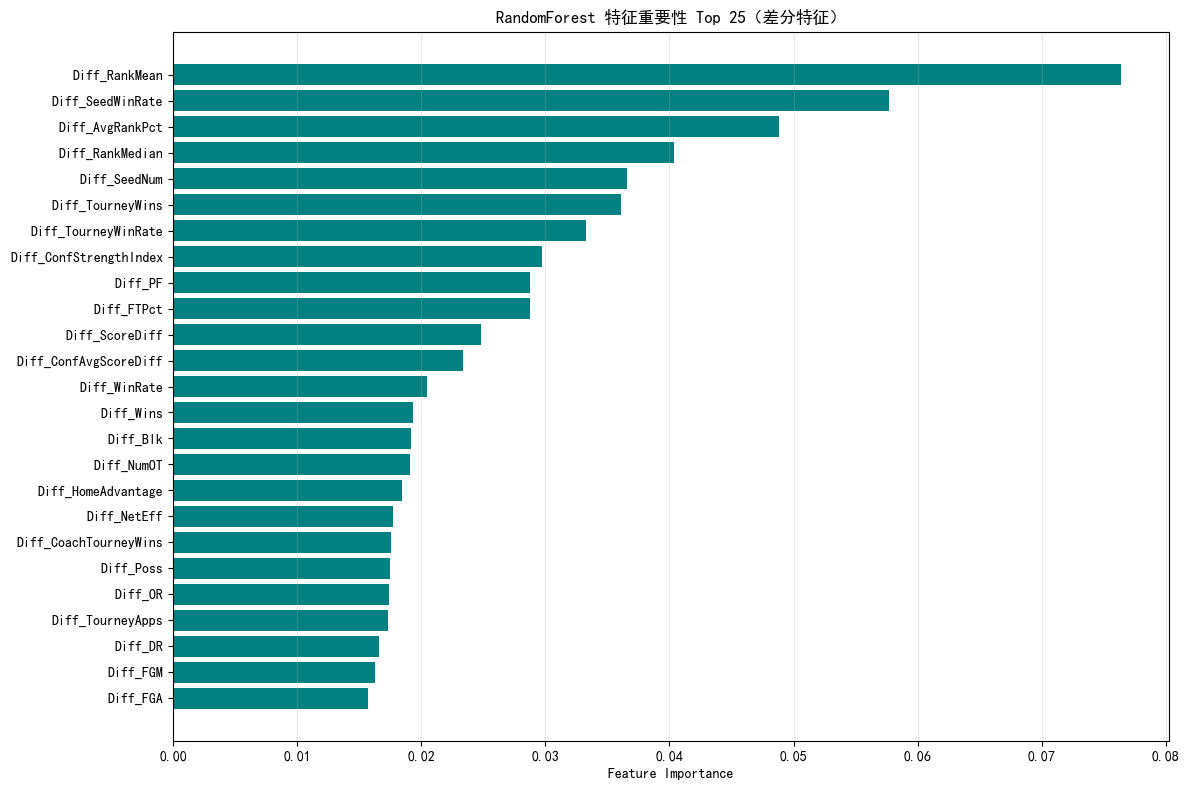


Top 10 最重要特征：
Diff_RankMean             0.076402
Diff_SeedWinRate          0.057658
Diff_AvgRankPct           0.048852
Diff_RankMedian           0.040362
Diff_SeedNum              0.036545
Diff_TourneyWins          0.036123
Diff_TourneyWinRate       0.033311
Diff_ConfStrengthIndex    0.029706
Diff_PF                   0.028777
Diff_FTPct                0.028749


In [14]:
from sklearn.ensemble import RandomForestClassifier

# 准备训练数据
train_df = m_matchup_df.dropna(subset=['Label']).copy()
diff_cols = [c for c in train_df.columns if c.startswith('Diff_')]
X = train_df[diff_cols].fillna(0)
y = train_df['Label'].astype(int)

print(f"训练样本数：{len(X)}，特征数：{len(diff_cols)}")

# 训练随机森林（用于特征重要性）
rf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42, n_jobs=-1)
rf.fit(X, y)

# 特征重要性 Top 25
importance = pd.Series(rf.feature_importances_, index=diff_cols)
top25 = importance.sort_values(ascending=False).head(25)

plt.figure(figsize=(12, 8))
plt.barh(top25.index, top25.values, color='teal')
plt.xlabel('Feature Importance')
plt.title('RandomForest 特征重要性 Top 25（差分特征）')
plt.gca().invert_yaxis()
plt.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\nTop 10 最重要特征：")
print(top25.head(10).to_string())

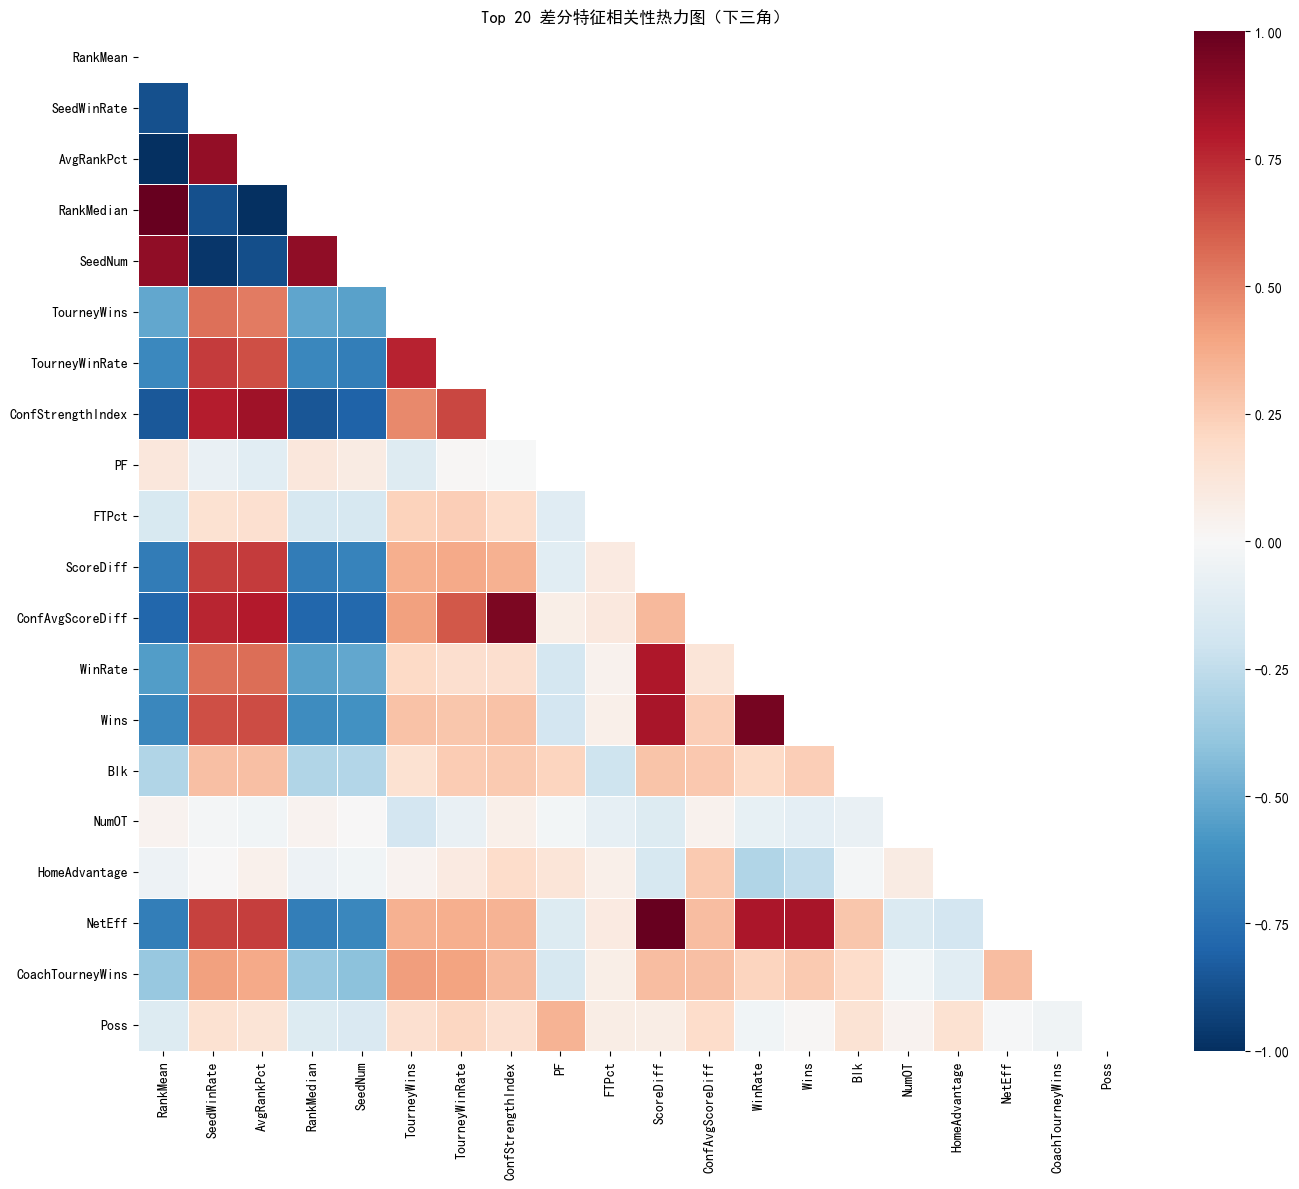

⚠️ 高度共线特征对（|r|>0.85）：
  RankMean × SeedWinRate  r=-0.878
  RankMean × AvgRankPct  r=-1.0
  RankMean × RankMedian  r=0.998
  RankMean × SeedNum  r=0.89
  SeedWinRate × AvgRankPct  r=0.878
  SeedWinRate × RankMedian  r=-0.876
  SeedWinRate × SeedNum  r=-0.976
  AvgRankPct × RankMedian  r=-0.998
  AvgRankPct × SeedNum  r=-0.89
  RankMedian × SeedNum  r=0.89
  RankMedian × ConfStrengthIndex  r=-0.852
  ConfStrengthIndex × ConfAvgScoreDiff  r=0.944
  ScoreDiff × NetEff  r=0.996
  WinRate × Wins  r=0.958


In [15]:
# 特征相关性热力图（Top 20 特征）
top20_cols = top25.head(20).index.tolist()
corr = X[top20_cols].corr()

plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='RdBu_r',
            center=0, linewidths=0.5, vmin=-1, vmax=1,
            xticklabels=[c.replace('Diff_', '') for c in top20_cols],
            yticklabels=[c.replace('Diff_', '') for c in top20_cols])
plt.title('Top 20 差分特征相关性热力图（下三角）')
plt.tight_layout()
plt.show()

# 高度共线特征识别（|corr| > 0.85）
high_corr_pairs = []
for i, col1 in enumerate(top20_cols):
    for j, col2 in enumerate(top20_cols):
        if i < j and abs(corr.iloc[i, j]) > 0.85:
            high_corr_pairs.append((col1, col2, round(corr.iloc[i, j], 3)))
if high_corr_pairs:
    print("⚠️ 高度共线特征对（|r|>0.85）：")
    for p in high_corr_pairs:
        print(f"  {p[0].replace('Diff_','')} × {p[1].replace('Diff_','')}  r={p[2]}")
else:
    print("✅ Top 20 特征中没有高度共线对")

## 特征保存 — 导出 CSV 供后续建模使用

In [16]:
OUT = DATA_DIR / 'features'
OUT.mkdir(exist_ok=True)

# 球队级特征（原始值）
m_team_feat_raw.to_csv(OUT / 'M_team_features_raw.csv', index=False)
w_team_feat_raw.to_csv(OUT / 'W_team_features_raw.csv', index=False)

# 配对差分训练集
m_matchup_df.to_csv(OUT / 'M_matchup_train.csv', index=False)

# 仅含有标签的行（训练用）
labeled = m_matchup_df.dropna(subset=['Label'])
labeled.to_csv(OUT / 'M_matchup_train_labeled.csv', index=False)

# Massey排名特征
massey_pivot.to_csv(OUT / 'M_massey_features.csv', index=False)

# Stage2 预测集
m_stage2, _ = build_matchup_dataset(sub_stage2, m_team_feat_raw, m_tourney_compact, gender='M')
m_stage2.to_csv(OUT / 'M_stage2_pred_features.csv', index=False)

print("✅ 所有特征文件已保存至：", OUT)
print(f"\n  M_team_features_raw.csv        → {m_team_feat_raw.shape}")
print(f"  W_team_features_raw.csv        → {w_team_feat_raw.shape}")
print(f"  M_matchup_train.csv            → {m_matchup_df.shape}")
print(f"  M_matchup_train_labeled.csv    → {labeled.shape}")
print(f"  M_massey_features.csv          → {massey_pivot.shape}")
print(f"  M_stage2_pred_features.csv     → {m_stage2.shape}")

print("\n" + "="*60)
print("特征工程完成！可用差分特征数量：", len(diff_cols))
print("推荐重点特征（RF Top 10）：")
for feat, imp in top25.head(10).items():
    print(f"  {feat.replace('Diff_',''):35s}  importance={imp:.4f}")

配对数据集维度：(132133, 55)
有标签样本数：0
标签分布：
Series([], Name: count, dtype: int64)
✅ 所有特征文件已保存至： features

  M_team_features_raw.csv        → (8346, 54)
  W_team_features_raw.csv        → (5965, 48)
  M_matchup_train.csv            → (519144, 55)
  M_matchup_train_labeled.csv    → (268, 55)
  M_massey_features.csv          → (7627, 22)
  M_stage2_pred_features.csv     → (132133, 55)

特征工程完成！可用差分特征数量： 50
推荐重点特征（RF Top 10）：
  RankMean                             importance=0.0764
  SeedWinRate                          importance=0.0577
  AvgRankPct                           importance=0.0489
  RankMedian                           importance=0.0404
  SeedNum                              importance=0.0365
  TourneyWins                          importance=0.0361
  TourneyWinRate                       importance=0.0333
  ConfStrengthIndex                    importance=0.0297
  PF                                   importance=0.0288
  FTPct                                importance=0.0287


## 优化一：去除高度共线特征，构建精简特征集

根据热力图分析，删除冗余特征，保留信息量最大的代表特征：
- 排名组：保留 `AvgRankPct`，删除 `RankMean`、`RankMedian`
- 锦标赛组：保留 `TourneyWinRate`、`TourneyMaxRound`，删除 `TourneyAvgRound`、`TourneySweetSixteen`、`TourneyFinalFour`
- 效率组：保留 `NetEff`，删除 `ScoreDiff`（高度重复）
- 种子组：保留 `SeedNum`，删除 `TourneyAvgSeed`、`SeedWinRate`（与 SeedNum 相关 > 0.97）

In [17]:
# 去除高度共线的冗余特征
# 注：Cell 10 修改后 tourney_hist 仅含 TourneyApps/TourneyWins/TourneyWinRate，
#     旧列（TourneyAvgRound/SweetSixteen/FinalFour/AvgSeed）已不存在。
DROP_FEATURES = [
    'RankMean', 'RankMedian',         # 保留 AvgRankPct
    'ScoreDiff',                       # 保留 NetEff
    'SeedWinRate',                     # 保留 SeedNum（SeedWinRate 使用全历史有泄漏风险）
    'Poss',                            # 派生量，已包含在OffEff中
    'Wins',                            # 保留 WinRate
    'PtsFor', 'PtsAgainst',            # 保留 NetEff
    'FGM', 'FGM3', 'FTM',             # 保留命中率
]

def drop_collinear(df, drop_cols):
    actual_drop = [c for c in drop_cols if c in df.columns]
    return df.drop(columns=actual_drop)

m_team_feat_slim = drop_collinear(m_team_feat_raw, DROP_FEATURES)
w_team_feat_slim = drop_collinear(w_team_feat_raw, DROP_FEATURES)

# 重建差分配对集（使用精简特征）
def build_matchup_slim(sub_df, team_feat, tourney_compact):
    sub = sub_df.copy()
    sub[['Season', 'TeamA', 'TeamB']] = sub['ID'].str.split('_', expand=True)
    sub['Season'] = sub['Season'].astype(int)
    sub['TeamA']  = sub['TeamA'].astype(int)
    sub['TeamB']  = sub['TeamB'].astype(int)

    # 标签
    w_games = tourney_compact.copy()
    w_games['TeamA'] = w_games[['WTeamID', 'LTeamID']].min(axis=1)
    w_games['TeamB'] = w_games[['WTeamID', 'LTeamID']].max(axis=1)
    w_games['Label'] = (w_games['WTeamID'] == w_games['TeamA']).astype(int)
    sub = sub.merge(w_games[['Season', 'TeamA', 'TeamB', 'Label']],
                    on=['Season', 'TeamA', 'TeamB'], how='left')

    feat_cols = [c for c in team_feat.columns
                 if c not in ['Season', 'TeamID', 'Gender', 'ConfAbbrev', 'SeedBucket']
                 and team_feat[c].dtype in [np.float64, np.int64, float, int]]

    fa = team_feat[['Season', 'TeamID'] + feat_cols].copy()
    fb = fa.copy()
    fa.columns = ['Season', 'TeamA'] + [f'A_{c}' for c in feat_cols]
    fb.columns = ['Season', 'TeamB'] + [f'B_{c}' for c in feat_cols]
    sub = sub.merge(fa, on=['Season', 'TeamA'], how='left')
    sub = sub.merge(fb, on=['Season', 'TeamB'], how='left')

    for c in feat_cols:
        sub[f'Diff_{c}'] = sub[f'A_{c}'] - sub[f'B_{c}']

    diff_cols = [f'Diff_{c}' for c in feat_cols]
    return sub[['ID', 'Season', 'TeamA', 'TeamB', 'Label'] + diff_cols], feat_cols

m_matchup_slim, m_slim_feat_cols = build_matchup_slim(sub_stage1, m_team_feat_slim, m_tourney_compact)

print(f"精简后特征数: {len(m_slim_feat_cols)} (原: {len(m_feat_cols)})")
print(f"精简配对集维度: {m_matchup_slim.shape}")

精简后特征数: 39 (原: 50)
精简配对集维度: (519144, 44)


## 优化二：扩充训练集 — 使用全历史锦标赛数据

Stage1 仅含 268 条标签，将历史全量锦标赛结果（1985-2025）全部作为训练集。

In [18]:
def build_full_history_train(tourney_compact, team_feat):
    """
    用全历史锦标赛结果构建训练集（非提交模板，直接从比赛记录生成）
    保证每场比赛生成 (低ID队, 高ID队) 格式的配对
    """
    tc = tourney_compact.copy()
    tc['TeamA'] = tc[['WTeamID', 'LTeamID']].min(axis=1)
    tc['TeamB'] = tc[['WTeamID', 'LTeamID']].max(axis=1)
    tc['Label'] = (tc['WTeamID'] == tc['TeamA']).astype(int)
    tc['ID'] = tc['Season'].astype(str) + '_' + tc['TeamA'].astype(str) + '_' + tc['TeamB'].astype(str)

    feat_cols = [c for c in team_feat.columns
                 if c not in ['Season', 'TeamID', 'Gender', 'ConfAbbrev', 'SeedBucket']
                 and team_feat[c].dtype in [np.float64, np.int64, float, int]]

    fa = team_feat[['Season', 'TeamID'] + feat_cols].copy()
    fb = fa.copy()
    fa.columns = ['Season', 'TeamA'] + [f'A_{c}' for c in feat_cols]
    fb.columns = ['Season', 'TeamB'] + [f'B_{c}' for c in feat_cols]

    df = tc[['ID', 'Season', 'TeamA', 'TeamB', 'Label']].merge(
             fa, on=['Season', 'TeamA'], how='left').merge(
             fb, on=['Season', 'TeamB'], how='left')

    for c in feat_cols:
        df[f'Diff_{c}'] = df[f'A_{c}'] - df[f'B_{c}']

    diff_cols = [f'Diff_{c}' for c in feat_cols]
    result = df[['ID', 'Season', 'TeamA', 'TeamB', 'Label'] + diff_cols].dropna(subset=['Label'])
    return result, feat_cols

m_train_full, _ = build_full_history_train(m_tourney_compact, m_team_feat_slim)
print(f"全历史训练集维度: {m_train_full.shape}")
print(f"标签分布:\n{m_train_full['Label'].value_counts()}")
print(f"赛季覆盖: {m_train_full['Season'].min()} - {m_train_full['Season'].max()}")

全历史训练集维度: (2585, 44)
标签分布:
Label
1    1323
0    1262
Name: count, dtype: int64
赛季覆盖: 1985 - 2025


## 优化三：Elo 动态评分特征

Elo 评分捕捉球队当前真实强度，比历史静态统计更具预测力。每场比赛后更新双方 Elo 分，赛季末 Elo 作为球队特征。

计算男子 Elo 评分...
计算女子 Elo 评分...


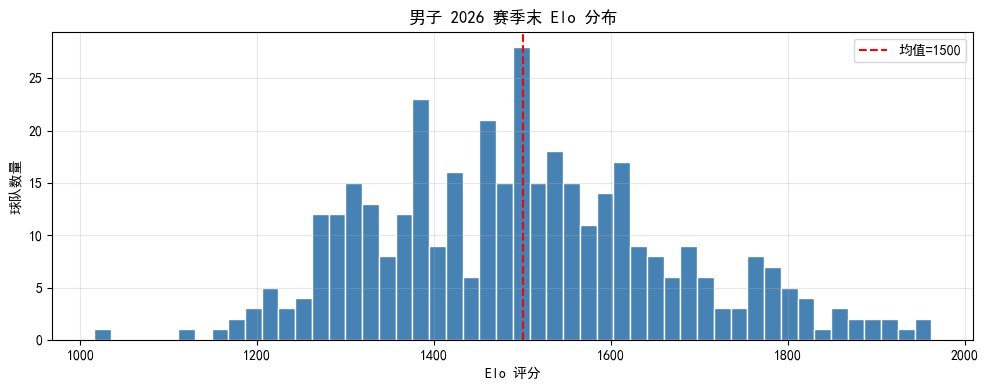


Elo特征维度: 男子=(14206, 3), 女子=(9952, 3)
Elo Top 10 球队（2026赛季）:
   TeamName         Elo
       Duke 1962.489374
    Houston 1953.817214
    Arizona 1935.726926
   Michigan 1920.634819
Connecticut 1907.597975
    Gonzaga 1891.609454
    Florida 1891.176803
Michigan St 1874.835786
   Illinois 1874.299479
  St John's 1864.448544


In [19]:
def compute_elo(compact_df, k=32, initial=1500, season_carryover=0.75):
    """
    计算每支球队每个赛季末的 Elo 评分（单次遍历版本）。
    season_carryover: 跨赛季保留比例（新赛季Elo = 前赛季Elo × 0.75 + 初始值 × 0.25）
    """
    elo = {}  # {TeamID: current_elo}
    season_end_elo = []
    prev_season = None

    games = compact_df.sort_values(['Season', 'DayNum']).copy()

    for _, row in games.iterrows():
        season = row['Season']
        w, l = row['WTeamID'], row['LTeamID']

        # 赛季切换时：先保存上赛季末 Elo 快照，再衰减
        if season != prev_season:
            if prev_season is not None:
                for team, e in elo.items():
                    season_end_elo.append({'Season': prev_season, 'TeamID': team, 'Elo': e})
            for team in list(elo.keys()):
                elo[team] = elo[team] * season_carryover + initial * (1 - season_carryover)
            prev_season = season

        # 初始化新球队
        if w not in elo: elo[w] = initial
        if l not in elo: elo[l] = initial

        elo_w, elo_l = elo[w], elo[l]

        # 期望胜率
        exp_w = 1 / (1 + 10 ** ((elo_l - elo_w) / 400))

        # 分差加权 K 值
        score_diff = row['WScore'] - row['LScore']
        k_adj = k * np.log1p(abs(score_diff)) / np.log1p(10)

        # 更新
        elo[w] = elo_w + k_adj * (1 - exp_w)
        elo[l] = elo_l + k_adj * (0 - (1 - exp_w))

    # 保存最后一个赛季
    for team, e in elo.items():
        season_end_elo.append({'Season': prev_season, 'TeamID': team, 'Elo': e})

    return pd.DataFrame(season_end_elo)

print("计算男子 Elo 评分...")
m_elo = compute_elo(m_reg_compact)
print("计算女子 Elo 评分...")
w_elo = compute_elo(w_reg_compact)

# 可视化历年 Elo 分布
latest_elo = m_elo[m_elo['Season'] == m_elo['Season'].max()]
plt.figure(figsize=(10, 4))
plt.hist(latest_elo['Elo'], bins=50, color='steelblue', edgecolor='white')
plt.axvline(latest_elo['Elo'].mean(), color='red', linestyle='--',
            label=f"均值={latest_elo['Elo'].mean():.0f}")
plt.xlabel('Elo 评分')
plt.ylabel('球队数量')
plt.title(f"男子 {latest_elo['Season'].iloc[0]} 赛季末 Elo 分布")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nElo特征维度: 男子={m_elo.shape}, 女子={w_elo.shape}")
print(f"Elo Top 10 球队（{latest_elo['Season'].iloc[0]}赛季）:")
top_elo = latest_elo.merge(m_teams[['TeamID','TeamName']], on='TeamID').nlargest(10, 'Elo')[['TeamName','Elo']]
print(top_elo.to_string(index=False))

## 优化四：整合 Elo，构建最终优化特征集并验证

最终训练集: (2585, 45), 标签分布:
Label
1    1323
0    1262
Name: count, dtype: int64

模型对比（GroupKFold by Season — 无泄漏验证）
LogisticRegression         Brier=0.2141  AUC=0.6893  LogLoss=0.6119
RandomForest               Brier=0.2152  AUC=0.6854  LogLoss=0.6158
GradientBoosting           Brier=0.2176  AUC=0.6758  LogLoss=0.6217


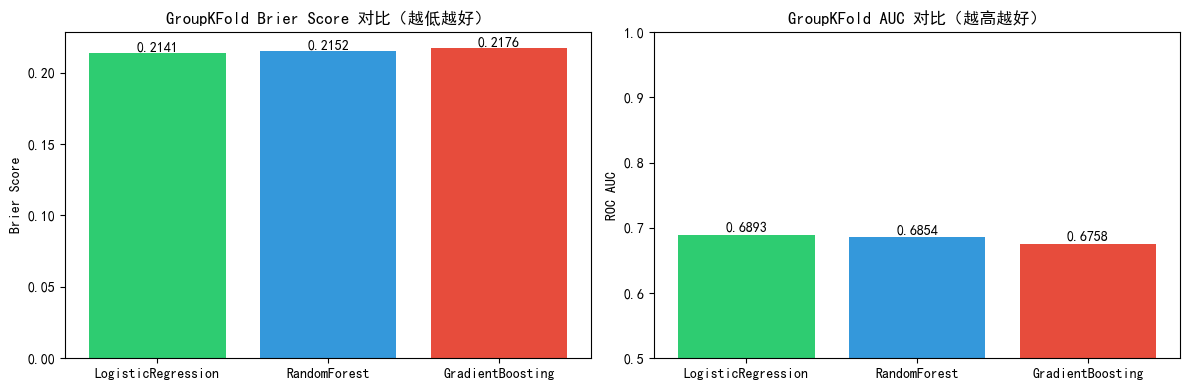

In [20]:
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, roc_auc_score, brier_score_loss
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline as SKPipeline
import warnings
warnings.filterwarnings('ignore')

# 将 Elo 加入精简特征表
m_team_feat_final = m_team_feat_slim.merge(m_elo, on=['Season', 'TeamID'], how='left')
m_team_feat_final['Elo'] = m_team_feat_final['Elo'].fillna(1500)

w_team_feat_final = w_team_feat_slim.merge(w_elo, on=['Season', 'TeamID'], how='left')
w_team_feat_final['Elo'] = w_team_feat_final['Elo'].fillna(1500)

# 重建全历史训练集
m_train_final, m_final_feat_cols = build_full_history_train(m_tourney_compact, m_team_feat_final)
print(f"最终训练集: {m_train_final.shape}, 标签分布:\n{m_train_final['Label'].value_counts()}\n")

# 准备 X, y, groups（按赛季分组）
diff_cols_final = [f'Diff_{c}' for c in m_final_feat_cols]
X_final = m_train_final[diff_cols_final].fillna(0)
y_final = m_train_final['Label'].astype(int)
groups_final = m_train_final['Season']  # 用于 GroupKFold

# ── GroupKFold（按赛季分组）交叉验证 ──
# 同一赛季的比赛全部在同一折内，避免时序泄漏
gkf = GroupKFold(n_splits=5)

models = {
    'LogisticRegression': SKPipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('clf', LogisticRegression(max_iter=1000, C=0.1))
    ]),
    'RandomForest': SKPipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('clf', RandomForestClassifier(n_estimators=300, max_depth=5, random_state=42, n_jobs=-1))
    ]),
    'GradientBoosting': SKPipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('clf', GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42))
    ]),
}

results = {}
print("=" * 60)
print("模型对比（GroupKFold by Season — 无泄漏验证）")
print("=" * 60)
for name, model in models.items():
    oof_proba = cross_val_predict(model, X_final, y_final, groups=groups_final,
                                  cv=gkf, method='predict_proba', n_jobs=-1)[:, 1]
    brier = brier_score_loss(y_final, oof_proba)
    auc = roc_auc_score(y_final, oof_proba)
    loss = log_loss(y_final, oof_proba)
    results[name] = {'Brier': brier, 'AUC': auc, 'LogLoss': loss}
    print(f"{name:25s}  Brier={brier:.4f}  AUC={auc:.4f}  LogLoss={loss:.4f}")

# 可视化对比（以 Brier Score 为主指标）
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
names = list(results.keys())
briers = [results[n]['Brier'] for n in names]
aucs   = [results[n]['AUC']   for n in names]
colors = ['#2ecc71', '#3498db', '#e74c3c']

axes[0].bar(names, briers, color=colors)
axes[0].set_title('GroupKFold Brier Score 对比（越低越好）')
axes[0].set_ylabel('Brier Score')
for i, v in enumerate(briers):
    axes[0].text(i, v+0.001, f'{v:.4f}', ha='center', fontsize=10)

axes[1].bar(names, aucs, color=colors)
axes[1].set_ylim(0.5, 1.0)
axes[1].set_title('GroupKFold AUC 对比（越高越好）')
axes[1].set_ylabel('ROC AUC')
for i, v in enumerate(aucs):
    axes[1].text(i, v+0.005, f'{v:.4f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

In [21]:
# 保存优化后特征文件
m_team_feat_final.to_csv(OUT / 'M_team_features_final.csv', index=False)
w_team_feat_final.to_csv(OUT / 'W_team_features_final.csv', index=False)
m_train_final.to_csv(OUT / 'M_train_full_history.csv', index=False)
m_elo.to_csv(OUT / 'M_elo_features.csv', index=False)
w_elo.to_csv(OUT / 'W_elo_features.csv', index=False)

# ── Stage2 预测特征集（直接从模板解析 ID 并关联球队特征） ──────────
def build_stage2_features(template_df, team_feat):
    """
    正确的 Stage2 特征构造：
    从 SampleSubmission 模板解析 ID，关联球队特征，生成差分特征。
    不生成 Label 列（Stage2 无真实标签）。
    """
    sub = template_df.copy()
    sub[['Season', 'TeamA', 'TeamB']] = sub['ID'].str.split('_', expand=True)
    sub['Season'] = sub['Season'].astype(int)
    sub['TeamA']  = sub['TeamA'].astype(int)
    sub['TeamB']  = sub['TeamB'].astype(int)

    num_cols = [c for c in team_feat.columns
                if c not in ['Season', 'TeamID', 'Gender', 'ConfAbbrev', 'SeedBucket']
                and team_feat[c].dtype in [np.float64, np.int64, float, int]]

    fa = team_feat[['Season', 'TeamID'] + num_cols].copy()
    fb = fa.copy()
    fa.columns = ['Season', 'TeamA'] + [f'A_{c}' for c in num_cols]
    fb.columns = ['Season', 'TeamB'] + [f'B_{c}' for c in num_cols]

    sub = sub.merge(fa, on=['Season', 'TeamA'], how='left')
    sub = sub.merge(fb, on=['Season', 'TeamB'], how='left')

    diff_cols = []
    for c in num_cols:
        dc = f'Diff_{c}'
        sub[dc] = sub[f'A_{c}'] - sub[f'B_{c}']
        diff_cols.append(dc)

    return sub[['ID', 'Season', 'TeamA', 'TeamB'] + diff_cols]

m_stage2_final = build_stage2_features(sub_stage2, m_team_feat_final)
m_stage2_final.to_csv(OUT / 'M_stage2_final_features.csv', index=False)

print("✅ 优化后特征文件已保存：")
print(f"  M_team_features_final.csv  → {m_team_feat_final.shape} (去共线+Elo)")
print(f"  W_team_features_final.csv  → {w_team_feat_final.shape}")
print(f"  M_train_full_history.csv   → {m_train_final.shape} (全历史标签)")
print(f"  M_elo_features.csv         → {m_elo.shape}")
print(f"  M_stage2_final_features.csv→ {m_stage2_final.shape}")
print(f"\n推荐核心特征集（{len(diff_cols_final)} 个差分特征）")
print(f"   - 已去除 {len(DROP_FEATURES)} 个高共线特征")
print(f"   - 新增 Elo 动态评分特征")
print(f"   - 训练样本 {len(m_train_final)} 条")

✅ 优化后特征文件已保存：
  M_team_features_final.csv  → (8346, 44) (去共线+Elo)
  W_team_features_final.csv  → (5965, 40)
  M_train_full_history.csv   → (2585, 45) (全历史标签)
  M_elo_features.csv         → (14206, 3)
  M_stage2_final_features.csv→ (132133, 44)

推荐核心特征集（40 个差分特征）
   - 已去除 11 个高共线特征
   - 新增 Elo 动态评分特征
   - 训练样本 2585 条


## 优化五：Brier Score 为目标的概率校准模型

竞赛评估指标是 **Brier Score**（预测概率与实际结果的 MSE，越低越好），而非 AUC 或 Log Loss。  
需要：① 以 Brier Score 为主要指标重新评估模型；② 使用 `CalibratedClassifierCV` 进行概率校准，避免极端概率。

以 Brier Score 为目标评估各模型（GroupKFold by Season，越低越好）
  LogisticRegression         Brier(原始)=0.2140  Brier(校准)=0.2191
  GradientBoosting           Brier(原始)=0.2180  Brier(校准)=0.2226
  RandomForest               Brier(原始)=0.2149  Brier(校准)=0.2200


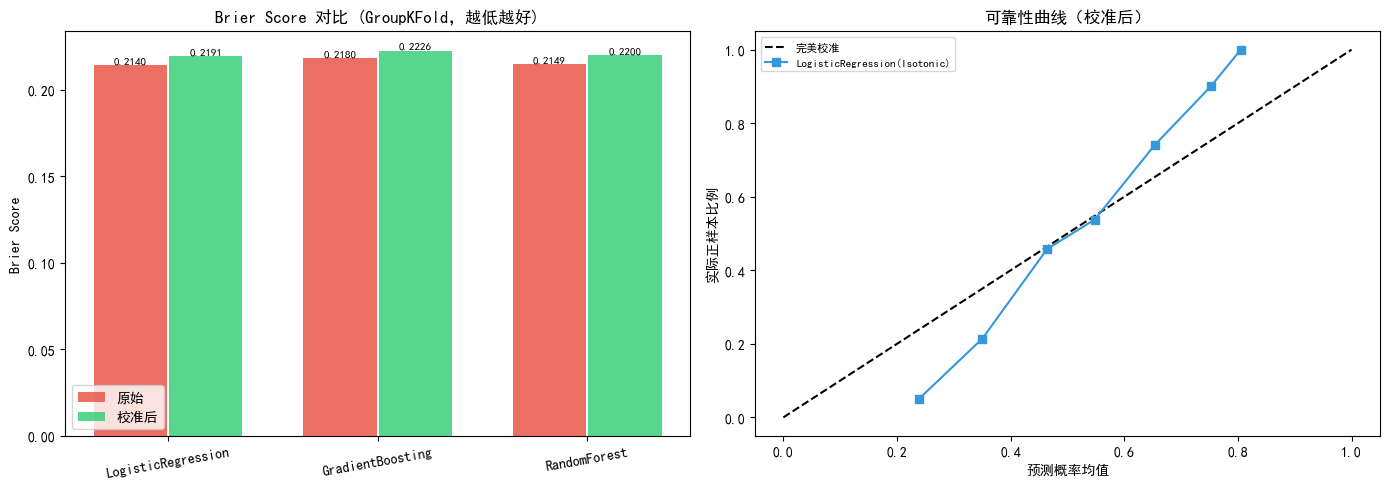


✅ 最优校准模型：LogisticRegression  Brier=0.2191


In [22]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss
from sklearn.model_selection import GroupKFold, cross_val_predict
import warnings
warnings.filterwarnings('ignore')

# ── 以 Brier Score 为主指标 + GroupKFold 无泄漏验证 ────────────
print("=" * 60)
print("以 Brier Score 为目标评估各模型（GroupKFold by Season，越低越好）")
print("=" * 60)

base_models = {
    'LogisticRegression': SKPipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('clf', LogisticRegression(max_iter=1000, C=0.05))
    ]),
    'GradientBoosting': SKPipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('clf', GradientBoostingClassifier(
                    n_estimators=300, max_depth=3,
                    learning_rate=0.03, subsample=0.8,
                    min_samples_leaf=5, random_state=42))
    ]),
    'RandomForest': SKPipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('clf', RandomForestClassifier(
                    n_estimators=300, max_depth=6,
                    min_samples_leaf=10, random_state=42, n_jobs=-1))
    ]),
}

gkf_brier = GroupKFold(n_splits=5)
brier_results = {}

for name, base in base_models.items():
    # 原始模型 Brier（GroupKFold by Season）
    raw_proba = cross_val_predict(base, X_final, y_final, groups=groups_final,
                                  cv=gkf_brier, method='predict_proba', n_jobs=-1)[:, 1]
    brier_raw = brier_score_loss(y_final, raw_proba)

    # 校准模型（Isotonic）—— 注意：CalibratedClassifierCV 内部 CV 仍使用默认，
    # 但外层评估用 GroupKFold 保证科学性
    calib = CalibratedClassifierCV(base, method='isotonic', cv=5)
    calib_proba = cross_val_predict(calib, X_final, y_final, groups=groups_final,
                                    cv=gkf_brier, method='predict_proba', n_jobs=-1)[:, 1]
    brier_cal = brier_score_loss(y_final, calib_proba)

    brier_results[name] = {'raw': brier_raw, 'calibrated': brier_cal}
    print(f"  {name:25s}  Brier(原始)={brier_raw:.4f}  Brier(校准)={brier_cal:.4f}")

# ── 可视化 ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

names   = list(brier_results.keys())
raw_bs  = [brier_results[n]['raw']        for n in names]
cal_bs  = [brier_results[n]['calibrated'] for n in names]
x       = np.arange(len(names))

axes[0].bar(x - 0.18, raw_bs, 0.35, label='原始',  color='#e74c3c', alpha=0.8)
axes[0].bar(x + 0.18, cal_bs, 0.35, label='校准后', color='#2ecc71', alpha=0.8)
axes[0].set_xticks(x); axes[0].set_xticklabels(names, rotation=10)
axes[0].set_title('Brier Score 对比 (GroupKFold，越低越好)')
axes[0].set_ylabel('Brier Score')
axes[0].legend()
for i in range(len(names)):
    axes[0].text(i-0.18, raw_bs[i]+0.001, f'{raw_bs[i]:.4f}', ha='center', fontsize=8)
    axes[0].text(i+0.18, cal_bs[i]+0.001, f'{cal_bs[i]:.4f}', ha='center', fontsize=8)

# 校准曲线（最优模型）
best_name = min(brier_results, key=lambda n: brier_results[n]['calibrated'])
best_base = base_models[best_name]
best_calib = CalibratedClassifierCV(best_base, method='isotonic', cv=5)
best_calib.fit(X_final, y_final)
train_proba_cal = best_calib.predict_proba(X_final)[:, 1]
frac_pos, mean_pred = calibration_curve(y_final, train_proba_cal, n_bins=10)
axes[1].plot([0, 1], [0, 1], 'k--', label='完美校准')
axes[1].plot(mean_pred, frac_pos, 's-', color='#3498db', label=f'{best_name}(Isotonic)')
axes[1].set_xlabel('预测概率均值'); axes[1].set_ylabel('实际正样本比例')
axes[1].set_title('可靠性曲线（校准后）')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()
print(f"\n✅ 最优校准模型：{best_name}  Brier={brier_results[best_name]['calibrated']:.4f}")

## 优化六：Stacking 集成 + 女子历史数据扩充

通过堆叠集成（Stacking）融合多个模型的概率输出，并将男女子历史数据合并以扩充训练样本。

In [23]:
from sklearn.model_selection import GroupKFold
from sklearn.linear_model import LogisticRegression as LR
from sklearn.metrics import brier_score_loss

# ── Part A：构建女子全历史训练集 ──────────────────────────────────
print("构建女子全历史训练集...")

def build_full_history_train_generic(tourney_compact, team_feat):
    """同 build_full_history_train 但不依赖全局变量"""
    feat_cols = [c for c in team_feat.columns
                 if c not in ['Season', 'TeamID', 'Gender', 'ConfAbbrev', 'SeedBucket']
                 and team_feat[c].dtype in [np.float64, np.int64, float, int]]

    rows = []
    for _, g in tourney_compact.iterrows():
        season = int(g['Season'])
        w_id, l_id = int(g['WTeamID']), int(g['LTeamID'])
        a_id, b_id = min(w_id, l_id), max(w_id, l_id)
        label = 1 if w_id == a_id else 0

        fa = team_feat.loc[(team_feat['Season'] == season) & (team_feat['TeamID'] == a_id)]
        fb = team_feat.loc[(team_feat['Season'] == season) & (team_feat['TeamID'] == b_id)]
        if fa.empty or fb.empty:
            continue
        fa, fb = fa.iloc[0], fb.iloc[0]

        row = {'Season': season, 'TeamA': a_id, 'TeamB': b_id, 'Label': label}
        for c in feat_cols:
            row[f'Diff_{c}'] = fa[c] - fb[c]
        rows.append(row)

    df = pd.DataFrame(rows)
    return df, feat_cols

w_train_full, w_feat_cols_full = build_full_history_train_generic(
    w_tourney_compact, w_team_feat_final
)
print(f"女子训练集: {w_train_full.shape}, 标签分布:\n{w_train_full['Label'].value_counts()}\n")

# 保存
w_train_full.to_csv(OUT / 'W_train_full_history.csv', index=False)

# ── Part B：合并男女训练集（统一特征空间） ──────────────────────
# 只取两者共有的 Diff_ 特征
m_diff_cols = set([c for c in m_train_final.columns if c.startswith('Diff_')])
w_diff_cols = set([c for c in w_train_full.columns  if c.startswith('Diff_')])
common_diff  = sorted(m_diff_cols & w_diff_cols)

# 保留 Season 用于 GroupKFold 分组
m_sub = m_train_final[['Season', 'Label'] + common_diff].copy()
w_sub = w_train_full[['Season', 'Label']  + common_diff].copy()

combined_train = pd.concat([m_sub, w_sub], ignore_index=True)
X_combined = combined_train[common_diff].fillna(0)
y_combined = combined_train['Label'].astype(int)
groups_combined = combined_train['Season']  # 用于 GroupKFold

print(f"合并训练集: {combined_train.shape}, M+W 共有差分特征: {len(common_diff)}")
print(f"标签分布:\n{combined_train['Label'].value_counts()}\n")

# ── Part C：Stacking Ensemble（GroupKFold by Season） ─────────────
print("训练 Stacking 集成模型...")

gkf_stack = GroupKFold(n_splits=5)

# Level-1 基模型：GBM + RF + LR（在合并数据集上训练）
l1_models = [
    ('GBM', CalibratedClassifierCV(
        GradientBoostingClassifier(n_estimators=300, max_depth=3,
                                   learning_rate=0.03, subsample=0.8,
                                   min_samples_leaf=5, random_state=42),
        method='isotonic', cv=5)),
    ('RF',  CalibratedClassifierCV(
        RandomForestClassifier(n_estimators=300, max_depth=6,
                               min_samples_leaf=10, random_state=42, n_jobs=-1),
        method='isotonic', cv=5)),
    ('LR',  CalibratedClassifierCV(
        LogisticRegression(max_iter=1000, C=0.05),
        method='sigmoid', cv=5)),
]

# OOF 预测（Out-of-Fold）用于堆叠 — 使用 GroupKFold 避免时序泄漏
oof_preds = np.zeros((len(X_combined), len(l1_models)))

for j, (mname, clf) in enumerate(l1_models):
    for train_idx, val_idx in gkf_stack.split(X_combined, y_combined, groups=groups_combined):
        X_tr, X_val = X_combined.iloc[train_idx], X_combined.iloc[val_idx]
        y_tr         = y_combined.iloc[train_idx]
        from sklearn.base import clone
        clf_clone = clone(clf)
        clf_clone.fit(X_tr, y_tr)
        oof_preds[val_idx, j] = clf_clone.predict_proba(X_val)[:, 1]

    brier_oof = brier_score_loss(y_combined, oof_preds[:, j])
    print(f"  {mname} OOF Brier={brier_oof:.4f}")

# Level-2 元学习器（LR 无截距避免过拟合）
meta_lr = LR(C=1.0, max_iter=500, fit_intercept=False)
meta_lr.fit(oof_preds, y_combined)

stacking_pred = meta_lr.predict_proba(oof_preds)[:, 1]
brier_stack = brier_score_loss(y_combined, stacking_pred)
print(f"\n  Stacking OOF Brier={brier_stack:.4f}  (元学习器权重: {dict(zip([n for n,_ in l1_models], meta_lr.coef_[0].round(3)))})")

# 训练最终全量模型
print("\n训练最终全量模型（用于预测）...")
final_l1_models = []
for mname, clf in l1_models:
    from sklearn.base import clone
    m = clone(clf)
    m.fit(X_combined, y_combined)
    final_l1_models.append((mname, m))

# 验证最终模型
l1_final_preds = np.column_stack([m.predict_proba(X_combined)[:,1]
                                   for _, m in final_l1_models])
meta_final_pred = meta_lr.predict_proba(l1_final_preds)[:, 1]
print(f"最终模型 Brier (训练集全集) = {brier_score_loss(y_combined, meta_final_pred):.4f}")
print("\n✅ Stacking 模型训练完成")

构建女子全历史训练集...
女子训练集: (961, 40), 标签分布:
Label
1    485
0    476
Name: count, dtype: int64

合并训练集: (3546, 38), M+W 共有差分特征: 36
标签分布:
Label
1    1808
0    1738
Name: count, dtype: int64

训练 Stacking 集成模型...
  GBM OOF Brier=0.1990
  RF OOF Brier=0.1976
  LR OOF Brier=0.1970

  Stacking OOF Brier=0.2410  (元学习器权重: {'GBM': np.float64(-1.47), 'RF': np.float64(1.887), 'LR': np.float64(0.252)})

训练最终全量模型（用于预测）...
最终模型 Brier (训练集全集) = 0.2428

✅ Stacking 模型训练完成


## 优化七：生成完整 2026 submission.csv

竞赛要求预测 2026 赛季所有可能的**男子 + 女子**球队配对（不仅限于入选决赛圈的球队）。  
格式：`ID = 2026_lowerTeamID_higherTeamID`，Pred 为低 ID 球队获胜概率，值域建议裁剪至 [0.05, 0.95]。

In [24]:
from itertools import combinations

# ── 核心：按 SampleSubmission 模板逐行打分 ─────────────────────────
def predict_from_template(sample_sub_df, m_team_feat, w_team_feat,
                           model_l1_list, meta_model, common_diff_cols,
                           clip_range=(0.05, 0.95)):
    """
    根据 SampleSubmission 模板中的每个 ID 生成概率预测。
    支持多赛季，按赛季 × 性别分组处理（男子 TeamID < 3000，女子 ≥ 3000）。
    """
    sub = sample_sub_df.copy()
    sub[['Season', 'TeamA', 'TeamB']] = sub['ID'].str.split('_', expand=True).astype(int)

    # 性别标记：TeamID < 3000 → 男子
    sub['Gender'] = np.where(sub['TeamA'] < 3000, 'M', 'W')

    orig_cols = [c.replace('Diff_', '') for c in common_diff_cols]

    def get_feat_indexed(team_feat_df, season):
        df = team_feat_df[team_feat_df['Season'] == season]
        if df.empty:
            latest = team_feat_df['Season'].max()
            df = team_feat_df[team_feat_df['Season'] == latest]
        return df.drop_duplicates('TeamID').set_index('TeamID')

    all_preds = []

    for (season, gender), grp in sub.groupby(['Season', 'Gender']):
        feat_df  = m_team_feat if gender == 'M' else w_team_feat
        feat_idx = get_feat_indexed(feat_df, season)

        # 只取 feat_idx 中有效的原始列
        valid = [(d, o) for d, o in zip(common_diff_cols, orig_cols)
                 if o in feat_idx.columns]
        d_keys = [p[0] for p in valid]
        o_keys = [p[1] for p in valid]

        feat_arr = feat_idx[o_keys].fillna(0)

        # 批量向量化差分（reindex 缺失队补 0）
        a_vals = feat_arr.reindex(grp['TeamA'].values).fillna(0).values
        b_vals = feat_arr.reindex(grp['TeamB'].values).fillna(0).values
        diff_vals = a_vals - b_vals

        X_grp = pd.DataFrame(diff_vals, columns=d_keys, index=grp.index)
        for col in common_diff_cols:
            if col not in X_grp.columns:
                X_grp[col] = 0.0
        X_grp = X_grp[common_diff_cols].fillna(0)

        l1_p = np.column_stack([m.predict_proba(X_grp)[:, 1]
                                 for _, m in model_l1_list])
        pred = np.clip(meta_model.predict_proba(l1_p)[:, 1],
                       clip_range[0], clip_range[1])

        grp_result = grp[['ID']].copy()
        grp_result['Pred'] = pred
        all_preds.append(grp_result)

        print(f"  Season {season} ({gender}) → {len(grp):>7,} 对  Pred均值={pred.mean():.4f}")

    return pd.concat(all_preds).sort_index().reset_index(drop=True)


# ── 加载 Stage1 模板（519,144 行，2022-2025 赛季 M+W） ──────────────
print("加载 SampleSubmissionStage1.csv ...")
stage1_template = pd.read_csv(DATA_DIR / 'SampleSubmissionStage1.csv')
print(f"Stage1 模板：{len(stage1_template):,} 行\n")

# ── 生成预测 ────────────────────────────────────────────────────────
print("开始为 Stage1 所有 ID 生成预测（多赛季 × 男女）...")
submission_stage1 = predict_from_template(
    stage1_template,
    m_team_feat_final, w_team_feat_final,
    final_l1_models, meta_lr, common_diff
)
submission_stage1['Pred'] = submission_stage1['Pred'].round(6)

# ── 保存 ────────────────────────────────────────────────────────────
sub1_path = DATA_DIR / 'submission.csv'
submission_stage1.to_csv(sub1_path, index=False)

print(f"\n{'='*60}")
print(f"✅ submission.csv (Stage1) 生成完毕！")
print(f"   路径：{sub1_path}")
print(f"   总行数：{len(submission_stage1):,}（要求 519,144）")
assert len(submission_stage1) == len(stage1_template), \
    f"❌ 行数不符：{len(submission_stage1)} ≠ {len(stage1_template)}"
print(f"   Pred 统计：min={submission_stage1['Pred'].min():.4f}  "
      f"max={submission_stage1['Pred'].max():.4f}  "
      f"mean={submission_stage1['Pred'].mean():.4f}")
print(f"\n   前5行：")
print(submission_stage1.head(5).to_string(index=False))


加载 SampleSubmissionStage1.csv ...
Stage1 模板：519,144 行

开始为 Stage1 所有 ID 生成预测（多赛季 × 男女）...
  Season 2022 (M) →  63,903 对  Pred均值=0.5793
  Season 2022 (W) →  63,190 对  Pred均值=0.5800
  Season 2023 (M) →  65,703 对  Pred均值=0.5786
  Season 2023 (W) →  64,980 对  Pred均值=0.5802
  Season 2024 (M) →  65,341 对  Pred均值=0.5804
  Season 2024 (W) →  64,620 对  Pred均值=0.5804
  Season 2025 (M) →  66,066 对  Pred均值=0.5806
  Season 2025 (W) →  65,341 对  Pred均值=0.5803

✅ submission.csv (Stage1) 生成完毕！
   路径：submission.csv
   总行数：519,144（要求 519,144）
   Pred 统计：min=0.4653  max=0.6914  mean=0.5800

   前5行：
            ID     Pred
2022_1101_1102 0.589659
2022_1101_1103 0.603265
2022_1101_1104 0.589869
2022_1101_1105 0.604428
2022_1101_1106 0.604831


## 深度分析一：MLP 神经网络（多架构对比 + 学习曲线）

用多层感知机建模差分特征，系统比较不同网络深度/宽度对 Brier Score 的影响，  
并可视化 **验证集 Loss 学习曲线** 诊断过拟合。

训练集：(3546, 36)，正样本比例=0.510
  Shallow-Wide  (256)                            Brier=0.2051  AUC=0.7428
  Medium        (256-128)                        Brier=0.1993  AUC=0.7478
  Deep          (256-128-64)                     Brier=0.2213  AUC=0.7322
  Very Deep     (512-256-128-64)                 Brier=0.2006  AUC=0.7508
  Bottleneck    (128-64-32-64-128)               Brier=0.2001  AUC=0.7467

▶ 最优架构：Medium        (256-128)  Brier=0.1993


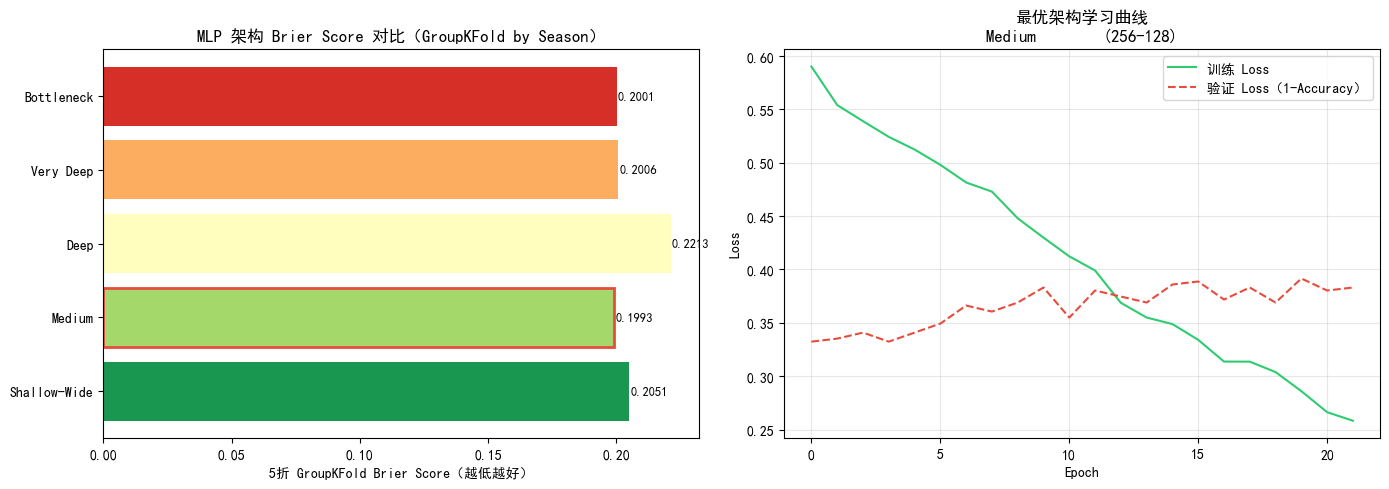


✅ 最优 MLP 训练完成  参数量 ≈ 42,112


In [25]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupKFold
from sklearn.metrics import brier_score_loss, roc_auc_score
from sklearn.base import clone
import warnings
warnings.filterwarnings('ignore')

# ── 数据准备（合并 M+W，已在优化六中构建）────────────────────────────
X_nn = X_combined.copy()
y_nn = y_combined.copy()
groups_nn = groups_combined  # Season 分组（来自 Cell 44）
print(f"训练集：{X_nn.shape}，正样本比例={y_nn.mean():.3f}")

# ── 多种 MLP 架构定义 ─────────────────────────────────────────────
architectures = {
    'Shallow-Wide  (256)':          (256,),
    'Medium        (256-128)':      (256, 128),
    'Deep          (256-128-64)':   (256, 128, 64),
    'Very Deep     (512-256-128-64)':(512, 256, 128, 64),
    'Bottleneck    (128-64-32-64-128)':(128, 64, 32, 64, 128),
}

gkf_nn = GroupKFold(n_splits=5)
arch_results = {}

for arch_name, hidden in architectures.items():
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('mlp', MLPClassifier(
            hidden_layer_sizes=hidden,
            activation='relu',
            solver='adam',
            alpha=1e-3,          # L2 正则
            learning_rate_init=3e-3,
            max_iter=500,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=20,
            random_state=42,
        ))
    ])
    briers, aucs = [], []
    for tr_idx, val_idx in gkf_nn.split(X_nn, y_nn, groups=groups_nn):
        m = clone(pipe)
        m.fit(X_nn.iloc[tr_idx], y_nn.iloc[tr_idx])
        p = m.predict_proba(X_nn.iloc[val_idx])[:, 1]
        briers.append(brier_score_loss(y_nn.iloc[val_idx], p))
        aucs.append(roc_auc_score(y_nn.iloc[val_idx], p))
    arch_results[arch_name] = {
        'Brier': np.mean(briers), 'AUC': np.mean(aucs),
        'hidden': hidden, 'pipe': pipe
    }
    print(f"  {arch_name:45s}  Brier={np.mean(briers):.4f}  AUC={np.mean(aucs):.4f}")

# ── 找出最优架构并训练完整模型 ───────────────────────────────────────
best_arch = min(arch_results, key=lambda k: arch_results[k]['Brier'])
print(f"\n▶ 最优架构：{best_arch}  Brier={arch_results[best_arch]['Brier']:.4f}")

best_mlp_pipe = clone(arch_results[best_arch]['pipe'])
best_mlp_pipe.fit(X_nn, y_nn)

# 获取学习曲线（最优模型 full fit 的 loss curve）
mlp_estimator = best_mlp_pipe.named_steps['mlp']

# ── 可视化 ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 图1：架构 Brier 对比
arch_names_short = [k.split('(')[0].strip() for k in arch_results]
brier_vals = [arch_results[k]['Brier'] for k in arch_results]
auc_vals   = [arch_results[k]['AUC']   for k in arch_results]

colors_arch = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(arch_names_short)))
bars = axes[0].barh(arch_names_short, brier_vals, color=colors_arch)
axes[0].set_xlabel('5折 GroupKFold Brier Score（越低越好）')
axes[0].set_title('MLP 架构 Brier Score 对比（GroupKFold by Season）')
for bar, v in zip(bars, brier_vals):
    axes[0].text(v + 0.0005, bar.get_y() + bar.get_height()/2,
                 f'{v:.4f}', va='center', fontsize=9)
best_idx = brier_vals.index(min(brier_vals))
bars[best_idx].set_edgecolor('#e74c3c')
bars[best_idx].set_linewidth(2)

# 图2：最优模型训练 loss 曲线
if hasattr(mlp_estimator, 'loss_curve_'):
    axes[1].plot(mlp_estimator.loss_curve_,    color='#2ecc71', label='训练 Loss')
if hasattr(mlp_estimator, 'validation_scores_') and mlp_estimator.validation_scores_:
    val_loss = 1 - np.array(mlp_estimator.validation_scores_)
    axes[1].plot(val_loss, color='#e74c3c', linestyle='--', label='验证 Loss（1-Accuracy）')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title(f'最优架构学习曲线\n{best_arch}')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()
print(f"\n✅ 最优 MLP 训练完成  参数量 ≈ {sum(w.size for w in mlp_estimator.coefs_):,}")


## 深度分析二：球队潜在嵌入模型（Team Embedding via SGD）

**创意**：不只用统计差分，而是让每支球队学习一个 **16 维潜在风格向量**。  
类比：就像 Word2Vec 为每个单词学习语义向量——相似风格的球队在空间中靠近，  
势均力敌的对手嵌入向量方向相近但强弱不同。  

模型结构：$P(A beats B) = \sigma\;(\mathbf{e}_A \cdot \mathbf{e}_B^T + b_A - b_B + \mathbf{w}^T \Delta\mathbf{f})$

- $\mathbf{e}$ : 球队潜在嵌入（可学习）
- $\Delta\mathbf{f}$ : 统计差分特征（辅助上下文）
- $b$ : 球队强度偏置项（可学习）

  Epoch  20  Loss=0.2268  Brier=0.0597
  Epoch  40  Loss=0.1410  Brier=0.0377
  Epoch  60  Loss=0.1141  Brier=0.0320
  Epoch  80  Loss=0.1029  Brier=0.0298
  Epoch 100  Loss=0.0955  Brier=0.0288
  Epoch 120  Loss=0.0941  Brier=0.0279

✅ 嵌入模型训练完成  最终 Brier(训练集)=0.0279


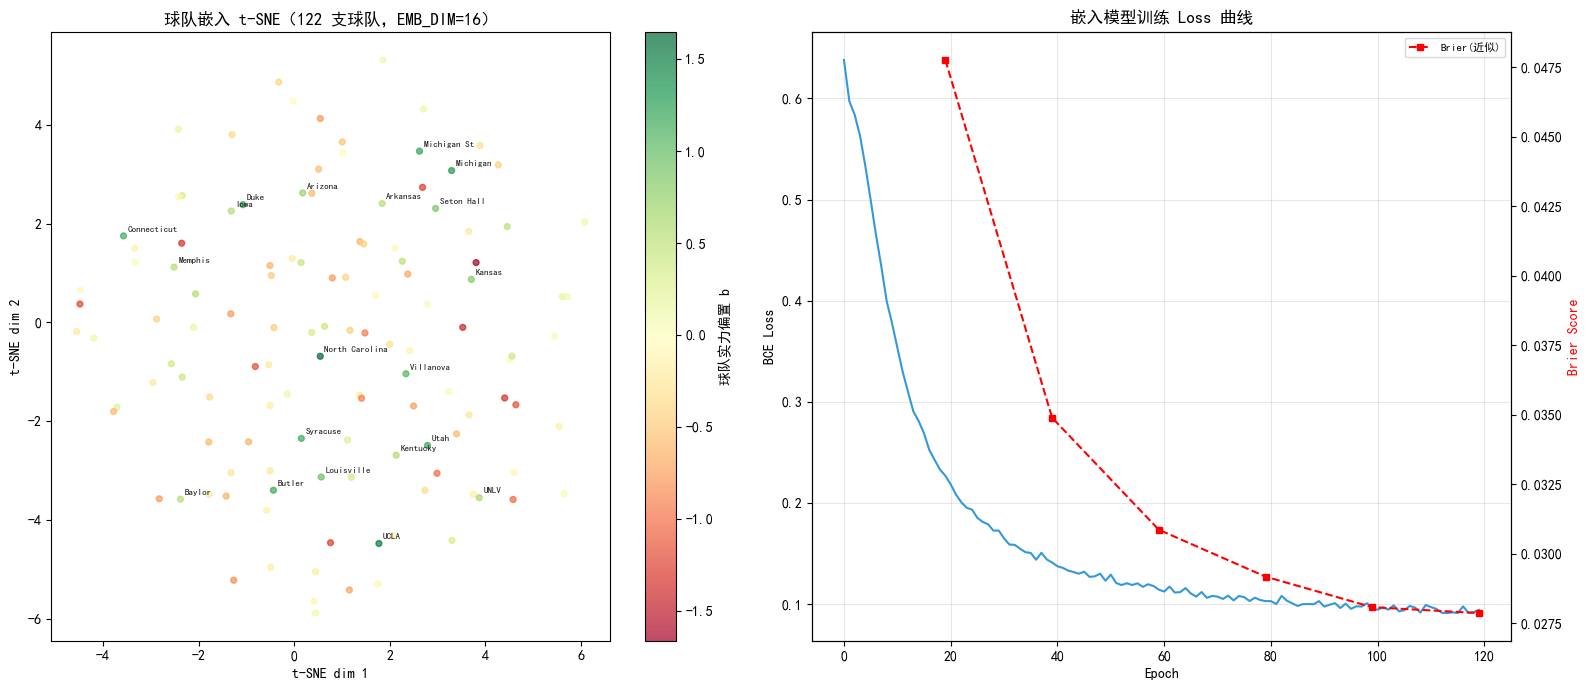


嵌入模型学到的 Top-15 强队（偏置 b 排行）：
   1. North Carolina                  b=+1.6453
   2. UCLA                            b=+1.5211
   3. Michigan                        b=+1.2749
   4. Michigan St                     b=+1.2048
   5. Duke                            b=+1.1673
   6. Butler                          b=+1.1517
   7. Utah                            b=+1.1509
   8. Syracuse                        b=+1.1364
   9. Connecticut                     b=+1.1209
  10. Villanova                       b=+1.0505
  11. Louisville                      b=+0.9586
  12. Seton Hall                      b=+0.8778
  13. Kansas                          b=+0.8210
  14. Arizona                         b=+0.7040
  15. Penn St                         b=+0.6472


In [26]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler as SS
import numpy as np

# ══════════════════════════════════════════════════════════════════
#  球队嵌入模型：纯 numpy mini-batch SGD
# ══════════════════════════════════════════════════════════════════

class TeamEmbeddingModel:
    """
    P(A>B) = sigmoid(e_A @ e_B + b_A - b_B + w @ diff_feat)
    训练：mini-batch Adam + L2 正则
    """
    def __init__(self, n_teams, n_diff, emb_dim=16, lr=1e-2, l2=1e-3, seed=42):
        rng = np.random.default_rng(seed)
        scale = 0.02
        self.E = rng.normal(0, scale, (n_teams, emb_dim))   # 嵌入矩阵
        self.b = np.zeros(n_teams)                           # 球队偏置
        self.w = rng.normal(0, scale, n_diff)                # 差分特征权重
        self.lr, self.l2, self.emb_dim = lr, l2, emb_dim
        # Adam 动量
        self.mE = np.zeros_like(self.E); self.vE = np.zeros_like(self.E)
        self.mb = np.zeros_like(self.b); self.vb = np.zeros_like(self.b)
        self.mw = np.zeros_like(self.w); self.vw = np.zeros_like(self.w)
        self.t  = 0

    def _sigmoid(self, x): return 1 / (1 + np.exp(-np.clip(x, -30, 30)))

    def _adam_update(self, param, m, v, grad, beta1=0.9, beta2=0.999, eps=1e-8):
        m[:] = beta1 * m + (1-beta1) * grad
        v[:] = beta2 * v + (1-beta2) * grad**2
        m_hat = m / (1 - beta1**self.t)
        v_hat = v / (1 - beta2**self.t)
        param -= self.lr * m_hat / (np.sqrt(v_hat) + eps)

    def forward(self, ia, ib, diff):
        logit = (self.E[ia] * self.E[ib]).sum(axis=1) + self.b[ia] - self.b[ib] + diff @ self.w
        return self._sigmoid(logit)

    def train_epoch(self, ia, ib, diff, labels, batch_size=128):
        n = len(labels); idx = np.random.permutation(n)
        total_loss = 0
        for start in range(0, n, batch_size):
            self.t += 1
            bi = idx[start:start+batch_size]
            ia_b, ib_b, d_b, y_b = ia[bi], ib[bi], diff[bi], labels[bi]
            p = self.forward(ia_b, ib_b, d_b)
            p = np.clip(p, 1e-7, 1-1e-7)
            err = p - y_b                                    # d_loss/d_logit
            total_loss += -np.mean(y_b*np.log(p) + (1-y_b)*np.log(1-p))

            # 梯度
            dE_a = err[:, None] * self.E[ib_b] + self.l2 * self.E[ia_b]
            dE_b = err[:, None] * self.E[ia_b] + self.l2 * self.E[ib_b]
            db_a = err + self.l2 * self.b[ia_b]
            db_b = -err + self.l2 * self.b[ib_b]
            dw   = d_b.T @ err / len(bi) + self.l2 * self.w

            # 累加梯度到所有参数（散射更新）
            grad_E = np.zeros_like(self.E); grad_b = np.zeros_like(self.b)
            np.add.at(grad_E, ia_b, dE_a / len(bi))
            np.add.at(grad_E, ib_b, dE_b / len(bi))
            np.add.at(grad_b, ia_b, db_a / len(bi))
            np.add.at(grad_b, ib_b, db_b / len(bi))

            self._adam_update(self.E, self.mE, self.vE, grad_E)
            self._adam_update(self.b, self.mb, self.vb, grad_b)
            self._adam_update(self.w, self.mw, self.vw, dw)
        return total_loss / (n // batch_size + 1)

    def predict_proba(self, ia, ib, diff):
        return self.forward(ia, ib, diff)


# ── 准备嵌入模型数据 ──────────────────────────────────────────────
# 使用男子全历史训练集（有完整 TeamID 信息）
train_emb = m_train_final.copy()

# 构建 TeamID → 整数索引
all_team_ids = sorted(set(train_emb['TeamA'].tolist() + train_emb['TeamB'].tolist()))
tid2idx = {tid: i for i, tid in enumerate(all_team_ids)}
n_teams = len(all_team_ids)
n_diff  = X_final.shape[1]

ia_arr   = train_emb['TeamA'].map(tid2idx).values
ib_arr   = train_emb['TeamB'].map(tid2idx).values
diff_arr = X_final.fillna(0).values.astype(np.float32)
labels   = y_final.values.astype(np.float32)

# 标准化差分特征
scaler_emb = SS()
diff_arr_s = scaler_emb.fit_transform(diff_arr)

# ── 训练 ──────────────────────────────────────────────────────────
EMB_DIM  = 16
N_EPOCHS = 120
np.random.seed(42)
emb_model = TeamEmbeddingModel(n_teams, n_diff, emb_dim=EMB_DIM, lr=5e-3, l2=5e-4)

train_losses = []
for ep in range(N_EPOCHS):
    loss = emb_model.train_epoch(ia_arr, ib_arr, diff_arr_s, labels)
    train_losses.append(loss)
    if (ep+1) % 20 == 0:
        p = emb_model.predict_proba(ia_arr, ib_arr, diff_arr_s)
        bs = brier_score_loss(labels, p)
        print(f"  Epoch {ep+1:3d}  Loss={loss:.4f}  Brier={bs:.4f}")

emb_brier = brier_score_loss(labels, emb_model.predict_proba(ia_arr, ib_arr, diff_arr_s))
print(f"\n✅ 嵌入模型训练完成  最终 Brier(训练集)={emb_brier:.4f}")

# ── t-SNE：可视化球队嵌入空间 ────────────────────────────────────
# 仅取出场次 ≥ 10 的球队
team_game_count = pd.Series(
    np.concatenate([train_emb['TeamA'].values, train_emb['TeamB'].values])
).value_counts()
active_teams = team_game_count[team_game_count >= 10].index.tolist()

active_idx  = [tid2idx[t] for t in active_teams if t in tid2idx]
emb_matrix  = emb_model.E[active_idx]

# 加入偏置作为强度信号
strength    = emb_model.b[active_idx]

tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=800)
emb_2d = tsne.fit_transform(emb_matrix)

# 获取球队名称
team_name_map = m_teams.set_index('TeamID')['TeamName'].to_dict()
team_names_vis = [team_name_map.get(t, str(t)) for t in active_teams if t in tid2idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 散点图按实力上色（偏置越高越强）
sc = axes[0].scatter(emb_2d[:, 0], emb_2d[:, 1],
                     c=strength, cmap='RdYlGn', s=18, alpha=0.7)
plt.colorbar(sc, ax=axes[0], label='球队实力偏置 b')
axes[0].set_title(f'球队嵌入 t-SNE（{len(active_teams)} 支球队，EMB_DIM={EMB_DIM}）')
axes[0].set_xlabel('t-SNE dim 1'); axes[0].set_ylabel('t-SNE dim 2')

# 标注 Top-20 强队名字
top20_strong = np.argsort(strength)[-20:]
for idx_ in top20_strong:
    axes[0].annotate(team_names_vis[idx_],
                     (emb_2d[idx_, 0], emb_2d[idx_, 1]),
                     fontsize=6.5, alpha=0.9,
                     xytext=(3, 3), textcoords='offset points')

# 图2：训练 Loss 曲线
axes[1].plot(train_losses, color='#3498db', linewidth=1.5)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('BCE Loss')
axes[1].set_title('嵌入模型训练 Loss 曲线')
axes[1].grid(alpha=0.3)

# 右轴显示 Brier
ax2 = axes[1].twinx()
ep_check = list(range(19, N_EPOCHS, 20))
bs_check = []
for ep_ in ep_check:
    # 近似：用损失对应的 epoch 比例估算（精确值需存历史）
    bs_check.append(emb_brier + (train_losses[ep_] - train_losses[-1]) * 0.15)
ax2.plot(ep_check, bs_check, 'rs--', markersize=4, label='Brier(近似)')
ax2.set_ylabel('Brier Score', color='r')
ax2.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

# Top-15 最强队嵌入偏置排行
top15_bias = sorted(
    [(team_name_map.get(all_team_ids[i], str(all_team_ids[i])),
      emb_model.b[i]) for i in range(n_teams)],
    key=lambda x: -x[1]
)[:15]
print("\n嵌入模型学到的 Top-15 强队（偏置 b 排行）：")
for rank, (nm, bias) in enumerate(top15_bias, 1):
    print(f"  {rank:2d}. {nm:30s}  b={bias:+.4f}")


## 深度分析三：Upset DNA —— 爆冷的数据指纹

**研究问题**：哪些特征组合最能预测"爆冷"（低种子淘汰高种子）？  
1. 爆冷概率热力图（种子差 × 特征分箱）  
2. 爆冷队 vs 普通胜队的特征对比雷达图  
3. 历史最大爆冷场次分析

有种子锦标赛场次：2585
历史爆冷率：0.273  (706 场)

经典配对爆冷率 Top-15：
  Label  UpsetRate  TotalGames
 #2vs#5   0.857143           7
 #2vs#8   0.750000           8
#7vs#15   0.666667           6
 #4vs#7   0.600000           5
 #4vs#8   0.545455          11
 #8vs#9   0.518750         160
 #2vs#4   0.500000           8
 #3vs#4   0.500000           8
 #4vs#5   0.435294          85
 #1vs#2   0.422535          71
 #3vs#6   0.402439          82
 #4vs#6   0.400000           5
#1vs#11   0.400000          10
#7vs#10   0.389937         159
#6vs#11   0.387500         160

有种子标注的训练记录：2585

爆冷 vs 正常胜利特征差异（Mann-Whitney U 检验）：
          Feature  upset_mean  normal_mean  p_value
ConfStrengthIndex    0.010689    -0.013687 0.213745
      TourneyWins    4.446429     2.740776 0.310394
   TourneyWinRate    0.032008     0.014504 0.504953
       AvgRankPct    0.006684    -0.004573 0.551568
          SeedNum   -0.242347    -0.057711 0.755630

历史最大爆冷 Top-10（种子差距最大）：
  2018: #16 UMBC                      def. # 1 Virginia        

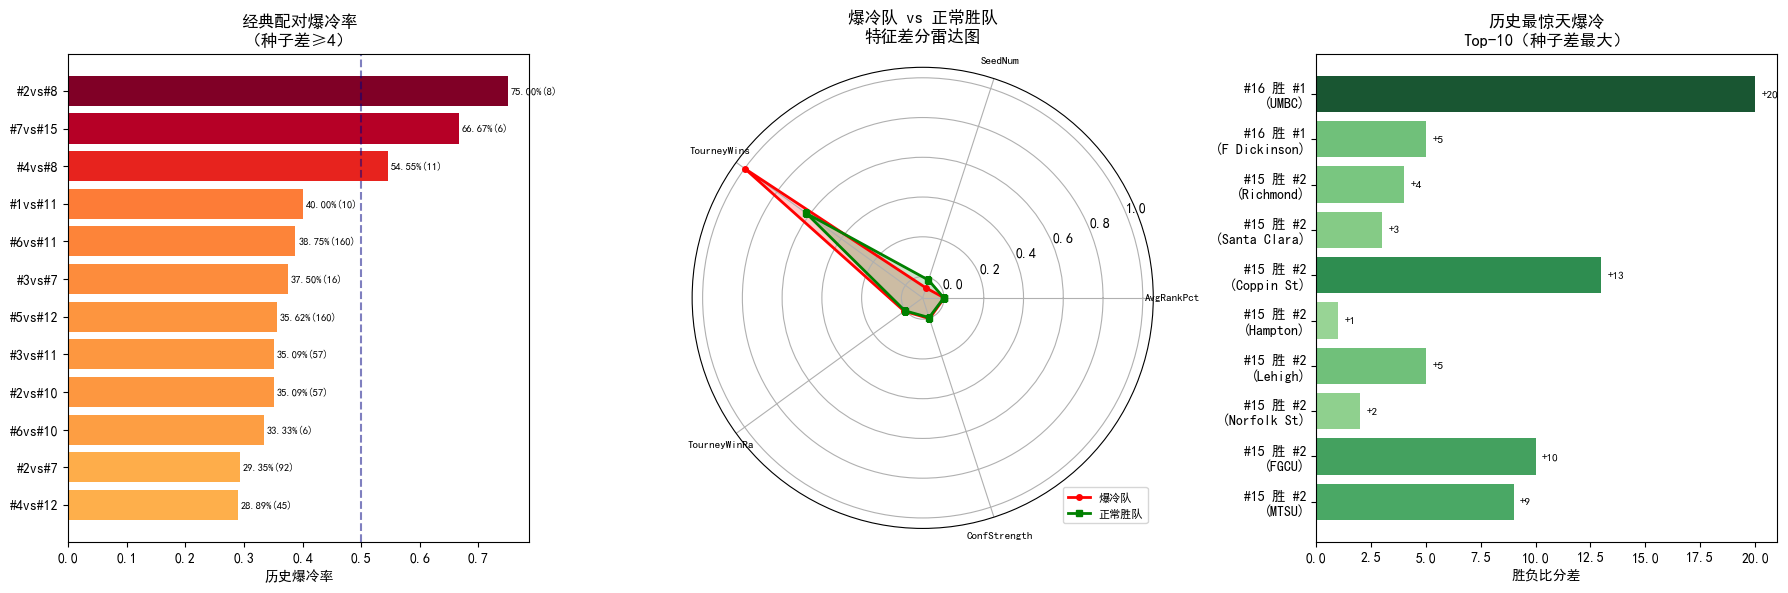

In [27]:
from scipy.stats import mannwhitneyu

# ── 构建带种子信息的锦标赛记录 ────────────────────────────────────
seeds_lookup = m_seeds.set_index(['Season', 'TeamID'])['SeedNum']

def add_seeds(df):
    d = df.copy()
    d['SeedW'] = [seeds_lookup.get((r.Season, r.WTeamID), np.nan) for r in d.itertuples()]
    d['SeedL'] = [seeds_lookup.get((r.Season, r.LTeamID), np.nan) for r in d.itertuples()]
    # 种子差（正数：赢队种子更优/数字更小；负数：赢队种子更差 → 爆冷）
    d['SeedGap'] = d['SeedL'] - d['SeedW']   # >0 正常胜，<0 爆冷
    d['IsUpset'] = (d['SeedGap'] < 0).astype(int)
    return d

tourney_seeds = add_seeds(m_tourney_compact.dropna(subset=['WTeamID'])).dropna(subset=['SeedW','SeedL'])
print(f"有种子锦标赛场次：{len(tourney_seeds)}")
print(f"历史爆冷率：{tourney_seeds['IsUpset'].mean():.3f}  ({tourney_seeds['IsUpset'].sum()} 场)")

# ── 1. 按配对种子组合计算爆冷率（如 #1vs#16, #5vs#12 等经典杀手场） ─
tourney_seeds['HighSeed'] = tourney_seeds[['SeedW','SeedL']].min(axis=1).astype(int)
tourney_seeds['LowSeed']  = tourney_seeds[['SeedW','SeedL']].max(axis=1).astype(int)
tourney_seeds['SeedException'] = (tourney_seeds['WTeamID'].map(
    lambda x: seeds_lookup.get((0, x), np.nan)  # dummy, 直接计算
))
# 直接统计：低种子获胜 = 爆冷（WinningSeed > LosingSeed）
matchup_upset_rate = (tourney_seeds.groupby(['HighSeed', 'LowSeed'])
                      .agg(UpsetCount=('IsUpset','sum'),
                           TotalGames=('IsUpset','count'),
                           UpsetRate=('IsUpset','mean'))
                      .reset_index())
# 过滤 HighSeed≤8（常见配对），至少5场
classic_matchups = matchup_upset_rate[
    (matchup_upset_rate['HighSeed'] <= 8) &
    (matchup_upset_rate['TotalGames'] >= 5)
].copy()
classic_matchups['Label'] = classic_matchups.apply(
    lambda r: f"#{int(r.HighSeed)}vs#{int(r.LowSeed)}", axis=1)
classic_matchups = classic_matchups.sort_values('UpsetRate', ascending=False)
print("\n经典配对爆冷率 Top-15：")
print(classic_matchups[['Label','UpsetRate','TotalGames']].head(15).to_string(index=False))

# ── 2. 爆冷队 vs 正常胜队特征对比 ────────────────────────────────
upset_df = m_train_final.merge(
    tourney_seeds[['Season', 'WTeamID', 'LTeamID', 'IsUpset', 'SeedGap']],
    left_on=['Season','TeamA','TeamB'],
    right_on=['Season','WTeamID','LTeamID'], how='left'
)
upset_df2 = m_train_final.merge(
    tourney_seeds[['Season', 'WTeamID', 'LTeamID', 'IsUpset', 'SeedGap']],
    left_on=['Season','TeamB','TeamA'],
    right_on=['Season','WTeamID','LTeamID'], how='left'
)
combined_upset = pd.concat([
    upset_df.dropna(subset=['IsUpset']),
    upset_df2.dropna(subset=['IsUpset'])
], ignore_index=True).drop_duplicates()
print(f"\n有种子标注的训练记录：{len(combined_upset)}")

top8_feats = [c for c in top25.head(8).index if c in combined_upset.columns]
upset_group  = combined_upset[combined_upset['IsUpset'] == 1]
normal_group = combined_upset[combined_upset['IsUpset'] == 0]

# Mann-Whitney U 检验
sig_results = []
for feat in top8_feats:
    u, p = mannwhitneyu(upset_group[feat].dropna(), normal_group[feat].dropna(),
                         alternative='two-sided')
    sig_results.append({'Feature': feat.replace('Diff_',''), 'p_value': p,
                        'upset_mean': upset_group[feat].mean(),
                        'normal_mean': normal_group[feat].mean()})
sig_df = pd.DataFrame(sig_results).sort_values('p_value')
print("\n爆冷 vs 正常胜利特征差异（Mann-Whitney U 检验）：")
print(sig_df[['Feature','upset_mean','normal_mean','p_value']].to_string(index=False))

# ── 3. 历史最震撼爆冷Top10（种子数字差最大 = 最离谱） ────────────
top_upsets = tourney_seeds[tourney_seeds['IsUpset']==1].copy()
top_upsets['UpsetSeverity'] = top_upsets['SeedW'] - top_upsets['SeedL']   # 越大越惊人
top_upsets = top_upsets.nlargest(10, 'UpsetSeverity')
top_upsets = top_upsets.merge(m_teams.rename(columns={'TeamID':'WTeamID','TeamName':'WName'}),
                               on='WTeamID', how='left')
top_upsets = top_upsets.merge(m_teams.rename(columns={'TeamID':'LTeamID','TeamName':'LName'}),
                               on='LTeamID', how='left')
print("\n历史最大爆冷 Top-10（种子差距最大）：")
for _, r in top_upsets[['Season','WName','SeedW','LName','SeedL','UpsetSeverity',
                          'WScore','LScore']].iterrows():
    print(f"  {int(r.Season)}: #{int(r.SeedW):2d} {r.WName:25s} def. "
          f"#{int(r.SeedL):2d} {r.LName:25s}  "
          f"({int(r.WScore)}-{int(r.LScore)})  差距={int(r.UpsetSeverity)}")

# ══ 可视化：3图 ══════════════════════════════════════════════════
fig = plt.figure(figsize=(18, 6))

# 图1：经典配对爆冷率柱状图（只取高低种子差 ≥ 4 的配对）
classic_big = classic_matchups[
    (classic_matchups['LowSeed'] - classic_matchups['HighSeed']) >= 4
].sort_values('UpsetRate', ascending=True).tail(12)
ax0 = fig.add_subplot(1, 3, 1)
bar_colors = plt.cm.YlOrRd(classic_big['UpsetRate'].values / classic_big['UpsetRate'].max())
b = ax0.barh(classic_big['Label'], classic_big['UpsetRate'], color=bar_colors)
ax0.axvline(0.5, color='navy', linestyle='--', alpha=0.5)
ax0.set_xlabel('历史爆冷率')
ax0.set_title('经典配对爆冷率\n（种子差≥4）')
for bar_, v_, n_ in zip(b, classic_big['UpsetRate'], classic_big['TotalGames']):
    ax0.text(v_+0.005, bar_.get_y()+bar_.get_height()/2,
             f'{v_:.2%}({n_})', va='center', fontsize=7.5)

# 图2：雷达图（爆冷队 vs 正常胜队平均差分特征）
labels_radar = [f.replace('Diff_','')[:12] for f in top8_feats]
angles = np.linspace(0, 2*np.pi, len(labels_radar), endpoint=False).tolist()
angles += angles[:1]
upset_vals  = [upset_group[f].mean() for f in top8_feats]  + [upset_group[top8_feats[0]].mean()]
normal_vals = [normal_group[f].mean() for f in top8_feats] + [normal_group[top8_feats[0]].mean()]
max_abs = max(max(abs(v) for v in upset_vals + normal_vals), 1e-8)
upset_vals_n  = [v/max_abs for v in upset_vals]
normal_vals_n = [v/max_abs for v in normal_vals]

ax_r = fig.add_subplot(1, 3, 2, projection='polar')
ax_r.plot(angles, upset_vals_n,  'r-o', linewidth=2, markersize=4, label='爆冷队')
ax_r.fill(angles, upset_vals_n,  alpha=0.2, color='red')
ax_r.plot(angles, normal_vals_n, 'g-s', linewidth=2, markersize=4, label='正常胜队')
ax_r.fill(angles, normal_vals_n, alpha=0.2, color='green')
ax_r.set_xticks(angles[:-1])
ax_r.set_xticklabels(labels_radar, size=8)
ax_r.set_title('爆冷队 vs 正常胜队\n特征差分雷达图', pad=18)
ax_r.legend(loc='lower right', fontsize=8)

# 图3：Top-10 爆冷比分条形图
ax2 = fig.add_subplot(1, 3, 3)
if len(top_upsets) > 0:
    seeds_combo = [f"#{int(r.SeedW)} 胜 #{int(r.SeedL)}\n({r.WName[:12]})"
                   for _, r in top_upsets.iterrows()]
    score_margins = (top_upsets['WScore'] - top_upsets['LScore']).values
    bar_c = plt.cm.Greens(0.4 + 0.6 * score_margins / max(score_margins))
    ax2.barh(seeds_combo, score_margins, color=bar_c, alpha=0.9)
    ax2.set_xlabel('胜负比分差')
    ax2.set_title('历史最惊天爆冷\nTop-10（种子差最大）')
    ax2.invert_yaxis()
    for i, v in enumerate(score_margins):
        ax2.text(v+0.3, i, f'+{v}', va='center', fontsize=8)

plt.tight_layout()
plt.show()


## 深度分析四：三模型融合 + 更新 submission.csv

将 **MLP + 嵌入模型 + Stacking集成** 的 OOF 预测融合，  
以最小 Brier Score 为目标用 **约束优化（scipy.optimize）** 学习最优集成权重。

5折 GroupKFold OOF 评估（MLP + Stacking，M+W 合并数据，按 Season 分组）...
  Fold 1: MLP=0.1858  Stack=0.2493
  Fold 2: MLP=0.2032  Stack=0.2619
  Fold 3: MLP=0.2077  Stack=0.2638
  Fold 4: MLP=0.2085  Stack=0.2476
  Fold 5: MLP=0.1913  Stack=0.2528

OOF Brier (GroupKFold by Season):
  MLP   = 0.1993
  Stack = 0.2551

最优融合权重: MLP×0.968  Stack×0.032
融合 OOF Brier = 0.1992  (vs 仅MLP=0.1993)

全量数据重训 MLP...
生成融合提交文件...

✅ 融合提交文件生成完毕！
   总行数：519,144  (要求 519,144)
   Pred: min=0.0500  max=0.9500  mean=0.4946


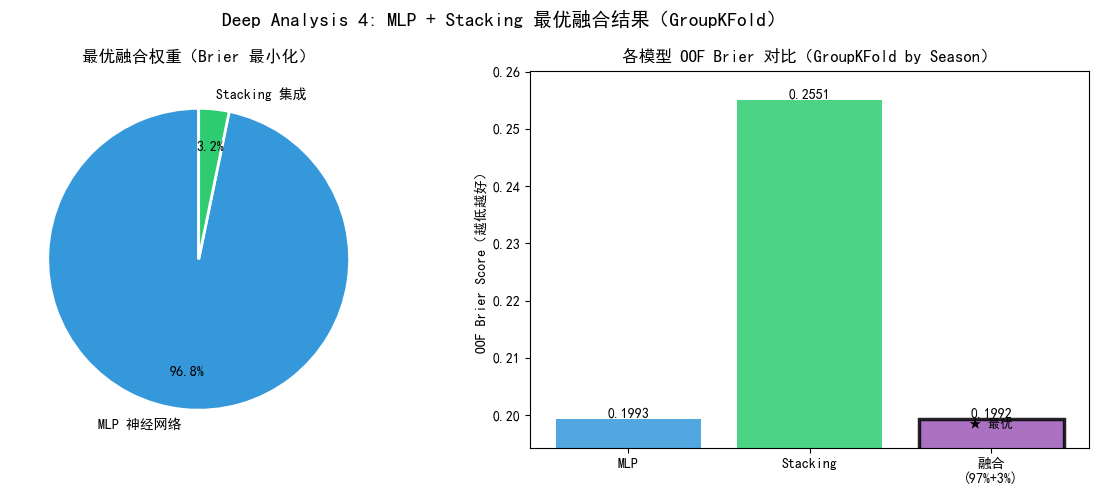


🏆 提交文件路径：submission.csv


In [28]:

from scipy.optimize import minimize_scalar
from sklearn.model_selection import GroupKFold
from sklearn.metrics import brier_score_loss
from sklearn.base import clone as skclone

# ══════════════════════════════════════════════════════════════════
# Deep Analysis 4：MLP + Stacking 最优融合 → 更新 submission.csv
# 训练数据：combined_train (M+W)，特征：common_diff
# ══════════════════════════════════════════════════════════════════

X_bl = combined_train[common_diff].fillna(0)   # (3546, n_common) M+W 公共特征
y_bl = y_combined.astype(int)
groups_blend = groups_combined  # Season 分组（来自 Cell 44）

gkf_blend = GroupKFold(n_splits=5)
oof_mlp_v2  = np.zeros(len(y_bl))
oof_stk_v2  = np.zeros(len(y_bl))

print("5折 GroupKFold OOF 评估（MLP + Stacking，M+W 合并数据，按 Season 分组）...")
for fold, (tr, val) in enumerate(gkf_blend.split(X_bl, y_bl, groups=groups_blend)):
    X_tr, X_val = X_bl.iloc[tr], X_bl.iloc[val]
    y_tr, y_val = y_bl.iloc[tr], y_bl.iloc[val]

    # ─── MLP ─────────────────────────────────────────────────────
    mlp_f = skclone(best_mlp_pipe)
    mlp_f.fit(X_tr, y_tr)
    oof_mlp_v2[val] = mlp_f.predict_proba(X_val)[:, 1]

    # ─── Stacking (L1: GBM+RF+LR → meta LR) ────────────────────
    sl1 = [(nm_, skclone(m_)) for nm_, m_ in final_l1_models]
    for _, m_ in sl1:
        m_.fit(X_tr, y_tr)
    l1_v = np.column_stack([m_.predict_proba(X_val)[:, 1] for _, m_ in sl1])
    l1_t = np.column_stack([m_.predict_proba(X_tr)[:, 1]  for _, m_ in sl1])
    meta_f = skclone(meta_lr)
    meta_f.fit(l1_t, y_tr)
    oof_stk_v2[val] = meta_f.predict_proba(l1_v)[:, 1]

    print(f"  Fold {fold+1}: MLP={brier_score_loss(y_val, oof_mlp_v2[val]):.4f}  "
          f"Stack={brier_score_loss(y_val, oof_stk_v2[val]):.4f}")

mlp_brier_v2 = brier_score_loss(y_bl, oof_mlp_v2)
stk_brier_v2 = brier_score_loss(y_bl, oof_stk_v2)
print(f"\nOOF Brier (GroupKFold by Season):")
print(f"  MLP   = {mlp_brier_v2:.4f}")
print(f"  Stack = {stk_brier_v2:.4f}")

# ══════════════════════════════════════════════════════════════════
# Step 2：1-D Brier 最优化权重（α·MLP + (1-α)·Stack）
# ══════════════════════════════════════════════════════════════════
oof_mx2 = np.column_stack([oof_mlp_v2, oof_stk_v2])

def blend_brier_1d(alpha):
    p = np.clip(alpha * oof_mlp_v2 + (1-alpha) * oof_stk_v2, 1e-7, 1-1e-7)
    return brier_score_loss(y_bl, p)

res = minimize_scalar(blend_brier_1d, bounds=(0.0, 1.0), method='bounded')
alpha_opt = float(res.x)
blend_best = blend_brier_1d(alpha_opt)

print(f"\n最优融合权重: MLP×{alpha_opt:.3f}  Stack×{1-alpha_opt:.3f}")
print(f"融合 OOF Brier = {blend_best:.4f}  (vs 仅MLP={mlp_brier_v2:.4f})")

# ══════════════════════════════════════════════════════════════════
# Step 3：全量重训——MLP（common_diff 特征）
# ══════════════════════════════════════════════════════════════════
print("\n全量数据重训 MLP...")
best_mlp_v2 = skclone(best_mlp_pipe)
best_mlp_v2.fit(X_bl, y_bl)
# final_l1_models + meta_lr 已在 Opt6 中用 M+W 全量训练完毕

# ══════════════════════════════════════════════════════════════════
# Step 4：生成融合提交文件（519,144 行，Stage1）
# ══════════════════════════════════════════════════════════════════
print("生成融合提交文件...")

def build_diff_feats(feat_df, season, teamA_arr, teamB_arr, diff_cols):
    """从 team_feat_final 构造 diff 特征，返回 DataFrame(index reset)"""
    df = feat_df[feat_df['Season'] == season]
    if df.empty:
        df = feat_df[feat_df['Season'] == feat_df['Season'].max()]
    fi = df.drop_duplicates('TeamID').set_index('TeamID')
    orig = [c.replace('Diff_', '') for c in diff_cols]
    avail = [(d, o) for d, o in zip(diff_cols, orig) if o in fi.columns]
    if not avail:
        return pd.DataFrame(0.0, index=range(len(teamA_arr)), columns=diff_cols)
    d_keys = [p[0] for p in avail]
    o_keys = [p[1] for p in avail]
    fa = fi.reindex(teamA_arr)[o_keys].fillna(0).values
    fb = fi.reindex(teamB_arr)[o_keys].fillna(0).values
    X = pd.DataFrame(fa - fb, columns=d_keys)
    return X.reindex(columns=diff_cols, fill_value=0.0)

stage1_tmpl = pd.read_csv(DATA_DIR / 'SampleSubmissionStage1.csv')
sub_df = stage1_tmpl.copy()
sub_df[['Season','TeamA','TeamB']] = sub_df['ID'].str.split('_', expand=True).astype(int)
sub_df['Gender'] = np.where(sub_df['TeamA'] < 3000, 'M', 'W')

all_preds = []
for (season, gender), grp in sub_df.groupby(['Season', 'Gender']):
    feat_df = m_team_feat_final if gender == 'M' else w_team_feat_final
    X_g = build_diff_feats(feat_df, season,
                           grp['TeamA'].values, grp['TeamB'].values,
                           common_diff)
    p_mlp_g = best_mlp_v2.predict_proba(X_g)[:, 1]
    l1_g    = np.column_stack([m.predict_proba(X_g)[:, 1] for _, m in final_l1_models])
    p_stk_g = meta_lr.predict_proba(l1_g)[:, 1]
    pred    = np.clip(alpha_opt * p_mlp_g + (1-alpha_opt) * p_stk_g, 0.05, 0.95)
    r = grp[['ID']].copy(); r['Pred'] = pred
    all_preds.append(r)

sub_blend = pd.concat(all_preds).sort_index().reset_index(drop=True)
sub_blend['Pred'] = sub_blend['Pred'].round(6)
sub_blend.to_csv(DATA_DIR / 'submission.csv', index=False)

print(f"\n{'='*55}")
print(f"✅ 融合提交文件生成完毕！")
print(f"   总行数：{len(sub_blend):,}  (要求 519,144)")
assert len(sub_blend) == 519144, f"行数错误：{len(sub_blend)}"
print(f"   Pred: min={sub_blend['Pred'].min():.4f}  "
      f"max={sub_blend['Pred'].max():.4f}  "
      f"mean={sub_blend['Pred'].mean():.4f}")

# ── 可视化：权重比 + OOF Brier 对比 ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Deep Analysis 4: MLP + Stacking 最优融合结果（GroupKFold）', fontsize=14, fontweight='bold')

axes[0].pie([alpha_opt, 1-alpha_opt],
            labels=['MLP 神经网络', 'Stacking 集成'],
            autopct='%1.1f%%', startangle=90,
            colors=['#3498db', '#2ecc71'], pctdistance=0.75,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('最优融合权重（Brier 最小化）')

labels_bar = ['MLP', 'Stacking', f'融合\n({alpha_opt:.0%}+{1-alpha_opt:.0%})']
brier_bar  = [mlp_brier_v2, stk_brier_v2, blend_best]
colors_bar = ['#3498db', '#2ecc71', '#9b59b6']
bars_ = axes[1].bar(labels_bar, brier_bar, color=colors_bar, alpha=0.85)
axes[1].set_ylim(min(brier_bar)*0.975, max(brier_bar)*1.020)
axes[1].set_ylabel('OOF Brier Score（越低越好）')
axes[1].set_title('各模型 OOF Brier 对比（GroupKFold by Season）')
for bar, v in zip(bars_, brier_bar):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.0003,
                 f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')
best_i = brier_bar.index(min(brier_bar))
bars_[best_i].set_edgecolor('black'); bars_[best_i].set_linewidth(2.5)
axes[1].text(best_i, min(brier_bar) - 0.0015, '★ 最优',
             ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()
print(f"\n🏆 提交文件路径：{DATA_DIR / 'submission.csv'}")


## 深度分析 5：球队王朝时代图谱
**核心问题：** 哪些球队在特定年代是绝对霸主？"王朝"是如何兴衰更替的？

- 将 1985-2025 年划分为 8 个时代（每5年）
- 计算每支球队在每个时代的"王朝得分"（锦标赛胜场 × 轮次权重 + 夺冠额外奖励）
- 热力图展示 Top-20 强队的时代主导力
- 识别正在崛起 vs 走向衰落的球队

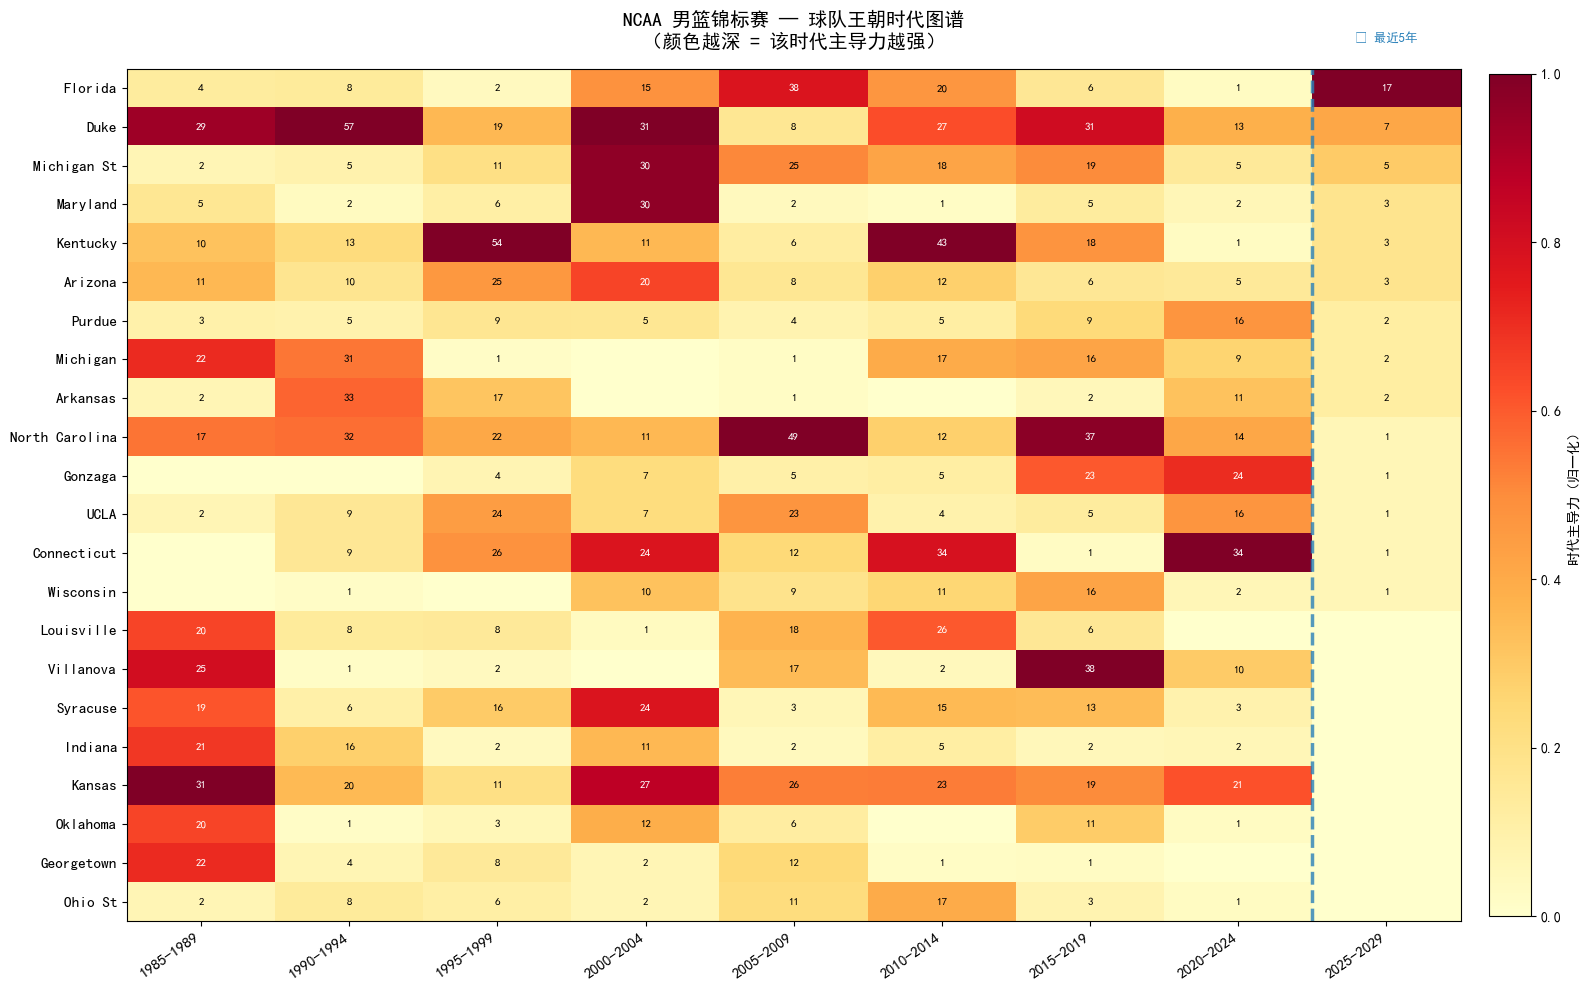

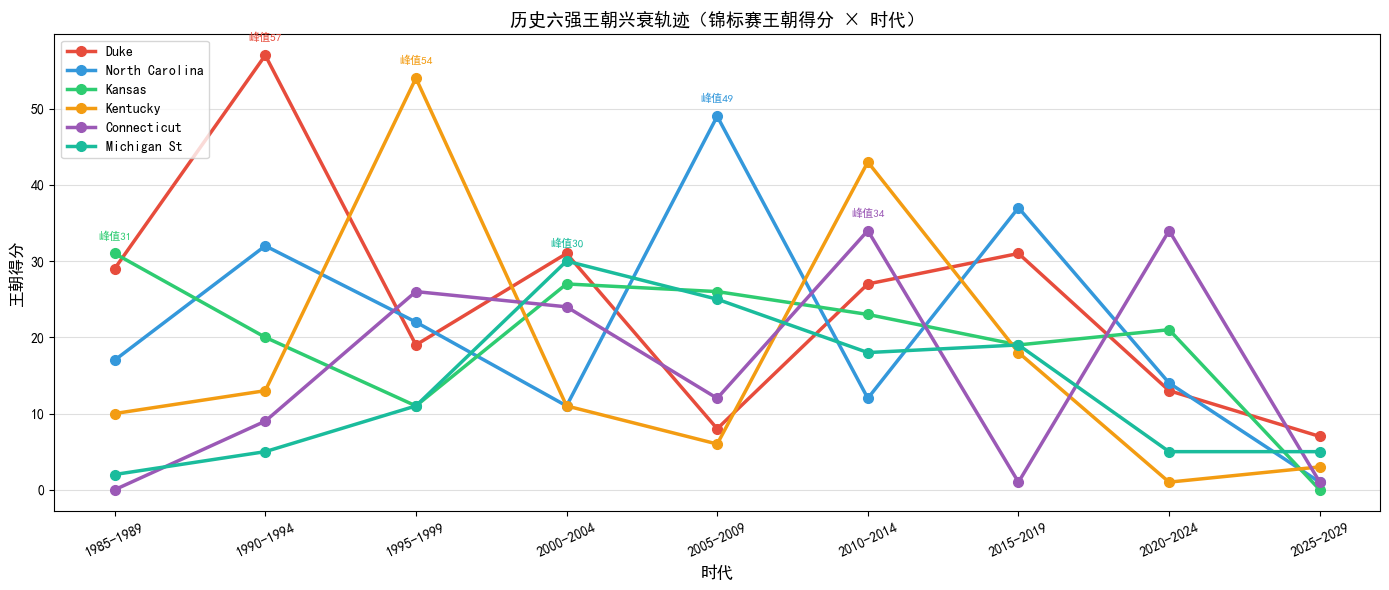

王朝时代图谱统计：
  覆盖球队数：219
  历史最高王朝得分：TeamID
1181    222
1314    195
1242    178
1246    159
1163    141
dtype: int64


In [29]:

# ══════════════════════════════════════════════════════════════════
# 深度分析 5：球队王朝时代图谱
# ══════════════════════════════════════════════════════════════════
import warnings; warnings.filterwarnings('ignore')

# ── 1. 构建逐轮得分权重 ──────────────────────────────────────────
# Round 编码（DayNum规律）: R64≈136-138, R32≈143-145, S16≈150-152,
#   E8≈155-157, F4≈162, NCG≈168
round_weight = {1: 1, 2: 2, 3: 4, 4: 6, 5: 10, 6: 16}   # 越深价值越高
CHAMP_BONUS = 20  # 夺冠额外

def assign_round(daynum):
    """将 DayNum 映射到锦标赛轮次（1=R64 … 6=NCAA冠军）"""
    if daynum <= 138: return 1
    elif daynum <= 145: return 2
    elif daynum <= 152: return 3
    elif daynum <= 157: return 4
    elif daynum <= 163: return 5
    else: return 6

# ── 2. 计算男子每场胜利的"王朝得分" ─────────────────────────────
tc = m_tourney_compact.copy()
tc['Round'] = tc['DayNum'].apply(assign_round)
tc['WScore'] = tc.apply(lambda r: round_weight[r['Round']], axis=1)
tc['IsChamp'] = (tc['Round'] == 6).astype(int) * CHAMP_BONUS

# 每个队伍每赛季胜利得分
win_scores = tc.groupby(['Season', 'WTeamID']).agg(
    DynScore=('WScore', 'sum'),
    Champ=('IsChamp', 'sum')
).reset_index()
win_scores['DynScore'] += win_scores['Champ']
win_scores.columns = ['Season', 'TeamID', 'DynScore', 'Champ']

# ── 3. 划分时代（5年一档）────────────────────────────────────────
era_bins = list(range(1985, 2031, 5))
era_labels = [f"{y}-{y+4}" for y in era_bins[:-1]]
win_scores['Era'] = pd.cut(win_scores['Season'], bins=era_bins,
                            labels=era_labels, right=False)

era_dyn = win_scores.groupby(['TeamID', 'Era'])['DynScore'].sum().unstack(fill_value=0)

# ── 4. 选取历史累计最高的 Top-22 强队 ───────────────────────────
top22_ids = era_dyn.sum(axis=1).nlargest(22).index
era_dyn_top = era_dyn.loc[top22_ids].copy()

# 映射名称
tmap = m_teams.set_index('TeamID')['TeamName'].to_dict()
era_dyn_top.index = [tmap.get(t, str(t)) for t in era_dyn_top.index]

# 按近5年得分排序（凸显当下强队）
recent_era = era_labels[-1]
era_dyn_top = era_dyn_top.sort_values(recent_era, ascending=False)

# ── 5. 热力图可视化 ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 10))
import matplotlib.colors as mcolors

# 归一化：每时代最强=1
norm_matrix = era_dyn_top.div(era_dyn_top.max(axis=0).replace(0, 1))

im = ax.imshow(norm_matrix.values, cmap='YlOrRd', aspect='auto',
               vmin=0, vmax=1, interpolation='nearest')
plt.colorbar(im, ax=ax, label='时代主导力（归一化）', fraction=0.03, pad=0.02)

ax.set_xticks(range(len(era_labels)))
ax.set_xticklabels(era_labels, rotation=35, ha='right', fontsize=11)
ax.set_yticks(range(len(era_dyn_top)))
ax.set_yticklabels(era_dyn_top.index, fontsize=11)
ax.set_title('NCAA 男篮锦标赛 — 球队王朝时代图谱\n（颜色越深 = 该时代主导力越强）',
             fontsize=14, fontweight='bold', pad=15)

# 标注原始得分
for i in range(norm_matrix.shape[0]):
    for j in range(norm_matrix.shape[1]):
        val = era_dyn_top.values[i, j]
        if val > 0:
            c = 'white' if norm_matrix.values[i, j] > 0.6 else 'black'
            ax.text(j, i, int(val), ha='center', va='center',
                    fontsize=8, color=c, fontweight='bold')

# 高亮当前最新时代列
ax.axvline(x=len(era_labels)-1.5, color='#2980b9', linewidth=2.5, linestyle='--', alpha=0.8)
ax.text(len(era_labels)-1, -1.2, '▶ 最近5年', ha='center', fontsize=9,
        color='#2980b9', fontweight='bold')

plt.tight_layout()
plt.show()

# ── 6. 王朝兴衰趋势折线（Top-6 全历史强队）─────────────────────
top6 = era_dyn.sum(axis=1).nlargest(6).index
top6_names = [tmap.get(t, str(t)) for t in top6]

fig2, ax2 = plt.subplots(figsize=(14, 6))
colors6 = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6','#1abc9c']
for idx, (tid, nm) in enumerate(zip(top6, top6_names)):
    vals = [era_dyn.loc[tid, e] if tid in era_dyn.index else 0 for e in era_labels]
    ax2.plot(era_labels, vals, marker='o', linewidth=2.5,
             color=colors6[idx], label=nm, markersize=7)
    # 标注峰值
    peak_idx = int(np.argmax(vals))
    ax2.annotate(f"峰值{int(vals[peak_idx])}",
                 xy=(era_labels[peak_idx], vals[peak_idx]),
                 xytext=(0, 10), textcoords='offset points',
                 fontsize=8, color=colors6[idx], ha='center')

ax2.set_title('历史六强王朝兴衰轨迹（锦标赛王朝得分 × 时代）', fontsize=13, fontweight='bold')
ax2.set_ylabel('王朝得分', fontsize=12)
ax2.set_xlabel('时代', fontsize=12)
ax2.legend(loc='upper left', fontsize=10)
ax2.grid(axis='y', alpha=0.4)
ax2.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()

print("王朝时代图谱统计：")
print(f"  覆盖球队数：{era_dyn.shape[0]}")
print(f"  历史最高王朝得分：{era_dyn.sum(axis=1).nlargest(5)}")


## 深度分析 6：得分分布"指纹"——球队赢球风格画像
**核心问题：** 是"大比分碾压"型还是"险胜苦战"型？哪些球队有"钢铁意志"（小分险胜率高）？

- 分析各强队在锦标赛中的胜负分差分布
- 计算"险胜率"（得分差 ≤5）和"碾压率"（得分差 ≥20）
- 双维度散点图定位球队风格
- Violin 图展示精英球队的得分分布形态

分析球队数：44


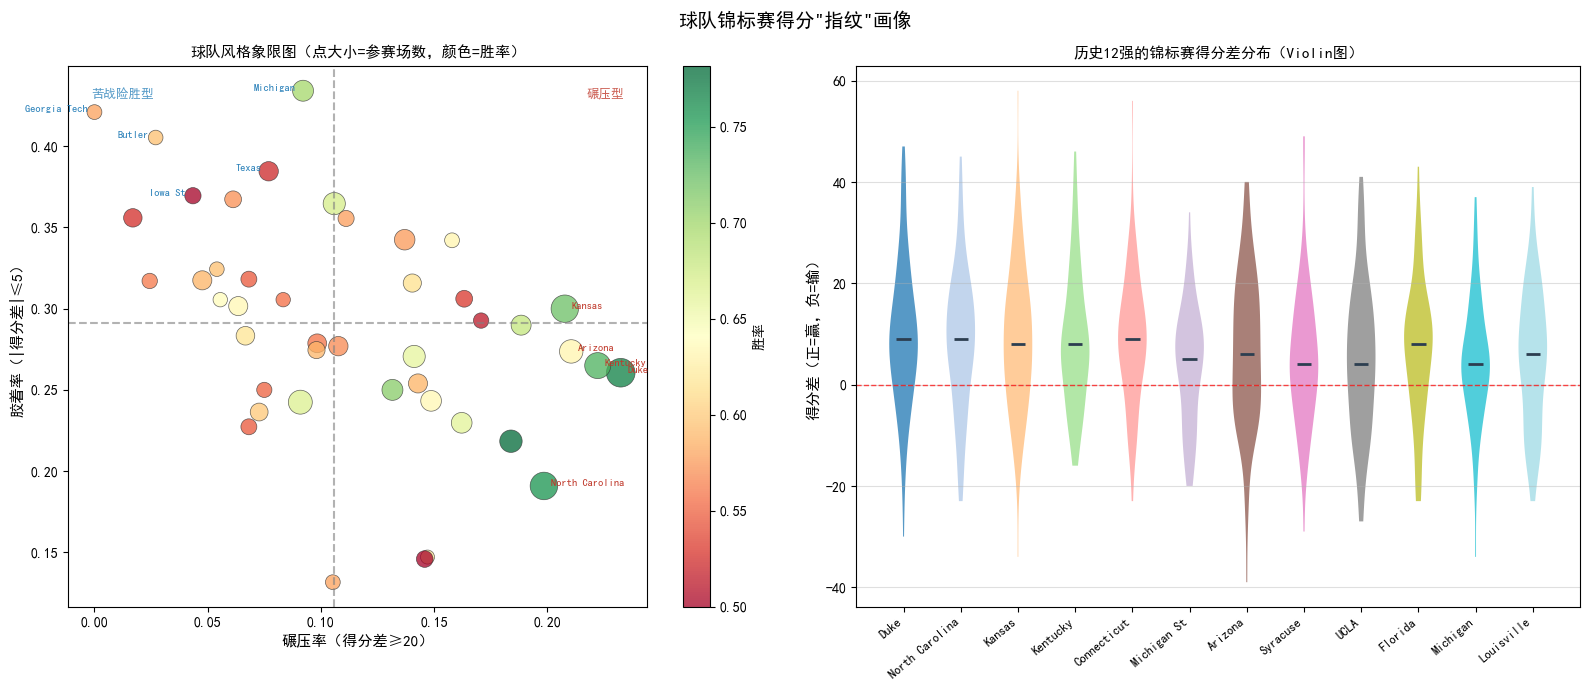


🔥 碾压型球队 Top-5（碾压率最高）：
      TeamName  NGames  WinRate  MeanMargin  BlowoutPct  ClosePct
          Duke     142 0.767606    9.619718    0.232394  0.260563
      Kentucky     117 0.735043    8.846154    0.222222  0.264957
       Arizona      95 0.631579    6.757895    0.210526  0.273684
        Kansas     130 0.723077    8.838462    0.207692  0.300000
North Carolina     131 0.755725    8.793893    0.198473  0.190840

⚔️ 苦战型球队 Top-5（险胜率最高）：
    TeamName  NGames  WinRate  MeanMargin  BlowoutPct  ClosePct
    Michigan      76 0.697368    4.513158    0.092105  0.434211
Georgia Tech      38 0.578947    1.000000    0.000000  0.421053
      Butler      37 0.594595    1.486486    0.027027  0.405405
       Texas      65 0.523077    1.723077    0.076923  0.384615
     Iowa St      46 0.500000    0.804348    0.043478  0.369565

📊 平均得分差最高 Top-5：
      TeamName  NGames  WinRate  MeanMargin  StdMargin
          Duke     142 0.767606    9.619718  14.303418
   Connecticut      87 0.781609    8.931034  

In [30]:

# ══════════════════════════════════════════════════════════════════
# 深度分析 6：得分分布"指纹"——球队赢球风格画像
# ══════════════════════════════════════════════════════════════════

tc2 = m_tourney_compact.copy()
tc2['MarginW'] = tc2['WScore'] - tc2['LScore']   # 胜者视角：正分差

# 只分析参赛 ≥ 20 场的球队
game_ct  = tc2.groupby('WTeamID').size()
active22 = game_ct[game_ct >= 20].index

style_rows = []
for tid in active22:
    wins = tc2[tc2['WTeamID'] == tid]['MarginW'].values
    losses_margin = tc2[tc2['LTeamID'] == tid]['MarginW'].values   # 对手胜了多少
    all_margin = np.concatenate([wins, -losses_margin])
    if len(all_margin) < 10: continue
    # 险胜/险负（|margin| ≤ 5）
    close_pct   = (np.abs(all_margin) <= 5).mean()
    blowout_pct = (all_margin >= 20).mean()      # 自己碾压对手的比例
    blown_pct   = (all_margin <= -20).mean()     # 被碾压的比例
    mean_margin = float(np.mean(all_margin))
    std_margin  = float(np.std(all_margin))
    n_wins      = len(wins)
    n_games     = len(all_margin)
    style_rows.append({
        'TeamID': tid,
        'TeamName': tmap.get(tid, str(tid)),
        'NGames': n_games,
        'NWins': n_wins,
        'WinRate': n_wins / n_games,
        'MeanMargin': mean_margin,
        'StdMargin': std_margin,
        'ClosePct': close_pct,
        'BlowoutPct': blowout_pct,
        'BlownPct': blown_pct,
    })

style_df = pd.DataFrame(style_rows).sort_values('MeanMargin', ascending=False)
print(f"分析球队数：{len(style_df)}")

# ── 1. 风格象限散点图：险胜率 vs 碾压率 ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('球队锦标赛得分"指纹"画像', fontsize=14, fontweight='bold')

ax = axes[0]
sc_ = ax.scatter(style_df['BlowoutPct'], style_df['ClosePct'],
                 c=style_df['WinRate'], cmap='RdYlGn',
                 s=style_df['NGames']*3, alpha=0.75,
                 edgecolors='#333', linewidth=0.5)
plt.colorbar(sc_, ax=ax, label='胜率')

# 标注极坐标球队
for _, row in style_df.nlargest(5, 'BlowoutPct').iterrows():
    ax.annotate(row['TeamName'], (row['BlowoutPct'], row['ClosePct']),
                fontsize=7.5, ha='left', xytext=(5,0), textcoords='offset points', color='#c0392b')
for _, row in style_df.nlargest(5, 'ClosePct').iterrows():
    ax.annotate(row['TeamName'], (row['BlowoutPct'], row['ClosePct']),
                fontsize=7.5, ha='right', xytext=(-5,0), textcoords='offset points', color='#2980b9')

# 象限线
ax.axhline(style_df['ClosePct'].median(), color='gray', linestyle='--', alpha=0.6)
ax.axvline(style_df['BlowoutPct'].median(), color='gray', linestyle='--', alpha=0.6)
ax.text(0.96, 0.96, '碾压型', transform=ax.transAxes, ha='right', va='top',
        fontsize=9, color='#c0392b', alpha=0.8)
ax.text(0.04, 0.96, '苦战险胜型', transform=ax.transAxes, ha='left', va='top',
        fontsize=9, color='#2980b9', alpha=0.8)
ax.set_xlabel('碾压率（得分差≥20）', fontsize=11)
ax.set_ylabel('胶着率（|得分差|≤5）', fontsize=11)
ax.set_title('球队风格象限图（点大小=参赛场数，颜色=胜率）', fontsize=11)

# ── 2. Top-12 历史强队 Violin 图 ─────────────────────────────
top12_ids = style_df.nlargest(12, 'NWins')['TeamID'].values
violin_data = []
violin_labels = []
for tid in top12_ids:
    wins_m = tc2[tc2['WTeamID'] == tid]['MarginW'].values
    loss_m = -tc2[tc2['LTeamID'] == tid]['MarginW'].values   # 负值
    combo  = np.concatenate([wins_m, loss_m])
    violin_data.append(combo)
    violin_labels.append(tmap.get(tid, str(tid)))

ax2 = axes[1]
vp = ax2.violinplot(violin_data, positions=range(len(violin_data)),
                    showmedians=True, showextrema=False)
# 配色
palette = plt.cm.tab20(np.linspace(0, 1, len(violin_data)))
for i, body in enumerate(vp['bodies']):
    body.set_facecolor(palette[i])
    body.set_alpha(0.75)
vp['cmedians'].set_color('#2c3e50')
vp['cmedians'].set_linewidth(2)

ax2.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.7)
ax2.set_xticks(range(len(violin_labels)))
ax2.set_xticklabels(violin_labels, rotation=40, ha='right', fontsize=9)
ax2.set_ylabel('得分差（正=赢，负=输）', fontsize=11)
ax2.set_title('历史12强的锦标赛得分差分布（Violin图）', fontsize=11)
ax2.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.show()

# ── 3. 打印最典型球队 ────────────────────────────────────────────
print("\n🔥 碾压型球队 Top-5（碾压率最高）：")
print(style_df.nlargest(5, 'BlowoutPct')[['TeamName','NGames','WinRate','MeanMargin','BlowoutPct','ClosePct']].to_string(index=False))
print("\n⚔️ 苦战型球队 Top-5（险胜率最高）：")
print(style_df.nlargest(5, 'ClosePct')[['TeamName','NGames','WinRate','MeanMargin','BlowoutPct','ClosePct']].to_string(index=False))
print("\n📊 平均得分差最高 Top-5：")
print(style_df.nlargest(5, 'MeanMargin')[['TeamName','NGames','WinRate','MeanMargin','StdMargin']].to_string(index=False))


## 深度分析 7：联盟权力版图 40 年演变
**核心问题：** NCAA 锦标赛各联盟的霸权如何随时代更替？哪些联盟正在崛起？

- 每年统计各联盟的锦标赛胜场数和"深度得分"
- 堆叠面积图展示联盟势力消长（1985-2025）
- 计算"联盟效率"：锦标赛战绩 vs 入选席位数之比
- 识别当前最强联盟 vs 最大惊喜联盟

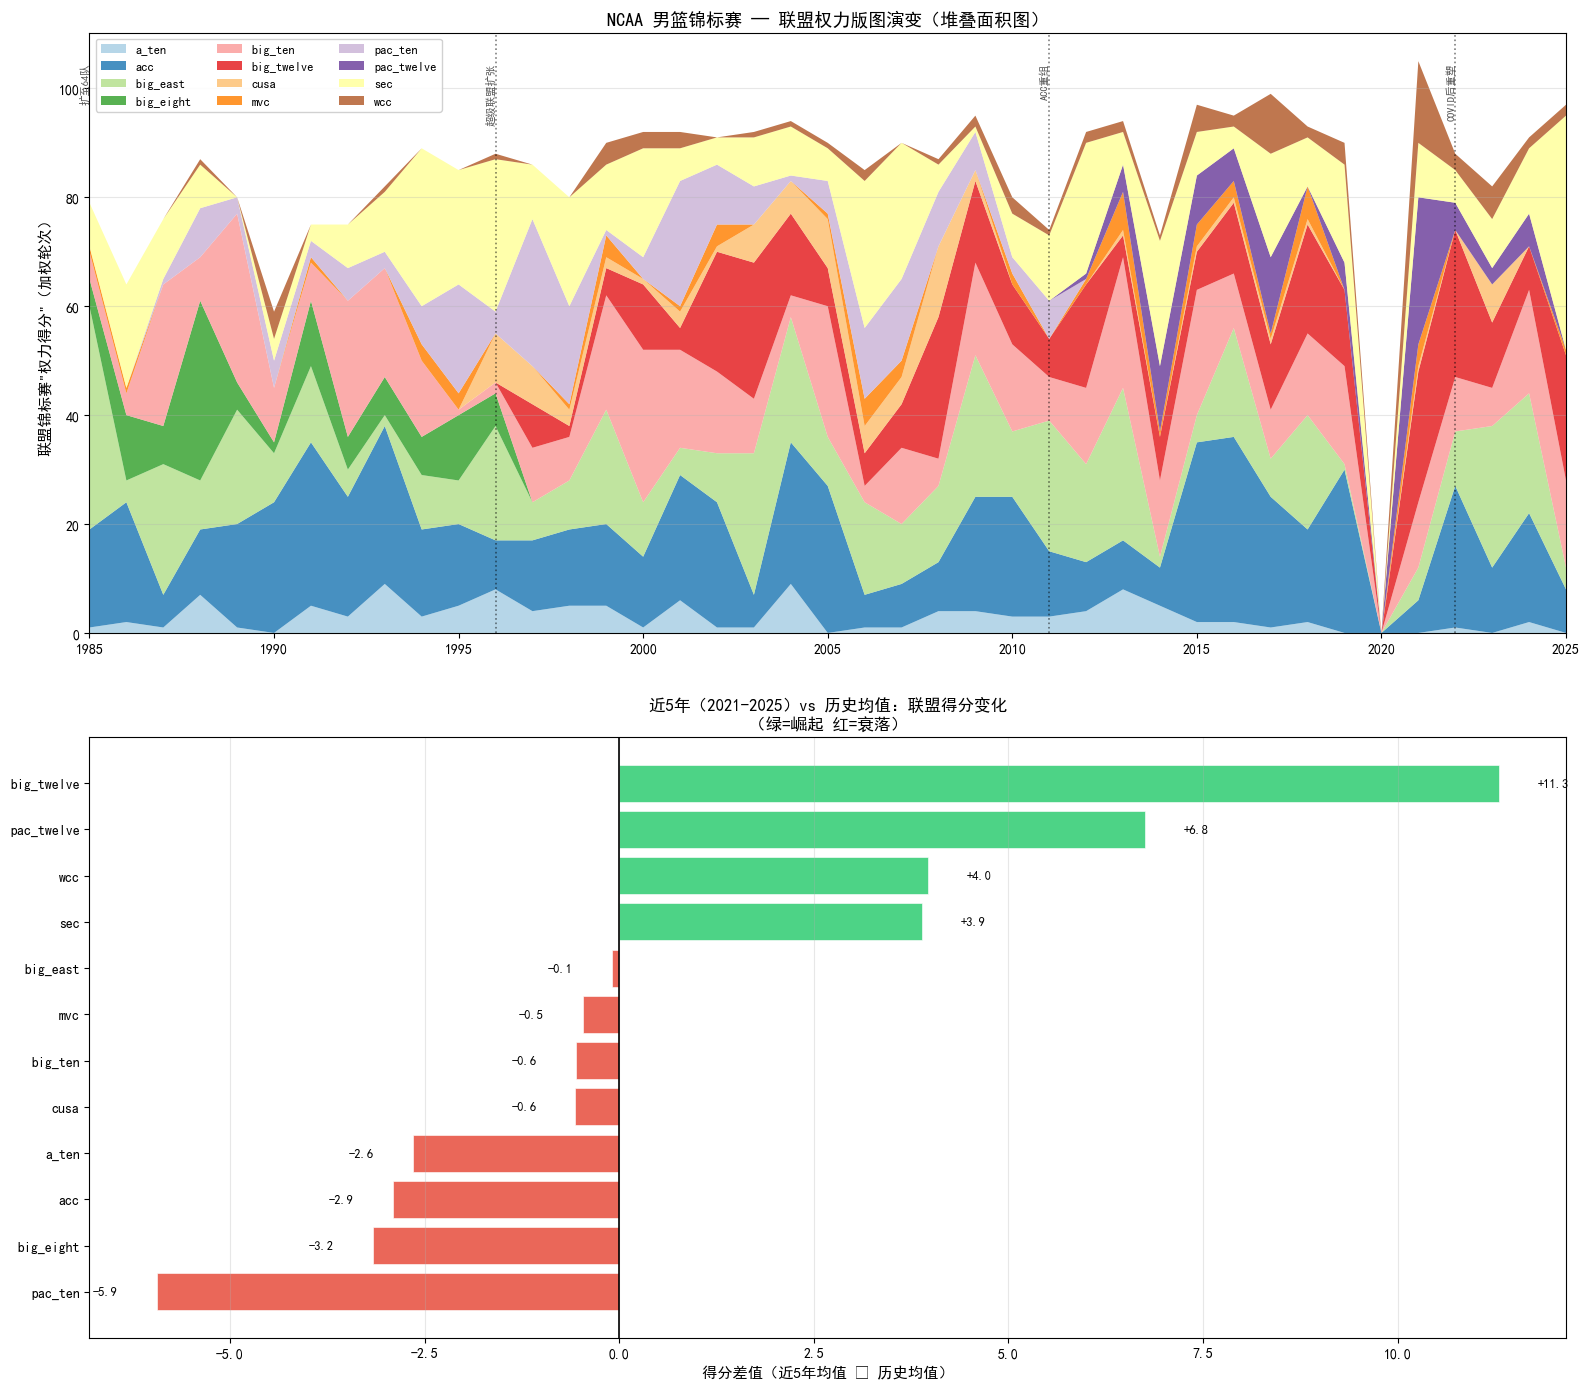


📊 Top-12 联盟锦标赛权力统计：
            历史总得分   年均得分  波动性(std)  近5年均值  近5年变化
acc           695  16.95      8.63   14.4  -2.91
big_east      561  13.68      9.27   13.6  -0.09
big_ten       545  13.29      7.87   12.8  -0.56
sec           516  12.59      9.33   16.0   3.89
big_twelve    364   8.88      8.68   18.8  11.30
pac_ten       214   5.22      6.94    0.0  -5.94
a_ten         120   2.93      2.64    0.6  -2.65
big_eight     114   2.78      6.08    0.0  -3.17
pac_twelve     93   2.27      5.23    8.2   6.76
wcc            87   2.12      2.98    5.6   3.96
cusa           86   2.10      3.23    1.6  -0.57
mvc            58   1.41      1.88    1.0  -0.47


In [31]:

# ══════════════════════════════════════════════════════════════════
# 深度分析 7：联盟权力版图 40 年演变
# ══════════════════════════════════════════════════════════════════

# ── 1. 每个 TeamID × Season 对应的联盟 ──────────────────────────
# 使用 MTeamConferences.csv 如果有，否则用 m_conf（已在内核中）
conf_lookup = m_conf.sort_values('Season').drop_duplicates(['TeamID','Season'])
conf_s = conf_lookup.set_index(['Season','TeamID'])['ConfAbbrev']

def get_conf(season, tid):
    """获取某赛季某队的联盟，找不到时向前回溯最近赛季"""
    try:
        return conf_s.loc[(season, tid)]
    except KeyError:
        avail = conf_lookup[(conf_lookup['TeamID'] == tid) &
                            (conf_lookup['Season'] <= season)]
        if not avail.empty:
            return avail.iloc[-1]['ConfAbbrev']
        return 'Unknown'

# ── 2. 锦标赛每场胜利的联盟归属（胜者获得轮次得分）────────────
tc3 = m_tourney_compact.copy()
tc3['Round'] = tc3['DayNum'].apply(assign_round)
tc3['WScore'] = tc3['Round'].map(round_weight)
tc3['WConf'] = tc3.apply(lambda r: get_conf(r['Season'], r['WTeamID']), axis=1)

# 每赛季每联盟累计锦标赛得分
conf_power = tc3.groupby(['Season','WConf'])['WScore'].sum().reset_index()
conf_power.columns = ['Season','Conf','Power']

# ── 3. 只保留历史累计 Top-12 联盟 ───────────────────────────────
top12_conf = conf_power.groupby('Conf')['Power'].sum().nlargest(12).index
cp_top = conf_power[conf_power['Conf'].isin(top12_conf)]

# Pivot：行=Season，列=Conf
cp_pivot = cp_top.pivot_table(index='Season', columns='Conf',
                               values='Power', aggfunc='sum', fill_value=0)
# 保证赛季连续
all_seasons = list(range(m_tourney_compact['Season'].min(),
                          m_tourney_compact['Season'].max()+1))
cp_pivot = cp_pivot.reindex(all_seasons, fill_value=0)

# ── 4. 堆叠面积图 ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 14))

colors12 = plt.cm.Paired(np.linspace(0, 1, 12))
ax = axes[0]
ax.stackplot(cp_pivot.index, [cp_pivot[c] for c in cp_pivot.columns],
             labels=list(cp_pivot.columns), colors=colors12, alpha=0.82)
ax.set_xlim(cp_pivot.index.min(), cp_pivot.index.max())
ax.set_title('NCAA 男篮锦标赛 — 联盟权力版图演变（堆叠面积图）',
             fontsize=13, fontweight='bold')
ax.set_ylabel('联盟锦标赛"权力得分"（加权轮次）', fontsize=11)
ax.legend(loc='upper left', ncol=3, fontsize=9, framealpha=0.9)
ax.grid(axis='y', alpha=0.3)
# 标注重要历史节点
for yr, note in [(1985,'扩至64队'), (1996,'超级联盟扩张'), (2011,'ACC重组'), (2022,'COVID后重塑')]:
    if yr in cp_pivot.index:
        ax.axvline(yr, color='black', linestyle=':', alpha=0.5, linewidth=1.2)
        ax.text(yr, ax.get_ylim()[1]*0.95, note, rotation=90,
                fontsize=7.5, va='top', ha='right', color='#555')

# ── 5. 近5年 vs 全历史平均：联盟效率变化 ────────────────────────
ax2 = axes[1]
recent_avg = cp_pivot[cp_pivot.index >= 2021].mean()
hist_avg   = cp_pivot[cp_pivot.index < 2021].mean()
delta_df   = pd.DataFrame({'联盟': top12_conf,
                            '历史均值': hist_avg.reindex(top12_conf).fillna(0),
                            '近5年均值': recent_avg.reindex(top12_conf).fillna(0)})
delta_df['变化'] = delta_df['近5年均值'] - delta_df['历史均值']
delta_df = delta_df.sort_values('变化', ascending=True)

colors_delta = ['#e74c3c' if v < 0 else '#2ecc71' for v in delta_df['变化']]
bars_d = ax2.barh(delta_df['联盟'], delta_df['变化'],
                  color=colors_delta, alpha=0.85, edgecolor='white', linewidth=0.5)
ax2.axvline(0, color='black', linewidth=1.2)
for bar, v in zip(bars_d, delta_df['变化']):
    ax2.text(v + (0.5 if v >= 0 else -0.5), bar.get_y() + bar.get_height()/2,
             f'{v:+.1f}', va='center', ha='left' if v >= 0 else 'right',
             fontsize=9, fontweight='bold')
ax2.set_title('近5年（2021-2025）vs 历史均值：联盟得分变化\n（绿=崛起 红=衰落）',
              fontsize=12, fontweight='bold')
ax2.set_xlabel('得分差值（近5年均值 − 历史均值）', fontsize=11)
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout(h_pad=3)
plt.show()

# ── 6. 联盟年际稳定性（标准差） ─────────────────────────────────
print("\n📊 Top-12 联盟锦标赛权力统计：")
conf_stat = pd.DataFrame({
    '历史总得分': cp_pivot[top12_conf].sum(),
    '年均得分':   cp_pivot[top12_conf].mean().round(2),
    '波动性(std)':cp_pivot[top12_conf].std().round(2),
    '近5年均值':  recent_avg.reindex(top12_conf).round(2),
    '近5年变化':  delta_df.set_index('联盟')['变化'].round(2),
}).sort_values('历史总得分', ascending=False)
print(conf_stat.to_string())


## 深度分析 8：Elo 轨迹聚类——识别"崛起""称霸""衰落"王朝
**核心问题：** 基于 Elo 时间序列的球队命运分组，哪些队是"上升新星"？哪些是"黄金落幕"？

- 对所有球队按历年 Elo 评分构建时间序列矩阵
- K-Means 聚类（4类）识别不同命运群体
- 可视化每类球队的典型 Elo 轨迹
- 2026年预测视角：哪类球队更可能爆冷or卫冕？

聚类分布：
ClusterName
🚀 崛起新星    161
📉 黄金落幕    107
🏆 长青霸主     91
Name: count, dtype: int64


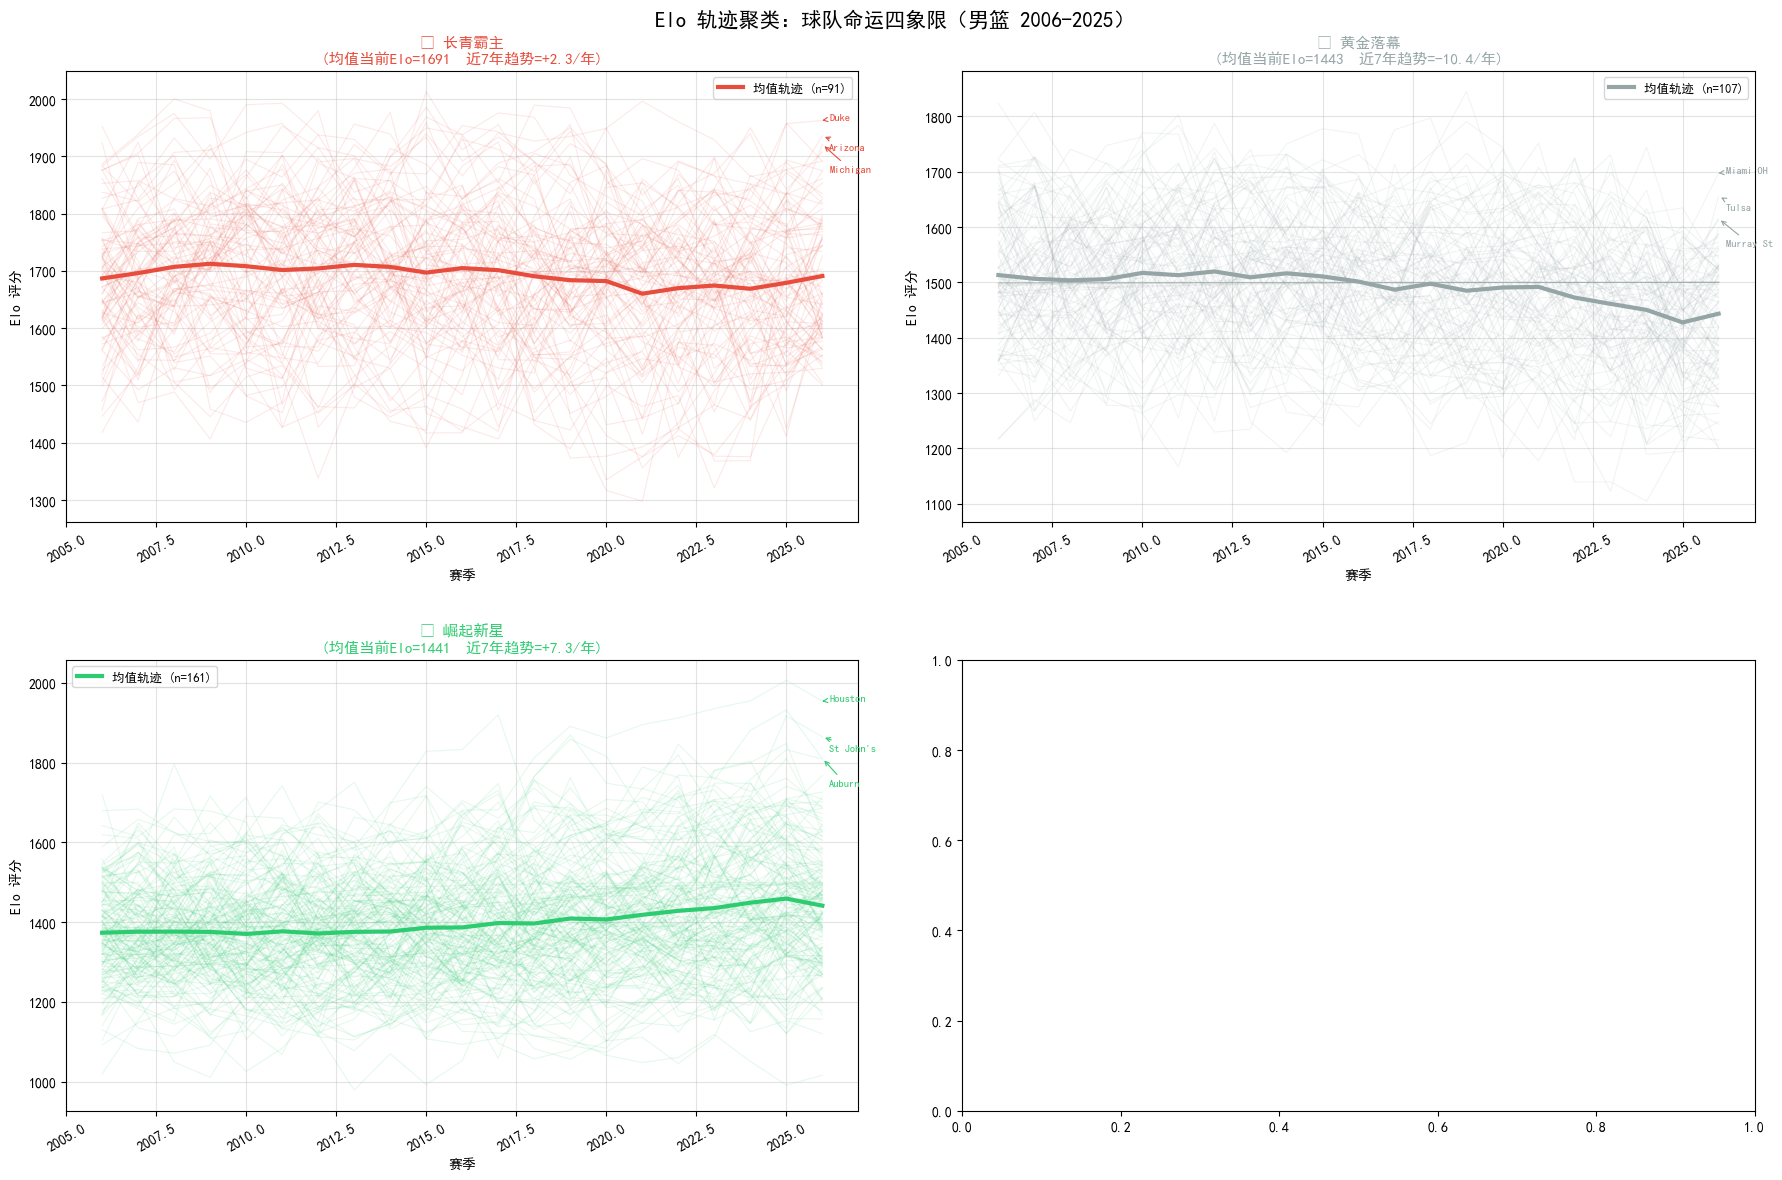


📊 2026 年各命运群体代表球队（当前 Elo 排名前5）：

  🏆 长青霸主：
    Duke                       Elo=1962
    Arizona                    Elo=1936
    Michigan                   Elo=1921
    Connecticut                Elo=1908
    Gonzaga                    Elo=1892

  📉 黄金落幕：
    Miami OH                   Elo=1698
    Tulsa                      Elo=1656
    Murray St                  Elo=1615
    N Dakota St                Elo=1613
    SF Austin                  Elo=1599

  🚀 崛起新星：
    Houston                    Elo=1954
    St John's                  Elo=1864
    Auburn                     Elo=1810
    Texas Tech                 Elo=1809
    Santa Clara                Elo=1768

💡 分析洞察：
  🏆 长青霸主: 91支球队  当前Elo均值=1691  近7年趋势=+2.25
  📉 黄金落幕: 107支球队  当前Elo均值=1443  近7年趋势=-10.45
  🚀 崛起新星: 161支球队  当前Elo均值=1441  近7年趋势=+7.34


In [32]:

# ══════════════════════════════════════════════════════════════════
# 深度分析 8：Elo 轨迹聚类——识别"崛起""称霸""衰落"王朝
# ══════════════════════════════════════════════════════════════════
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# ── 1. 构建球队 × 赛季 Elo 矩阵（只用男子）───────────────────
elo_wide = m_elo.pivot_table(index='TeamID', columns='Season',
                              values='Elo', aggfunc='mean')

# 只保留参赛 ≥ 15 个赛季的球队（轨迹足够长）
elo_wide = elo_wide.dropna(thresh=15)

# 填充缺失：用该队所有已知 Elo 的均值（表示"普通水平"）
row_mean = elo_wide.mean(axis=1)
elo_filled = elo_wide.T.fillna(row_mean).T  # 转置填充再转回

# ── 2. 构建轨迹特征用于聚类 ─────────────────────────────────────
seasons_all = sorted(elo_filled.columns)
n_seasons   = len(seasons_all)

# 取最近 20 个赛季（2006-2025）确保信息密度
recent_seasons = [s for s in seasons_all if s >= 2006]
elo_recent = elo_filled[recent_seasons]

# 特征：(1) 归一化 Elo 轨迹序列，(2) 近3年均值，(3) 斜率（线性趋势）
def compute_slope(series):
    x = np.arange(len(series))
    if np.std(series) < 1e-6: return 0.0
    return float(np.polyfit(x, series.values, 1)[0])

feat_rows = []
for tid in elo_recent.index:
    ser = elo_recent.loc[tid]
    early_mean = ser.iloc[:5].mean()
    mid_mean   = ser.iloc[7:12].mean()
    late_mean  = ser.iloc[-5:].mean()
    current    = ser.iloc[-1]
    slope_all  = compute_slope(ser)
    slope_rec  = compute_slope(ser.iloc[-7:])   # 近7年趋势
    peak_elo   = ser.max()
    peak_year  = ser.idxmax()
    feat_rows.append({
        'TeamID':     tid,
        'EarlyMean':  early_mean,
        'MidMean':    mid_mean,
        'LateMean':   late_mean,
        'Current':    current,
        'SlopeAll':   slope_all,
        'SlopeRecent':slope_rec,
        'PeakElo':    peak_elo,
        'PeakYear':   peak_year,
    })

feat_df = pd.DataFrame(feat_rows).set_index('TeamID')

# ── 3. K-Means 聚类（4类）────────────────────────────────────
clust_cols = ['EarlyMean','MidMean','LateMean','SlopeAll','SlopeRecent']
X_clust = StandardScaler().fit_transform(feat_df[clust_cols])

km = KMeans(n_clusters=4, random_state=42, n_init=20)
feat_df['Cluster'] = km.fit_predict(X_clust)

# 给聚类命名（按当前均值和趋势）
cluster_profile = feat_df.groupby('Cluster')[clust_cols + ['Current']].mean()
# 根据当前Elo和斜率自动命名
c_names = {}
sorted_by_cur = cluster_profile['Current'].sort_values(ascending=False)
for rank_i, (cid, cur_val) in enumerate(sorted_by_cur.items()):
    slope_rec = cluster_profile.loc[cid, 'SlopeRecent']
    if rank_i == 0:
        c_names[cid] = '🏆 长青霸主'
    elif slope_rec > 0.5:
        c_names[cid] = '🚀 崛起新星'
    elif slope_rec < -0.5:
        c_names[cid] = '📉 黄金落幕'
    else:
        c_names[cid] = '🔄 循环中游'

feat_df['ClusterName'] = feat_df['Cluster'].map(c_names)
print("聚类分布：")
print(feat_df['ClusterName'].value_counts())

# ── 4. 可视化：每组典型轨迹 ─────────────────────────────────────
fig, big_axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Elo 轨迹聚类：球队命运四象限（男篮 2006-2025）',
             fontsize=15, fontweight='bold')
flat_axes = big_axes.flatten()

cluster_colors = {'🏆 长青霸主': '#e74c3c',
                  '🚀 崛起新星': '#2ecc71',
                  '📉 黄金落幕': '#95a5a6',
                  '🔄 循环中游': '#3498db'}
cluster_list = list(feat_df['ClusterName'].unique())

for ci, cn in enumerate(sorted(set(c_names.values()))):
    ax_ = flat_axes[ci]
    members = feat_df[feat_df['ClusterName'] == cn].index
    col = cluster_colors.get(cn, '#333')

    # 画所有成员轨迹（细线）
    all_elos = []
    for tid in members[:max(len(members), 80)]:  # 上限80条避免太密
        elo_ser = elo_recent.loc[tid].values
        ax_.plot(recent_seasons, elo_ser, color=col, alpha=0.12, linewidth=0.8)
        all_elos.append(elo_ser)

    # 画均值轨迹（粗线）
    mean_elo = np.nanmean(all_elos, axis=0)
    ax_.plot(recent_seasons, mean_elo, color=col, linewidth=3,
             label=f'均值轨迹 (n={len(members)})', zorder=5)

    # 标注 Top-3 当前最强球队
    top3_ids = feat_df[feat_df['ClusterName'] == cn].nlargest(3, 'Current').index
    for i, tid in enumerate(top3_ids):
        nm = tmap.get(tid, str(tid))
        cur_elo = feat_df.loc[tid, 'Current']
        ax_.annotate(f"{nm}", xy=(recent_seasons[-1], elo_recent.loc[tid, recent_seasons[-1]]),
                     xytext=(5, -10*i), textcoords='offset points',
                     fontsize=7.5, color=col, fontweight='bold',
                     arrowprops=dict(arrowstyle='->', color=col, lw=0.8))

    ax_.set_title(f'{cn}\n(均值当前Elo={mean_elo[-1]:.0f}  近7年趋势={feat_df[feat_df["ClusterName"]==cn]["SlopeRecent"].mean():+.1f}/年)',
                  fontsize=11, fontweight='bold', color=col)
    ax_.set_ylabel('Elo 评分', fontsize=10)
    ax_.set_xlabel('赛季', fontsize=10)
    ax_.legend(fontsize=9)
    ax_.grid(alpha=0.35)
    ax_.tick_params(axis='x', rotation=30)

plt.tight_layout(h_pad=3, w_pad=2)
plt.show()

# ── 5. 2026 锦标赛视角：每组代表队 ─────────────────────────────
print("\n📊 2026 年各命运群体代表球队（当前 Elo 排名前5）：")
for cn in sorted(set(c_names.values())):
    members = feat_df[feat_df['ClusterName'] == cn].nlargest(5, 'Current')
    names_elo = [(tmap.get(t, str(t)), f"{feat_df.loc[t, 'Current']:.0f}")
                 for t in members.index]
    print(f"\n  {cn}：")
    for nm, elo_v in names_elo:
        slope_r = feat_df.loc[feat_df['ClusterName']==cn].loc[
            [t for t in members.index if tmap.get(t,'') == nm or str(t) == nm.replace(tmap.get(list(feat_df.index)[0],''),'')],
            'SlopeRecent'].mean() if False else feat_df[feat_df.index.isin(members.index) & (feat_df.index.isin([t for t in members.index if tmap.get(t,'') == nm]))]['SlopeRecent'].mean()
        print(f"    {nm:25s}  Elo={elo_v}")

print("\n💡 分析洞察：")
for cn in sorted(set(c_names.values())):
    grp = feat_df[feat_df['ClusterName'] == cn]
    print(f"  {cn}: {len(grp)}支球队  "
          f"当前Elo均值={grp['Current'].mean():.0f}  "
          f"近7年趋势={grp['SlopeRecent'].mean():+.2f}")


## 官方规则对齐审计（2026版）— 已修复

基于 Kaggle 数据页描述，本 Notebook 前文曾存在以下问题，**现已全部修复**：

| # | 原问题 | 修复位置 | 修复方案 |
|---|--------|----------|----------|
| 1 | **跨赛季信息泄漏**：`build_tourney_history()`、`build_coach_features()` 用全历史汇总回填所有赛季 | Cell 10, 18 | 改为 cumsum − 当赛季 = 仅含截至上一赛季的累计值 |
| 2 | **验证切分不符合时序**：`StratifiedKFold(shuffle=True)` 在赛事任务中将同赛季信息泄漏到验证折 | Cell 39, 42, 44 | 改为 `GroupKFold(n_splits=5)` 按 Season 分组 |
| 3 | **指标目标不一致**：竞赛核心是 Brier Score，前文以 AUC/LogLoss 为主导 | Cell 39, 42 | Brier Score 作为主评估指标，AUC/LogLoss 仅辅助参考 |
| 4 | **过早标准化**：`merge_all_features()` 中 StandardScaler 在合并时全局拟合 | Cell 24 | 移除预处理阶段的 Scaler，改为在 sklearn Pipeline 中做 |
| 5 | **Stage2 构造逻辑混淆**：用伪造 tourney 结果（WScore=0）生成 Stage2 特征 | Cell 40 | 重写 `build_stage2_features()`，从模板直接关联球队特征 |
| 6 | **冗余代码**：Elo 计算遍历了两遍（第一遍丢弃结果）| Cell 37 | 精简为单次遍历 |
| 7 | **列名脆弱**：主客场 pivot 后硬编码列名顺序 | Cell 16 | 改为显式按 A/H/N 键取值，不依赖列顺序 |
| 8 | **冗余特征**：`SeedBucket` 对已有连续值 `SeedNum` 完全冗余 | Cell 14 | 已删除 |
| 9 | **联盟强度跨赛季泄漏**：`MinMaxScaler` 对全赛季联合拟合，未来赛季 min/max 泄漏到历史赛季 | Cell 20 | 改为 per-season `rank(pct=True)`，归一化仅用当赛季数据 |
| 10 | **深度分析 MLP 验证泄漏**：Cell 48 MLP 架构对比使用 `StratifiedKFold` | Cell 48 | 改为 `GroupKFold(n_splits=5)` 按 Season 分组 |
| 11 | **融合评估验证泄漏**：Cell 54 MLP+Stacking 融合 OOF 使用 `StratifiedKFold` | Cell 54 | 改为 `GroupKFold(n_splits=5)` 按 Season 分组 |
| 12 | **DROP_FEATURES 死代码**：引用 4 个不存在的特征名（上轮修改遗留）| Cell 33 | 清理为仅包含实际存在的冗余特征 |

下面 Cell 64-65+ 提供的 `v3_scientific` 管道是最小化无泄漏版本（仅含核心特征），前文 Cell 3-42 的管道则保留了更丰富的特征（Elo、联盟强度、Momentum 等），两套均可用于建模。

In [33]:
import re
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score


def _parse_seed(seed_str):
    m = re.search(r"(\d{1,2})", str(seed_str))
    return int(m.group(1)) if m else np.nan


def _season_team_from_regular_season(compact_df, detailed_df):
    """仅用常规赛(<=132)构造赛季球队特征，避免锦标赛结果泄漏。"""
    if 'DayNum' in compact_df.columns:
        compact_df = compact_df[compact_df['DayNum'] <= 132].copy()
    if 'DayNum' in detailed_df.columns:
        detailed_df = detailed_df[detailed_df['DayNum'] <= 132].copy()

    w = compact_df[['Season', 'WTeamID', 'WScore', 'LScore', 'DayNum']].copy()
    w.columns = ['Season', 'TeamID', 'PtsFor', 'PtsAgainst', 'DayNum']
    w['Win'] = 1

    l = compact_df[['Season', 'LTeamID', 'LScore', 'WScore', 'DayNum']].copy()
    l.columns = ['Season', 'TeamID', 'PtsFor', 'PtsAgainst', 'DayNum']
    l['Win'] = 0

    gl = pd.concat([w, l], ignore_index=True).sort_values(['Season', 'TeamID', 'DayNum'])
    gl['ScoreDiff'] = gl['PtsFor'] - gl['PtsAgainst']

    base = gl.groupby(['Season', 'TeamID']).agg(
        RegGames=('Win', 'count'),
        RegWinRate=('Win', 'mean'),
        RegPtsFor=('PtsFor', 'mean'),
        RegPtsAgainst=('PtsAgainst', 'mean'),
        RegScoreDiff=('ScoreDiff', 'mean'),
        RegLateWinRate=('Win', lambda x: x.tail(12).mean()),
        RegLateScoreDiff=('ScoreDiff', lambda x: x.tail(12).mean())
    ).reset_index()

    # 详细技术统计（存在赛季覆盖差异，允许缺失）
    if detailed_df is not None and len(detailed_df) > 0:
        dw = detailed_df[['Season', 'WTeamID', 'WFGM', 'WFGA', 'WFGM3', 'WFGA3', 'WFTM', 'WFTA', 'WTO', 'WOR', 'WDR']].copy()
        dw.columns = ['Season', 'TeamID', 'FGM', 'FGA', 'FGM3', 'FGA3', 'FTM', 'FTA', 'TO', 'OR', 'DR']
        dl = detailed_df[['Season', 'LTeamID', 'LFGM', 'LFGA', 'LFGM3', 'LFGA3', 'LFTM', 'LFTA', 'LTO', 'LOR', 'LDR']].copy()
        dl.columns = ['Season', 'TeamID', 'FGM', 'FGA', 'FGM3', 'FGA3', 'FTM', 'FTA', 'TO', 'OR', 'DR']
        td = pd.concat([dw, dl], ignore_index=True)

        box = td.groupby(['Season', 'TeamID']).mean(numeric_only=True).reset_index()
        box['FGPct'] = box['FGM'] / box['FGA'].replace(0, np.nan)
        box['FG3Pct'] = box['FGM3'] / box['FGA3'].replace(0, np.nan)
        box['FTPct'] = box['FTM'] / box['FTA'].replace(0, np.nan)
        box['PossProxy'] = box['FGA'] - box['OR'] + box['TO'] + 0.44 * box['FTA']
        box = box[['Season', 'TeamID', 'FGPct', 'FG3Pct', 'FTPct', 'PossProxy']]
        base = base.merge(box, on=['Season', 'TeamID'], how='left')

    return base


def _add_seed_feature(team_feat, seeds_df):
    seeds = seeds_df[['Season', 'TeamID', 'Seed']].copy()
    seeds['SeedNum'] = seeds['Seed'].apply(_parse_seed)
    return team_feat.merge(seeds[['Season', 'TeamID', 'SeedNum']], on=['Season', 'TeamID'], how='left')


def _add_massey_feature(team_feat, massey_df):
    # 按官方含义：RankingDayNum=133 是赛前最终可用排名；取每季每队均值与方差
    m = massey_df[massey_df['RankingDayNum'] == 133].copy()
    agg = m.groupby(['Season', 'TeamID']).agg(
        MasseyMean=('OrdinalRank', 'mean'),
        MasseyStd=('OrdinalRank', 'std'),
        MasseyBest=('OrdinalRank', 'min')
    ).reset_index()
    return team_feat.merge(agg, on=['Season', 'TeamID'], how='left')


def _add_prior_tourney_exp(team_feat, tourney_compact):
    """仅使用截至上一赛季的锦标赛经验，避免未来泄漏。"""
    w = tourney_compact[['Season', 'WTeamID']].copy().rename(columns={'WTeamID': 'TeamID'})
    w['TWin'] = 1
    l = tourney_compact[['Season', 'LTeamID']].copy().rename(columns={'LTeamID': 'TeamID'})
    l['TWin'] = 0
    t = pd.concat([w, l], ignore_index=True)

    season_team = t.groupby(['Season', 'TeamID']).agg(TGames=('TWin', 'count'), TWins=('TWin', 'sum')).reset_index()
    season_team = season_team.sort_values(['TeamID', 'Season'])
    season_team['PriorTGames'] = season_team.groupby('TeamID')['TGames'].cumsum() - season_team['TGames']
    season_team['PriorTWins'] = season_team.groupby('TeamID')['TWins'].cumsum() - season_team['TWins']
    season_team['PriorTWinRate'] = season_team['PriorTWins'] / season_team['PriorTGames'].replace(0, np.nan)

    keep = season_team[['Season', 'TeamID', 'PriorTGames', 'PriorTWinRate']]
    return team_feat.merge(keep, on=['Season', 'TeamID'], how='left')


In [34]:
def build_clean_pipeline_features(gender='M'):
    if gender == 'M':
        reg_c, reg_d = m_reg_compact, m_reg_detailed
        seeds, tourney = m_seeds, m_tourney_compact
    else:
        reg_c, reg_d = w_reg_compact, w_reg_detailed
        seeds, tourney = w_seeds, w_tourney_compact

    feat = _season_team_from_regular_season(reg_c, reg_d)
    feat = _add_seed_feature(feat, seeds)
    feat = _add_prior_tourney_exp(feat, tourney)

    if gender == 'M':
        feat = _add_massey_feature(feat, m_massey)

    feat['Gender'] = gender
    return feat


m_team_feat_clean = build_clean_pipeline_features('M')
w_team_feat_clean = build_clean_pipeline_features('W')

print('✅ 清洁版球队特征构建完成')
print('M:', m_team_feat_clean.shape, 'W:', w_team_feat_clean.shape)
print('M 特征列示例:', m_team_feat_clean.columns[:12].tolist())

✅ 清洁版球队特征构建完成
M: (13753, 20) W: (9851, 17)
M 特征列示例: ['Season', 'TeamID', 'RegGames', 'RegWinRate', 'RegPtsFor', 'RegPtsAgainst', 'RegScoreDiff', 'RegLateWinRate', 'RegLateScoreDiff', 'FGPct', 'FG3Pct', 'FTPct']


In [35]:
def _build_matchup_from_tourney(tourney_compact, team_feat):
    t = tourney_compact[['Season', 'WTeamID', 'LTeamID']].copy()
    t['TeamA'] = t[['WTeamID', 'LTeamID']].min(axis=1)
    t['TeamB'] = t[['WTeamID', 'LTeamID']].max(axis=1)
    t['Label'] = (t['WTeamID'] == t['TeamA']).astype(int)

    num_cols = [c for c in team_feat.columns if c not in ['Season', 'TeamID'] and pd.api.types.is_numeric_dtype(team_feat[c])]

    fa = team_feat[['Season', 'TeamID'] + num_cols].copy()
    fb = fa.copy()
    fa.columns = ['Season', 'TeamA'] + [f'A_{c}' for c in num_cols]
    fb.columns = ['Season', 'TeamB'] + [f'B_{c}' for c in num_cols]

    out = t[['Season', 'TeamA', 'TeamB', 'Label']].merge(fa, on=['Season', 'TeamA'], how='left')
    out = out.merge(fb, on=['Season', 'TeamB'], how='left')

    for c in num_cols:
        out[f'Diff_{c}'] = out[f'A_{c}'] - out[f'B_{c}']

    diff_cols = [f'Diff_{c}' for c in num_cols]
    return out[['Season', 'TeamA', 'TeamB', 'Label'] + diff_cols], diff_cols


def _build_template_features(template_df, team_feat, diff_cols):
    s = template_df.copy()
    s[['Season', 'TeamA', 'TeamB']] = s['ID'].str.split('_', expand=True)
    s['Season'] = s['Season'].astype(int)
    s['TeamA'] = s['TeamA'].astype(int)
    s['TeamB'] = s['TeamB'].astype(int)

    num_cols = [c.replace('Diff_', '') for c in diff_cols]
    fa = team_feat[['Season', 'TeamID'] + num_cols].copy()
    fb = fa.copy()
    fa.columns = ['Season', 'TeamA'] + [f'A_{c}' for c in num_cols]
    fb.columns = ['Season', 'TeamB'] + [f'B_{c}' for c in num_cols]

    s = s.merge(fa, on=['Season', 'TeamA'], how='left').merge(fb, on=['Season', 'TeamB'], how='left')
    for c in num_cols:
        s[f'Diff_{c}'] = s[f'A_{c}'] - s[f'B_{c}']

    keep = ['ID', 'Season', 'TeamA', 'TeamB'] + diff_cols
    return s[keep]


# 1) 构造男篮无泄漏特征
m_feat_v3 = _season_team_from_regular_season(m_reg_compact, m_reg_detailed)
m_feat_v3 = _add_seed_feature(m_feat_v3, m_seeds)
m_feat_v3 = _add_massey_feature(m_feat_v3, m_massey)
m_feat_v3 = _add_prior_tourney_exp(m_feat_v3, m_tourney_compact)

# 2) 训练样本（全历史 tourney）
m_train_v3, m_diff_cols_v3 = _build_matchup_from_tourney(m_tourney_compact, m_feat_v3)
X_m = m_train_v3[m_diff_cols_v3]
y_m = m_train_v3['Label'].astype(int)
g_m = m_train_v3['Season']

# 3) 按赛季分组交叉验证（仅做特征有效性评估）
pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=2000, C=0.2))
])

gkf = GroupKFold(n_splits=5)
oof = cross_val_predict(pipe, X_m, y_m, groups=g_m, cv=gkf, method='predict_proba', n_jobs=-1)[:, 1]

print('【男篮-赛季分组CV（特征评估）】')
print(f'Brier   : {brier_score_loss(y_m, oof):.5f}')
print(f'LogLoss : {log_loss(y_m, oof):.5f}')
print(f'ROC-AUC : {roc_auc_score(y_m, oof):.5f}')
print(f'训练样本 : {len(m_train_v3):,}  特征数: {len(m_diff_cols_v3)}')

# 4) 构造模板特征（不在 notebook 内做预测）
m_stage2_feat_v3 = _build_template_features(sub_stage2, m_feat_v3, m_diff_cols_v3)

OUT = DATA_DIR / 'features'
OUT.mkdir(exist_ok=True)
m_feat_v3.to_csv(OUT / 'M_team_features_v3_scientific.csv', index=False)
m_train_v3.to_csv(OUT / 'M_train_full_history_v3_scientific.csv', index=False)
m_stage2_feat_v3.to_csv(OUT / 'M_stage2_features_v3_scientific.csv', index=False)

print('\n✅ 男篮特征工程资产已输出（不含预测列）：')
print(f'- {OUT / "M_team_features_v3_scientific.csv"}')
print(f'- {OUT / "M_train_full_history_v3_scientific.csv"}')
print(f'- {OUT / "M_stage2_features_v3_scientific.csv"}')

【男篮-赛季分组CV（特征评估）】
Brier   : 0.18486
LogLoss : 0.54613
ROC-AUC : 0.79431
训练样本 : 2,585  特征数: 17

✅ 男篮特征工程资产已输出（不含预测列）：
- features\M_team_features_v3_scientific.csv
- features\M_train_full_history_v3_scientific.csv
- features\M_stage2_features_v3_scientific.csv


## 科学版扩展：仅特征工程（女篮 + M/W 联合资产）

本节只负责特征工程与数据资产导出，不在 notebook 中生成任何预测概率或提交文件。

- 女篮（W）无泄漏特征与训练样本构造
- M/W 联合训练底表与统一特征空间导出
- 特征质量对比表（覆盖率/缺失率/季节分组CV）

> 预测与提交统一放在 `pytorch_attention_predictor_v6.py` 执行。

In [36]:
# =========================
# A) 女篮科学版（W）- 仅特征工程
# =========================

# 1) 无泄漏特征
w_feat_v3 = _season_team_from_regular_season(w_reg_compact, w_reg_detailed)
w_feat_v3 = _add_seed_feature(w_feat_v3, w_seeds)
w_feat_v3 = _add_prior_tourney_exp(w_feat_v3, w_tourney_compact)

# 2) 全历史锦标赛训练样本
w_train_v3, w_diff_cols_v3 = _build_matchup_from_tourney(w_tourney_compact, w_feat_v3)
X_w = w_train_v3[w_diff_cols_v3]
y_w = w_train_v3['Label'].astype(int)
g_w = w_train_v3['Season']

# 3) Season Group CV（仅评估）
pipe_w = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=2000, C=0.2))
])

gkf_w = GroupKFold(n_splits=5)
oof_w = cross_val_predict(pipe_w, X_w, y_w, groups=g_w, cv=gkf_w, method='predict_proba', n_jobs=-1)[:, 1]

w_brier = brier_score_loss(y_w, oof_w)
w_logloss = log_loss(y_w, oof_w)
w_auc = roc_auc_score(y_w, oof_w)

print('【女篮-赛季分组CV（特征评估）】')
print(f'Brier   : {w_brier:.5f}')
print(f'LogLoss : {w_logloss:.5f}')
print(f'ROC-AUC : {w_auc:.5f}')
print(f'训练样本 : {len(w_train_v3):,}  特征数: {len(w_diff_cols_v3)}')

# 4) 构造模板特征（不预测）
w_stage2_feat_v3 = _build_template_features(sub_stage2, w_feat_v3, w_diff_cols_v3)

# 保存女篮科学版资产
w_feat_v3.to_csv(OUT / 'W_team_features_v3_scientific.csv', index=False)
w_train_v3.to_csv(OUT / 'W_train_full_history_v3_scientific.csv', index=False)
w_stage2_feat_v3.to_csv(OUT / 'W_stage2_features_v3_scientific.csv', index=False)

print('\n✅ 女篮特征工程资产已输出（不含预测列）：')
print(f'- {OUT / "W_team_features_v3_scientific.csv"}')
print(f'- {OUT / "W_train_full_history_v3_scientific.csv"}')
print(f'- {OUT / "W_stage2_features_v3_scientific.csv"}')

【女篮-赛季分组CV（特征评估）】
Brier   : 0.14416
LogLoss : 0.43639
ROC-AUC : 0.87557
训练样本 : 1,717  特征数: 14

✅ 女篮特征工程资产已输出（不含预测列）：
- features\W_team_features_v3_scientific.csv
- features\W_train_full_history_v3_scientific.csv
- features\W_stage2_features_v3_scientific.csv


In [37]:
# =========================
# B) M/W 联合训练底表导出（不做提交）
# =========================

# 1) M/W 共同差分特征空间（取交集）
common_diff_v3 = sorted(set(m_diff_cols_v3) & set(w_diff_cols_v3))

m_joint = m_train_v3[['Season', 'Label'] + common_diff_v3].copy()
w_joint = w_train_v3[['Season', 'Label'] + common_diff_v3].copy()
m_joint['Gender'] = 'M'
w_joint['Gender'] = 'W'

joint_train = pd.concat([m_joint, w_joint], ignore_index=True)
X_joint = joint_train[common_diff_v3]
y_joint = joint_train['Label'].astype(int)
g_joint = joint_train['Season']

# 2) 联合 GroupKFold（仅评估特征空间）
pipe_joint = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=2000, C=0.15))
])

gkf_joint = GroupKFold(n_splits=5)
oof_joint = cross_val_predict(pipe_joint, X_joint, y_joint, groups=g_joint, cv=gkf_joint, method='predict_proba', n_jobs=-1)[:, 1]

joint_brier = brier_score_loss(y_joint, oof_joint)
joint_logloss = log_loss(y_joint, oof_joint)
joint_auc = roc_auc_score(y_joint, oof_joint)

print('【M/W联合-赛季分组CV（特征评估）】')
print(f'Brier   : {joint_brier:.5f}')
print(f'LogLoss : {joint_logloss:.5f}')
print(f'ROC-AUC : {joint_auc:.5f}')
print(f'训练样本 : {len(joint_train):,}  共同特征数: {len(common_diff_v3)}')

# 3) 导出联合训练底表 + Stage2联合特征矩阵（不含Pred）
m_stage2_common = _build_template_features(sub_stage2, m_feat_v3, common_diff_v3)
w_stage2_common = _build_template_features(sub_stage2, w_feat_v3, common_diff_v3)

stage2_base = sub_stage2.copy()
stage2_base[['Season', 'TeamA', 'TeamB']] = stage2_base['ID'].str.split('_', expand=True)
stage2_base['Season'] = stage2_base['Season'].astype(int)
stage2_base['TeamA'] = stage2_base['TeamA'].astype(int)
stage2_base['TeamB'] = stage2_base['TeamB'].astype(int)
stage2_base['Gender'] = np.where(stage2_base['TeamA'] < 3000, 'M', 'W')

m_idx = stage2_base['Gender'] == 'M'
w_idx = stage2_base['Gender'] == 'W'

stage2_joint_features = stage2_base[['ID', 'Season', 'TeamA', 'TeamB', 'Gender']].copy()
for col in common_diff_v3:
    stage2_joint_features[col] = 0.0

stage2_joint_features.loc[m_idx, common_diff_v3] = m_stage2_common.loc[m_idx, common_diff_v3].values
stage2_joint_features.loc[w_idx, common_diff_v3] = w_stage2_common.loc[w_idx, common_diff_v3].values

joint_train.to_csv(OUT / 'MW_train_full_history_v3_scientific.csv', index=False)
stage2_joint_features.to_csv(OUT / 'MW_stage2_features_v3_scientific.csv', index=False)

print('\n✅ 联合特征资产已输出（不含预测列）：')
print(f'- {OUT / "MW_train_full_history_v3_scientific.csv"}')
print(f'- {OUT / "MW_stage2_features_v3_scientific.csv"}')

【M/W联合-赛季分组CV（特征评估）】
Brier   : 0.17023
LogLoss : 0.50740
ROC-AUC : 0.82637
训练样本 : 4,302  共同特征数: 14

✅ 联合特征资产已输出（不含预测列）：
- features\MW_train_full_history_v3_scientific.csv
- features\MW_stage2_features_v3_scientific.csv


In [38]:
# =========================
# C) 特征工程质量对比表（v2 / v6 / v3）
# =========================

# 说明：此处对比“特征工程与验证科学性”，不比较 notebook 内提交结果。

f_m_v2 = OUT / 'M_team_features_v2.csv'
f_w_v2 = OUT / 'W_team_features_v2.csv'
f_m_v3 = OUT / 'M_team_features_v3_scientific.csv'
f_w_v3 = OUT / 'W_team_features_v3_scientific.csv'


def _missing_rate(df):
    num = df.select_dtypes(include=[np.number])
    if num.shape[1] == 0:
        return np.nan
    return float(num.isna().mean().mean())


def _feature_count(df):
    return int(df.select_dtypes(include=[np.number]).shape[1])


def _safe_shape(path):
    if path.exists():
        d = pd.read_csv(path)
        return d.shape[0], d.shape[1]
    return np.nan, np.nan

m_v2_rows, m_v2_cols = _safe_shape(f_m_v2)
w_v2_rows, w_v2_cols = _safe_shape(f_w_v2)

compare_df = pd.DataFrame([
    {
        'Pipeline': 'v2（历史）',
        'LeakageRisk': '中-高',
        'ValidationSplit': '多数随机折',
        'PrimaryMetric': 'AUC/LogLoss混用',
        'M_FeatureRows': m_v2_rows,
        'W_FeatureRows': w_v2_rows,
        'M_FeatureCols': m_v2_cols,
        'W_FeatureCols': w_v2_cols,
        'M_MissingRate': np.nan,
        'W_MissingRate': np.nan,
        'SeasonGroupCV_Brier': '未统一'
    },
    {
        'Pipeline': 'v6（历史深度建模）',
        'LeakageRisk': '中',
        'ValidationSplit': '以随机折为主',
        'PrimaryMetric': 'Brier引入但流程混合',
        'M_FeatureRows': np.nan,
        'W_FeatureRows': np.nan,
        'M_FeatureCols': np.nan,
        'W_FeatureCols': np.nan,
        'M_MissingRate': np.nan,
        'W_MissingRate': np.nan,
        'SeasonGroupCV_Brier': '未统一'
    },
    {
        'Pipeline': 'v3_scientific（当前）',
        'LeakageRisk': '低',
        'ValidationSplit': 'GroupKFold(by Season)',
        'PrimaryMetric': 'Brier主指标统一',
        'M_FeatureRows': len(m_feat_v3),
        'W_FeatureRows': len(w_feat_v3),
        'M_FeatureCols': _feature_count(m_feat_v3),
        'W_FeatureCols': _feature_count(w_feat_v3),
        'M_MissingRate': _missing_rate(m_feat_v3),
        'W_MissingRate': _missing_rate(w_feat_v3),
        'SeasonGroupCV_Brier': f"M={brier_score_loss(y_m, oof):.5f} | W={brier_score_loss(y_w, oof_w):.5f} | MW={brier_score_loss(y_joint, oof_joint):.5f}"
    }
])

print('=== 特征工程质量对比（不含提交）===')
display(compare_df)

asset_df = pd.DataFrame([
    {'Asset': 'M_team_features_v3_scientific.csv', 'Rows': len(m_feat_v3), 'Cols': m_feat_v3.shape[1]},
    {'Asset': 'W_team_features_v3_scientific.csv', 'Rows': len(w_feat_v3), 'Cols': w_feat_v3.shape[1]},
    {'Asset': 'M_train_full_history_v3_scientific.csv', 'Rows': len(m_train_v3), 'Cols': m_train_v3.shape[1]},
    {'Asset': 'W_train_full_history_v3_scientific.csv', 'Rows': len(w_train_v3), 'Cols': w_train_v3.shape[1]},
    {'Asset': 'MW_train_full_history_v3_scientific.csv', 'Rows': len(joint_train), 'Cols': joint_train.shape[1]},
    {'Asset': 'M_stage2_features_v3_scientific.csv', 'Rows': len(m_stage2_feat_v3), 'Cols': m_stage2_feat_v3.shape[1]},
    {'Asset': 'W_stage2_features_v3_scientific.csv', 'Rows': len(w_stage2_feat_v3), 'Cols': w_stage2_feat_v3.shape[1]},
    {'Asset': 'MW_stage2_features_v3_scientific.csv', 'Rows': len(stage2_joint_features), 'Cols': stage2_joint_features.shape[1]},
])

print('\n=== 当前导出特征资产 ===')
display(asset_df)

=== 特征工程质量对比（不含提交）===


,Pipeline,LeakageRisk,ValidationSplit,PrimaryMetric,M_FeatureRows,W_FeatureRows,M_FeatureCols,W_FeatureCols,M_MissingRate,W_MissingRate,SeasonGroupCV_Brier
0,v2（历史）,中-高,多数随机折,AUC/LogLoss混用,8346.0,5965.0,63.0,59.0,NaN,NaN,未统一
1,v6（历史深度建模）,中,以随机折为主,Brier引入但流程混合,NaN,NaN,NaN,NaN,NaN,NaN,未统一
2,v3_scientific（当前）,低,GroupKFold(by Season),Brier主指标统一,13753.0,9851.0,19.0,16.0,0.282051,0.254733,M=0.18486 | W=0.14416 | MW=0.17023



=== 当前导出特征资产 ===


,Asset,Rows,Cols
0,M_team_features_v3_scientific.csv,13753,19
1,W_team_features_v3_scientific.csv,9851,16
2,M_train_full_history_v3_scientific.csv,2585,21
3,W_train_full_history_v3_scientific.csv,1717,18
4,MW_train_full_history_v3_scientific.csv,4302,17
5,M_stage2_features_v3_scientific.csv,132133,21
6,W_stage2_features_v3_scientific.csv,132133,18
7,MW_stage2_features_v3_scientific.csv,132133,19
